# Avance 5. Modelo final

DOMÉNICO MORALES ORTIZ 		A00820324

MÓNICA DODERO ARROYO		    A01795330

OSCAR ANTONIO SUÁREZ V 	    A01323987

INSTITUTO TECNOLÓGICO Y DE ESTUDIOS SUPERIORES DE MONTERREY
TC5035 - Proyecto Integrador

Dra. Grettel Barceló Alonso

Dr. Luis Eduardo Falcón Morales

Mtra. Verónica Sandra Guzmán de Valle

## Instalación de módulos y referencias de librerías

In [ ]:
!pip install astropy
!pip install kaggle
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
from google.colab import userdata
import os
import cv2
import json
import time
import torch
import shutil
import kagglehub
import random
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from skimage.feature import canny
from collections import defaultdict
from torchvision import transforms
from astropy.io import fits
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.utils.data import TensorDataset
from ultralytics import YOLO
from transformers import ViTForImageClassification, AutoModel
from torchvision.models import efficientnet_b6
from sklearn.decomposition import PCA
from skimage.filters import unsharp_mask
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
from astropy.visualization import ZScaleInterval, LogStretch, MinMaxInterval, LinearStretch
from astropy.visualization import make_lupton_rgb

In [ ]:
### Colab
# Se necesita montar el drive y acceder a la carpeta donde están los archivos
drive.mount('/content/drive')

# Cargar variables de entorno en colab
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

## Descargar los datos
# Lista de los datasets disponibles:
# - domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack
# - domenicomoralesortiz/ls-dr10-224-gri-262-rgi-unsharp-mask
# - domenicomoralesortiz/ls-dr10-224-gri-262-rgi-canny-stack

# Lista con tupla (Kaggle link, folder)
datasets = [("domenicomoralesortiz/ls-dr10-224-gri-262-rgi-stack", "ls_dr10_224_gri_262_rgi_stack"),
            ("domenicomoralesortiz/ls-dr10-224-gri-262-rgi-unsharp-mask", "ls_dr10_224_gri_262_rgi_unsharp_mask"),
            ("domenicomoralesortiz/ls-dr10-224-gri-262-rgi-canny-stack", "ls_dr10_224_gri_262_rgi_canny_stack")]

# Cargar los datasets necesarior desde Kaggle
datasets_dict = {}

for kagglehub_link, folder in datasets:
  path = kagglehub.dataset_download(kagglehub_link)
  datasets_dict[folder] = path
  print(f"Path to {folder} dataset files:", path)

Mounted at /content/drive
Using Colab cache for faster access to the 'ls-dr10-224-gri-262-rgi-stack' dataset.
Path to ls_dr10_224_gri_262_rgi_stack dataset files: /kaggle/input/ls-dr10-224-gri-262-rgi-stack
Using Colab cache for faster access to the 'ls-dr10-224-gri-262-rgi-unsharp-mask' dataset.
Path to ls_dr10_224_gri_262_rgi_unsharp_mask dataset files: /kaggle/input/ls-dr10-224-gri-262-rgi-unsharp-mask
Using Colab cache for faster access to the 'ls-dr10-224-gri-262-rgi-canny-stack' dataset.
Path to ls_dr10_224_gri_262_rgi_canny_stack dataset files: /kaggle/input/ls-dr10-224-gri-262-rgi-canny-stack


In [ ]:
# Direcciones a partir de la descarga
DOWNLOAD_PATHS = {}
DATA_PATHS = {}
CSV_PATHS = {}
for folder, path in datasets_dict.items():
  DOWNLOAD_PATHS[folder] = Path(path) / folder
  DATA_PATHS[folder] = DOWNLOAD_PATHS[folder] / "data"
  CSV_PATHS[folder] = DOWNLOAD_PATHS[folder] / "lsdr10_paths.csv"

print("DATA path:", DATA_PATHS)
print("CSV path:", CSV_PATHS)

DATA path: {'ls_dr10_224_gri_262_rgi_stack': PosixPath('/kaggle/input/ls-dr10-224-gri-262-rgi-stack/ls_dr10_224_gri_262_rgi_stack/data'), 'ls_dr10_224_gri_262_rgi_unsharp_mask': PosixPath('/kaggle/input/ls-dr10-224-gri-262-rgi-unsharp-mask/ls_dr10_224_gri_262_rgi_unsharp_mask/data'), 'ls_dr10_224_gri_262_rgi_canny_stack': PosixPath('/kaggle/input/ls-dr10-224-gri-262-rgi-canny-stack/ls_dr10_224_gri_262_rgi_canny_stack/data')}
CSV path: {'ls_dr10_224_gri_262_rgi_stack': PosixPath('/kaggle/input/ls-dr10-224-gri-262-rgi-stack/ls_dr10_224_gri_262_rgi_stack/lsdr10_paths.csv'), 'ls_dr10_224_gri_262_rgi_unsharp_mask': PosixPath('/kaggle/input/ls-dr10-224-gri-262-rgi-unsharp-mask/ls_dr10_224_gri_262_rgi_unsharp_mask/lsdr10_paths.csv'), 'ls_dr10_224_gri_262_rgi_canny_stack': PosixPath('/kaggle/input/ls-dr10-224-gri-262-rgi-canny-stack/ls_dr10_224_gri_262_rgi_canny_stack/lsdr10_paths.csv')}


## Funciones de apoyo
Este bloque se encarga de construir las funciones recurrentes en el código.

In [ ]:
# Crear la variable para almacenar tipos de anillo
RING_TYPE = ["none", "ring"]

def create_dataset_folders(base_path, categories):
  """Crear las carpetas para el dataset de clasificación.

  Args:
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
  """
  base_path = Path(base_path)
  os.makedirs(base_path, exist_ok=True)
  # Por cada categoría
  for category in categories:
      train_path = base_path / "train" / category
      val_path = base_path / "val" / category
      os.makedirs(train_path, exist_ok=True)
      os.makedirs(val_path, exist_ok=True)
  print(f"Carpetas del dataset creadas en: {base_path}")


def split_dataset(source_dir, base_path, categories, train_ratio=0.8, seed=42):
  """Dividir el dataset en entrenamiento y validación.

  Args:
      source_dir (str): Ruta del dataset original.
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
      train_ratio (float, optional): Proporción de datos para entrenamiento.
      seed (int, optional): Semilla para la división del dataset.
  """
  np.random.seed(seed)  # Controlar la aleatoriedad
  source_dir = Path(source_dir)
  base_path = Path(base_path)

  dataset_sizes = {"previous": {}, "train": {}, "val": {}}

  # Por cada categoría
  for category in categories:
      if len(categories) == 2:
        if category == "none":
          category_files = list(source_dir.glob(f"{category}/*.png"))
        else:
          category_files = [f for f in source_dir.glob("*/*.png") if 'none' not in f.parts]
      else:
        category_files = list(source_dir.glob(f"{category}/*.png"))
      dataset_sizes["previous"][category] = len(category_files)
      np.random.shuffle(category_files) # Mezclar los datos

      # Obtener conjunto de entrenamiento
      train_size = int(len(category_files) * train_ratio)
      train_files = category_files[:train_size]
      dataset_sizes["train"][category] = len(train_files)
      # Obtener conjunto de validación
      val_files = category_files[train_size:]
      dataset_sizes["val"][category] = len(val_files)

      # Copiar las imagenes en el dataset a usar
      for file in train_files:
          dest = base_path / "train" / category / file.name
          shutil.copy(file, dest)

      for file in val_files:
          dest = base_path / "val" / category / file.name
          shutil.copy(file, dest)

  print("Dataset anterior:")
  print(dataset_sizes["previous"])
  print("Dataset train:")
  print(dataset_sizes["train"])
  print("Dataset val:")
  print(dataset_sizes["val"])


def subsample_to_max(base_path, categories, max_count=1000, seed=None):
  """Hacer una reducción de datos a las clases según el máximo indicado.

  Args:
      base_path (str): Ruta base del dataset.
      categories (list): Lista de categorías.
      max_count (int, optional): Máximo número de imágenes por clase.
      seed (int, optional): Semilla para la aleatoriedad.
  """
  np.random.seed(seed)  # Controlar la aleatoriedad
  base_path = Path(base_path)

  dataset_sizes = {"train": {}, "val": {}}

  # Por cada categoría
  for category in categories:
      train_path = base_path / "train" / category
      val_path = base_path / "val" / category

      train_files = list(train_path.glob("*.png"))
      val_files = list(val_path.glob("*.png"))

      # Si los datos de entrenamiento sobrepasan el máximo
      if len(train_files) > max_count:
          # Eliminar el excedente
          files_to_remove = np.random.choice(train_files, len(train_files) - max_count, replace=False)
          for file in files_to_remove:
              os.remove(file)

      dataset_sizes["train"][category] = len(list(train_path.glob("*.png")))

      # Si los datos de validación sobrepasan el máximo
      if len(val_files) > max_count:
          # Eliminar el excedente
          files_to_remove = np.random.choice(val_files, len(val_files) - max_count, replace=False)
          for file in files_to_remove:
              os.remove(file)

      dataset_sizes["val"][category] = len(list(val_path.glob("*.png")))

  print("Dataset train:")
  print(dataset_sizes["train"])
  print("Dataset val:")
  print(dataset_sizes["val"])


class AugmentedDataset(Dataset):
  """Dataset personalizado para el aumento de datos empatando a la clase mayoritaria."""
  def __init__(self, root_dir, categories, transform=None, target_count=None, seed=42, balance=False):
      np.random.seed(seed)
      self.root_dir = Path(root_dir)  # Ruta de los datos
      self.transform = transform      # Conjunto de transformaciones a aplicar
      self.samples = []               # Todas las imágenes
      self.labels = []                # Todas las etiquetas
      self.class_to_idx = {cat: i for i, cat in enumerate(categories)}
      self.idx_to_class = {i: cat for cat, i in self.class_to_idx.items()}

      # Dict {categoría: [lista de rutas de imágenes]}
      class_files = {cat: list(f for f in self.root_dir.glob(f"{cat}/*.png"))
                      for cat in categories}

      # Si no hay máximo especificado, se toma la categoría mayoritaria
      if target_count is None:
          target_count = max(len(files) for files in class_files.values())

      if balance:
        # Por cada imagen de cada categoría
        for cat, files in class_files.items():
            current_count = len(files)
            # Si el número de imágenes no es igual al número máximo
            if current_count < target_count:
                # Obtener un conjunto de imágenes para repetir para alcanzar
                augmentations_needed = target_count - current_count
                augmented_files = np.random.choice(files, augmentations_needed, replace=True)
                files.extend(augmented_files)
            # Si es mayor, elegir un conjunto del número máximo
            elif current_count > target_count:
                files = np.random.choice(files, target_count, replace=False).tolist()

            # Acumular datos y etiquetas
            self.samples.extend(files)
            self.labels.extend([self.class_to_idx[cat]] * len(files))
      else:
        # Por cada categoría
        for cat, files in class_files.items():
            # Acumular datos y etiquetas
            self.samples.extend(files)
            self.labels.extend([self.class_to_idx[cat]] * len(files))

  def __len__(self):
      return len(self.samples)

  def __getitem__(self, idx):
    """Función para obtener un elemento del dataset."""
    img_path = self.samples[idx]
    image = Image.open(img_path).convert('RGB') # Ensure image is in RGB
    label = self.labels[idx]

    if self.transform:
        image = self.transform(image)

    return image, label

  def __str__(self):
    """Función para imprimir información del dataset."""
    class_counts = defaultdict(int)
    for label in self.labels:
        class_counts[self.idx_to_class[label]] += 1
    return f"AugmentedDataset with {len(self)} samples\n" + \
            "\n".join([f"{cls}: {count}" for cls, count in class_counts.items()])

def visualize_augmented_images(dataloader, ring_classes):
  """Visualizar imágenes aumentadas."""
  dataiter = iter(dataloader)
  images, labels = next(dataiter)

  plt.subplots(4, 5, figsize=(20, 10))
  for i in range(20):
      plt.subplot(4, 5, i + 1)
      title = ring_classes[labels[i]]
      img = images[i].numpy().transpose((1, 2, 0))  # Convertir de Tensor a numpy
      mean = np.array([0.485, 0.456, 0.406])
      std = np.array([0.229, 0.224, 0.225])
      img = std * img + mean  # Regresar de la normalización
      img = np.clip(img, 0, 1)  # Clip
      plt.imshow(img)
      plt.title(title + str(i))
      plt.axis('off')
  plt.suptitle('Ejemplo de imagenes aumentadas con las que se entrenó el modelo')
  plt.tight_layout()
  plt.show()


def plot_confmat(models_path, dataset_to_show):
  """Graficar la matriz de confusión por cada modelo por cada dataset indicado.
  También se muestra una gráfica de barras con los F1-score de cada modelo por cada dataset.

  Args:
      models_path (Path): Ruta padre donde se encuentran los modelos.
      dataset_to_show (list): Lista de datasets a mostrar.

  Returns:
      dict: Diccionario con los f1-scores de cada modelo por cada dataset.
  """
  # Placeholder
  f1_scores = {"weighted_avg": {}, "macro_avg": {}, "ring": {}, "none": {}}
  # Por cada transformación (dataset)
  for transformation in dataset_to_show:
    dataset_to_use = "dataset_" + transformation
    print("="*20, dataset_to_use)
    # Crear Dataloader
    val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE, transform=val_transform, target_count=None)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    # Placeholders
    fig, ax = plt.subplots(1, 4, figsize=(80, 12))
    i = 0
    folders = []
    f1_scores['weighted_avg'][transformation] = {}
    f1_scores['macro_avg'][transformation] = {}
    f1_scores['ring'][transformation] = {}
    f1_scores['none'][transformation] = {}
    # Por cada carpeta de modelo que exista
    for model_path in models_path.glob("*/*/"):
      # Si el modelo incluye la transformación (dataset)
      if model_path.name == transformation:
        folders.append(model_path.parent.name)
        # Encuentra el archivo pt del modelo
        for model_file in model_path.glob("*.pt"):
          print(f"Cargando modelo {model_path.parent.name} con ring F1 en train: {model_file.name.split('f1')[-1].split('.')[0]}")
          # Selecciona la clase de modelo
          if model_path.parent.name == "EfficientNetB6":
            model = EfficientNet_2CLS()
          elif model_path.parent.name == "DINOv2ViTBase":
            model = DINO_2CLS()
          elif model_path.parent.name == "ViTBase":
            model = ViT_2CLS()
          elif model_path.parent.name == "YOLO11Small":
            model = YOLO_2CLS()
          else:
            print("Modelo no reconocido")
            continue
          # Cargar el modelo
          model.load_model(model_file)
          # Evaluar y colocar la matriz de confusión en el espacio en el subplot
          print("Evaluando...")
          class_report = model.evaluation(val_dataloader, ax=ax[i], use_best_th=True)
          print(class_report)
          f1_scores['weighted_avg'][transformation][model_path.parent.name] = class_report['weighted avg']['f1-score']
          f1_scores['macro_avg'][transformation][model_path.parent.name] = class_report['macro avg']['f1-score']
          f1_scores['ring'][transformation][model_path.parent.name] = class_report['ring']['f1-score']
          f1_scores['none'][transformation][model_path.parent.name] = class_report['none']['f1-score']
          ax[i].set_title(f"{model_path.parent.name} con ring F1 en val: {class_report['ring']['f1-score']}")
          ax[i].set_xlabel('Predicted')
          ax[i].set_ylabel('True')
          i += 1
    # Mostrar las matrices de confusión (todos los modelos) del dataset
    plt.suptitle(f"Matrices de confusión del conjunto de validación de {transformation}")
    plt.show()
    # Mostrar una gráfica de barras comparando el weighted avg y macro avg de cada modelo del dataset
    x = np.arange(len(folders))
    width = 0.35
    print(f1_scores['weighted_avg'][transformation])
    plt.bar(x - width/2, f1_scores['weighted_avg'][transformation].values(), width, label='weighted avg')
    plt.bar(x + width/2, f1_scores['macro_avg'][transformation].values(), width, label='macro avg')
    plt.xlabel('Modelo')
    plt.ylabel('F1-score')
    plt.title(f"Weighted average F1 scores para {transformation}")
    plt.xticks(x, folders, rotation=45)
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

  return f1_scores


def plot_roc_and_pr(model_paths, dataset_to_show):
  """ Graficar la curva ROC y la curva Precision-Recall para cada modelo por cada dataset indicado.
  Se grafica también la curva Precision-Recall indicando el threshold para el F1 óptimo de cada modelo para cada dataset.

  Args:
      model_paths (list): Lista de rutas individuales de cada modelo a usar.
      dataset_to_show (list): Lista de datasets a mostrar.
  """
  # Placeholders
  fig, ax = plt.subplots(1, 1, figsize=(20, 12))
  fig2, ax2 = plt.subplots(1, 1, figsize=(20, 12))
  fig3, ax3 = plt.subplots(1, 2, figsize=(40, 12))
  i = 0
  # Por cada transformación (dataset)
  for transformation in dataset_to_show:
    dataset_to_use = "dataset_" + transformation
    print("="*20, dataset_to_use)
    # Crear Dataloaders
    val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE, transform=val_transform, target_count=None)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    folders = []
    # Por cada modelo
    for model_path in model_paths:
      for data_path in model_path.glob("*/"):
        # Si el modelo incluye la transformación (dataset)
        if data_path.name == transformation:
          print(data_path)
          folders.append(data_path.parent.name)
          # Encuentra el archivo pt del modelo
          for model_file in data_path.glob("*.pt"):
            print(model_file)
            # Selecciona la clase de modelo
            if data_path.parent.name == "EfficientNetB6":
              model = EfficientNet_2CLS()
            elif data_path.parent.name == "DINOv2ViTBase":
              model = DINO_2CLS()
            elif data_path.parent.name == "ViTBase":
              model = ViT_2CLS()
            elif data_path.parent.name == "YOLO11Small":
              model = YOLO_2CLS()
            else:
              print("Modelo no reconocido")
              continue
            # Cargar el modelo
            model.load_model(model_file)
            # Predicción en la validación
            probs, labels = model.predict_supervised(val_dataloader)
            # Obtener las métricas
            fpr, tpr, thresholds = roc_curve(labels, probs)
            precision, recall, thresholds = precision_recall_curve(labels, probs)
            # Graficar curva ROC
            ax.plot(fpr, tpr, label=f"{data_path.name} con AUC {auc(fpr, tpr)}")
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f'Curva ROC para {data_path.parent.name}')
            ax.legend()
            # Graficar curva Precision-Recall
            ax2.plot(precision, recall, label=f"{data_path.name} con AUC {auc(recall, precision)}")
            ax2.set_xlabel('Recall')
            ax2.set_ylabel('Precision')
            ax2.set_title(f'Curva Precision-Recall para {data_path.parent.name}')
            ax2.legend()
            # Obtener threshold para mejor F1
            ths = np.linspace(0,1,101)
            f1s = [f1_score(labels, (probs >= t).astype(int)) for t in thresholds]
            best_idx = int(np.argmax(f1s))
            best_th = thresholds[best_idx]
            best_f1 = f1s[best_idx]
            print(f"Mejor threshold: {best_th} con F1: {best_f1}")
            # Visualizar CM
            cm = confusion_matrix(labels, (probs > best_th).astype(int), normalize='true')
            print(f"CM para {data_path.name}")
            print(cm)
            # Graficar Precison vs Recall indicando el mejor threshold
            ax3[i].plot(thresholds, precision[:-1], label=f"precision")
            ax3[i].plot(thresholds, recall[:-1], label=f"recall")
            ax3[i].vlines(best_th, 0, 1, linestyles='dashed', colors='red', label="Mejor thresh para F1")
            ax3[i].legend()
            ax3[i].set_xlabel('Threshold')
            ax3[i].set_ylabel('Value')
            ax3[i].set_title(f'Precision-Recall Curve para {data_path.name} {data_path.parent.name}')
            i += 1
  plt.show()


def vis_att_map(model_paths, dataset_to_show, desired_label='ring', f1_th=None):
  """ Visualizar la atención para cada modelo por cada dataset indicado.

  Args:
      model_paths (list): Lista de rutas individuales de cada modelo a usar.
      dataset_to_show (list): Lista de datasets a mostrar.
      desired_label (str, optional): Etiqueta a visualizar.
      f1_th (list, optional): Threshold para el F1.
  """
  layer_name = 'att_layer'
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  fig, ax = plt.subplots(1, 2, figsize=(20, 12))
  i = 0
  idx_selected = False

  # Por cada transformación (dataset)
  for transformation in dataset_to_show:
    dataset_to_use = "dataset_" + transformation
    print("="*20, dataset_to_use)
    # Crear Dataset aumentado
    val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE, transform=val_transform, target_count=None)
    # Seleccionar una imagen de no haber sido seleccionada previamente
    if not idx_selected:
      # Encontrar índices con la etiqueta indicada
      desired_label_indices = [idx for idx, label in enumerate(val_dataset.labels) if val_dataset.idx_to_class[label] == desired_label]
      idx_to_visualize = random.choice(desired_label_indices)
      idx_selected = True
    folders = []
    # Por cada modelo
    for model_path in model_paths:
      for data_path in model_path.glob("*/"):
        # Si el modelo incluye la transformación (dataset)
        if data_path.name == transformation:
          folders.append(data_path.parent.name)
          # Extraer la imagen
          image, label = val_dataset[idx_to_visualize]
          images = image.unsqueeze(0).to(device)
          # Encuentra el archivo pt del modelo
          for model_file in data_path.glob("*.pt"):
            print(model_file)
            # Selecciona la clase de modelo
            if data_path.parent.name == "EfficientNetB6":
              model = EfficientNet_2CLS()
            elif data_path.parent.name == "DINOv2ViTBase":
              model = DINO_2CLS()
            elif data_path.parent.name == "ViTBase":
              model = ViT_2CLS()
            elif data_path.parent.name == "YOLO11Small":
              model = YOLO_2CLS()
            else:
              print("Modelo no reconocido")
              continue
            print(f"Cargando el modelo entrenado... Usando threshold:{f1_th[i]}")
            # Cargar el modelo
            model.load_model(model_file)
            # Obtener el attention map
            if f1_th is not None:
              att_map, pred, proba = model.return_attention_map(images, f1_th[i])
            else:
              att_map, pred, proba = model.return_attention_map(images)
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            # Construir imagen original
            images[0] = images[0].cpu() * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
            # Graficar un overlay
            ax[i].imshow(att_map, cmap='jet', alpha=1)  # alpha controls transparency
            ax[i].imshow(cv2.cvtColor(images[0].cpu().numpy().transpose(1, 2, 0), cv2.COLOR_RGB2GRAY), alpha=0.8, cmap='gray')
            ax[i].axis('off')
            ax[i].set_title(f'Attention Map Overlay {data_path.name} {data_path.parent.name}\nTrue:{val_dataset.idx_to_class[label]} Pred:{val_dataset.idx_to_class[pred]} Prob: {proba:.3f}')
            i += 1
  plt.show()


def measure_speed(model, sample_batch, repeats=200, warmup=20):
    """Medir la velocidad de inferencia de un modelo en escala segundos por imagen.

    Args:
        sample_batch (list): Batch de imágenes de prueba.
        repeats (int, optional): Número de repeticiones para medir.
        warmup (int, optional): Número de repeticiones sin contar para medir.

    Returns:
        tuple: Tupla con la latencia promedio y la desviación estándar.
    """
    model.eval()
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    # Crear DataLoader de un batch
    imgs = sample_batch[0]
    labels = sample_batch[1]
    dl = DataLoader(TensorDataset(imgs, labels), batch_size=len(imgs))
    # Warmup
    with torch.no_grad():
        # Inferir para warmup
        for _ in range(warmup):
            _, _ = model.predict_supervised(dl)
        if device == "cuda":
          torch.cuda.synchronize()
        # Inferir para medir tiempo
        times = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            _, _ = model.predict_supervised(dl)
            if device == "cuda":
              torch.cuda.synchronize()
            t1 = time.perf_counter()
            times.append(t1 - t0)
    times = np.array(times)
    # Promedio del tiempo por imágen
    latency_mean = times.mean() / imgs.shape[0]
    # Desviación estándar del tiempo por imagen
    latency_std = times.std() / imgs.shape[0]

    return latency_mean, latency_std

def models_summary(models_path, datasets_to_show):
  """Función para extraer métricas de cada modelo por cada dataset indicado.
  Las métricas extraídas son: mAP, F1 ring, F1 ring@0.5, params, size_MB, lat/img.

  Args:
      models_path (Path): Ruta padre donde se encuentran los modelos.
      datasets_to_show (list): Lista de datasets.

  Returns:
      dict: Diccionario con las métricas de cada modelo por cada dataset.
  """
  # Placeholder
  summary = {}
  # Por cada transformación (dataset)
  for transformation in datasets_to_show:
    dataset_to_use = "dataset_" + transformation
    print("="*20, dataset_to_use)
    # Crear Dataloaders
    val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE, transform=val_transform, target_count=None)
    val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    folders = []
    # Por cada carpeta de modelo que exista
    for model_path in models_path.glob("*/*/"):
      # Si el modelo incluye la transformación (dataset)
      if model_path.name == transformation:
        print(model_path)
        folders.append(data_path.parent.name)
        # Encuentra el archivo pt del modelo
        for model_file in model_path.glob("*.pt"):
          model_name = model_path.parent.name
          # Crear placeholders
          summary.setdefault(model_name, {"datasets": {}, "params": None, "size_MB": None, "lat/img": None})
          # Selecciona la clase de modelo
          if model_name == "EfficientNetB6":
            model = EfficientNet_2CLS()
          elif model_name == "DINOv2ViTBase":
            model = DINO_2CLS()
          elif model_name == "ViTBase":
            model = ViT_2CLS()
          elif model_name == "YOLO11Small":
            model = YOLO_2CLS()
          else:
            print("Modelo no reconocido")
            continue
          # Cargar el modelo
          model.load_model(model_file)
          probs, labels = model.predict_supervised(val_dataloader)
          # Calcular mAP
          mAP = average_precision_score(labels, probs)
          # Calculate mejor F1
          ths = np.linspace(0,1,101)
          f1s = [f1_score(labels, (probs >= t).astype(int)) for t in ths]
          best_idx = int(np.argmax(f1s))
          best_th = ths[best_idx]
          best_f1 = f1s[best_idx]
          # Calcular F1 con 0.5 de threshold
          preds_05 = (probs >= 0.5).astype(int)
          f1_05 = float(f1_score(labels, preds_05, pos_label=1))

          # Añadir métricas por cada dataset
          summary[model_name]["datasets"][transformation] = {"mAP": mAP,
                                                            "F1 ring": best_f1,
                                                            "F1 ring@0.5": f1_05
                                                            }

          # Calcular el número de parámetros del modelo y el tamaño en MB
          params = sum(p.numel() for p in model.parameters())
          summary[model_name]["params"] = int(params)
          summary[model_name]["size_MB"] = float(params * 4 / (1024**2))¿

          # Calcular latencia por imagen si no ha sido calculada
          if not isinstance(summary[model_name]["lat/img"], str):
            lat_mean, lat_std = measure_speed(model, next(iter(val_dataloader)))
            summary[model_name]["lat/img"] = f"{lat_mean} ± {lat_std}"

  return summary


def summary_df(summary, datasets_to_show):
  """Función para convertir el diccionario de métricas en un DataFrame.

  Args:
      summary (dict): Diccionario con las métricas de cada modelo por cada dataset.
      datasets_to_show (list): Lista de datasets.

  Returns:
      pd.DataFrame: DataFrame
  """
  rows = []
  # Por cada modelo y su item en el diccionario
  for model_name, info in summary.items():
      params = info.get("params")
      size_mb = info.get("size_MB")
      lat_img = info.get("lat/img")
      datasets = info.get("datasets", {})

      # Crear filas con la información de cada modelo por cada dataset
      for ds_name, metrics in datasets.items():
          rows.append({
              "model": model_name,
              "dataset": ds_name,
              "mAP": metrics.get("mAP"),
              "F1 ring": metrics.get("F1 ring"),
              "F1 ring@0.5": metrics.get("F1 ring@0.5"),
              "params": params,
              "size_MB": size_mb,
              "lat/img (s)": f"{float(lat_img.split("±")[0]):.4f} ±{float(lat_img.split("±")[1]):.3e}"
          })

  # Crear un dataframe largo con las filas creadas
  df_long = pd.DataFrame(rows).sort_values(["model", "dataset"], na_position="last").reset_index(drop=True)
  metrics_order = ["mAP", "F1 ring", "F1 ring@0.5"]
  # Hacer pivote con la columna dataset y las métricas
  df_wide = df_long.pivot(index="model", columns="dataset", values=metrics_order)
  # Hacer un reindex
  full_cols = pd.MultiIndex.from_product([metrics_order, datasets_to_show], names=["metric", "dataset"])
  df_wide = df_wide.reindex(columns=full_cols, fill_value=np.nan)
  # Hacer un flatten para poder procesar
  flat_names = [f"{metric}_{ds}" for metric, ds in df_wide.columns]
  df_wide.columns = flat_names
  # Obtener columnas en un solo nivel
  model_lvl = df_long.groupby("model")[["params", "size_MB", "lat/img (s)"]].first()
  # Concatenar y colocar modelos como index
  df_final = pd.concat([df_wide, model_lvl], axis=1).reset_index().rename(columns={"index": "model"})
  # Reordenar las columnas
  metric_cols = [c for c in df_final.columns if c not in ("model", "params", "size_MB", "lat/img (s)")]
  ordered_cols = ["model"] + metric_cols + ["params", "size_MB", "lat/img (s)"]
  df_final = df_final[ordered_cols]

  return df_final

## Modelo de Clasificación de Galaxias 🌌
Tras la generación de distintas estrategias de **preprocesamiento** (_rgi_stack_, _rgi_lognorm_stack_, _rgi_unsharp_mask_, _pca_stack_ y _rgi_canny_stack_), se procedió al entrenamiento de un modelo **YOLO11s**. Para **estabilizar** el proceso con un número limitado de imágenes, se implementó la técnica de _gradual unfreeze_.

Este esfuerzo inicial permitió identificar los **tres conjuntos de datos** (datasets) con mejor rendimiento:
- rgi_stack
- rgi_unsharp_mask
- rgi_canny_stack

No obstante, dado que el desempeño aún resultaba **subóptimo**, se llevó a cabo un experimento adicional, centrado en el entrenamiento de modelos más **profundos** y modelos pre-entrenados basados en **mecanismos de atención** (_attention_). Los modelos seleccionados para este trabajo son:

- YOLO11-cls Small
- EfficientNet B6
- ViT Base (Vision Transformer Base)
- DINOv2 ViT Base

Cada uno de estos modelos fue entrenado siguiendo nuestro **proceso gradual** establecido, manteniendo las fases de entrenamiento hasta que la **métrica F1** ya no evidenciara una mejora significativa.

---

**Configuración del entrenamiento**

La configuración utilizada para el entrenamiento de estos modelos fue la siguiente:

- Clases: Se definieron **dos clases** ('none' y 'ring') donde la clase 'ring' incluye galaxias con anillos externos, internos o ambos.
- Conjunto de **entrenamiento**: 1000 imágenes para la clase 'none' y 1000 imágenes para la clase 'ring'.
- Conjunto de **validación**: 1000 imágenes para la clase 'none' y 288 imágenes para la clase 'ring'.
- Optimizador: Se usó un optimizador **Adam** con tasa de aprendizaje de 1e-4 y con _weight decay_ de 1e-4.
- Planificador: Se usó un planificador de tasa de aprendizaje enfocado en **métrica F1** con paciencia de 5 épocas y reducción al 50%.
- Entorno de entrenamiento: Ejecución local usando **PyTorch 2.8**, **CUDA 12.9** y una GPU **NVIDIA RTX 3060**.

### Creación de datasets
Es necesario crear un dataset con la configuración de arquitectura para aplicaciones de clasificación. Es decir, cada dataset se dividirá en carpetas train y val, y dentro de cada una habrá una carpeta con el nombre de cada clase junto a sus imágenes.

En este trabajo se dividieron los datos en una proporción 80%/20% y se implementó un tope de 1000 imágenes.

In [ ]:
"""
Automatiza la creación de datasets derivados a partir de múltiples transformaciones
y configuraciones de clases (binario y multiclase).
"""
for folder, data_path in DATA_PATHS.items():
  transformation = folder.split("262_")[-1]
  print("="*20, transformation, "="*20)
  create_dataset_folders(f"dataset_{transformation}", RING_TYPE)
  split_dataset(DATA_PATHS[folder], f"dataset_{transformation}", RING_TYPE, train_ratio=0.8)
  subsample_to_max(f"dataset_{transformation}", RING_TYPE, max_count=1000, seed=42)

==================== rgi_stack ====================
Carpetas del dataset creadas en: dataset_rgi_stack
Dataset anterior:
{'none': 6646, 'ring': 1409}
Dataset train:
{'none': 5316, 'ring': 1127}
Dataset val:
{'none': 1330, 'ring': 282}
Dataset train:
{'none': 1000, 'ring': 1000}
Dataset val:
{'none': 1000, 'ring': 282}
==================== rgi_unsharp_mask ====================
Carpetas del dataset creadas en: dataset_rgi_unsharp_mask
Dataset anterior:
{'none': 6646, 'ring': 1409}
Dataset train:
{'none': 5316, 'ring': 1127}
Dataset val:
{'none': 1330, 'ring': 282}
Dataset train:
{'none': 1000, 'ring': 1000}
Dataset val:
{'none': 1000, 'ring': 282}
==================== rgi_canny_stack ====================
Carpetas del dataset creadas en: dataset_rgi_canny_stack
Dataset anterior:
{'none': 6646, 'ring': 1409}
Dataset train:
{'none': 5316, 'ring': 1127}
Dataset val:
{'none': 1330, 'ring': 282}
Dataset train:
{'none': 1000, 'ring': 1000}
Dataset val:
{'none': 1000, 'ring': 282}


### Dataloaders
Al haber creado diferentes datasets tanto para clases binarias (hay/no hay anillo) como para multiclase (no hay anillo y cada tipo de anillo) se realizan transformaciones para el subconjunto de datos de entrenamiento.

El objetivo principal de este proceso es aumentar la diversidad de nuestro dataset sin necesidad de recolectar más datos con transformaciones tales como:

- Espejo Horizontal/Vertical
- Rotar por ángulos y rellenar
- Modificaciones como zoom, giro, inclinar y trasladar
- Hacer un desenfoque Gaussiano

Estas transformaciones, además de aumentar nuestros datos de entrenamiento, reducen el overfitting y nos ayudan a obtener una mayor generalización. Sin embargo, para nuestro subconjunto de validación, no se aplican transformaciones ni aumento de datos para no sesgar los resultados.

Podemos visualizar ejemplos de las imágenes con las que los modelos fueron entrenados.

Dataset: /content/dataset_rgi_stack
Classes: ['none', 'ring']
AugmentedDataset with 2000 samples
none: 1000
ring: 1000
AugmentedDataset with 1282 samples
none: 1000
ring: 282


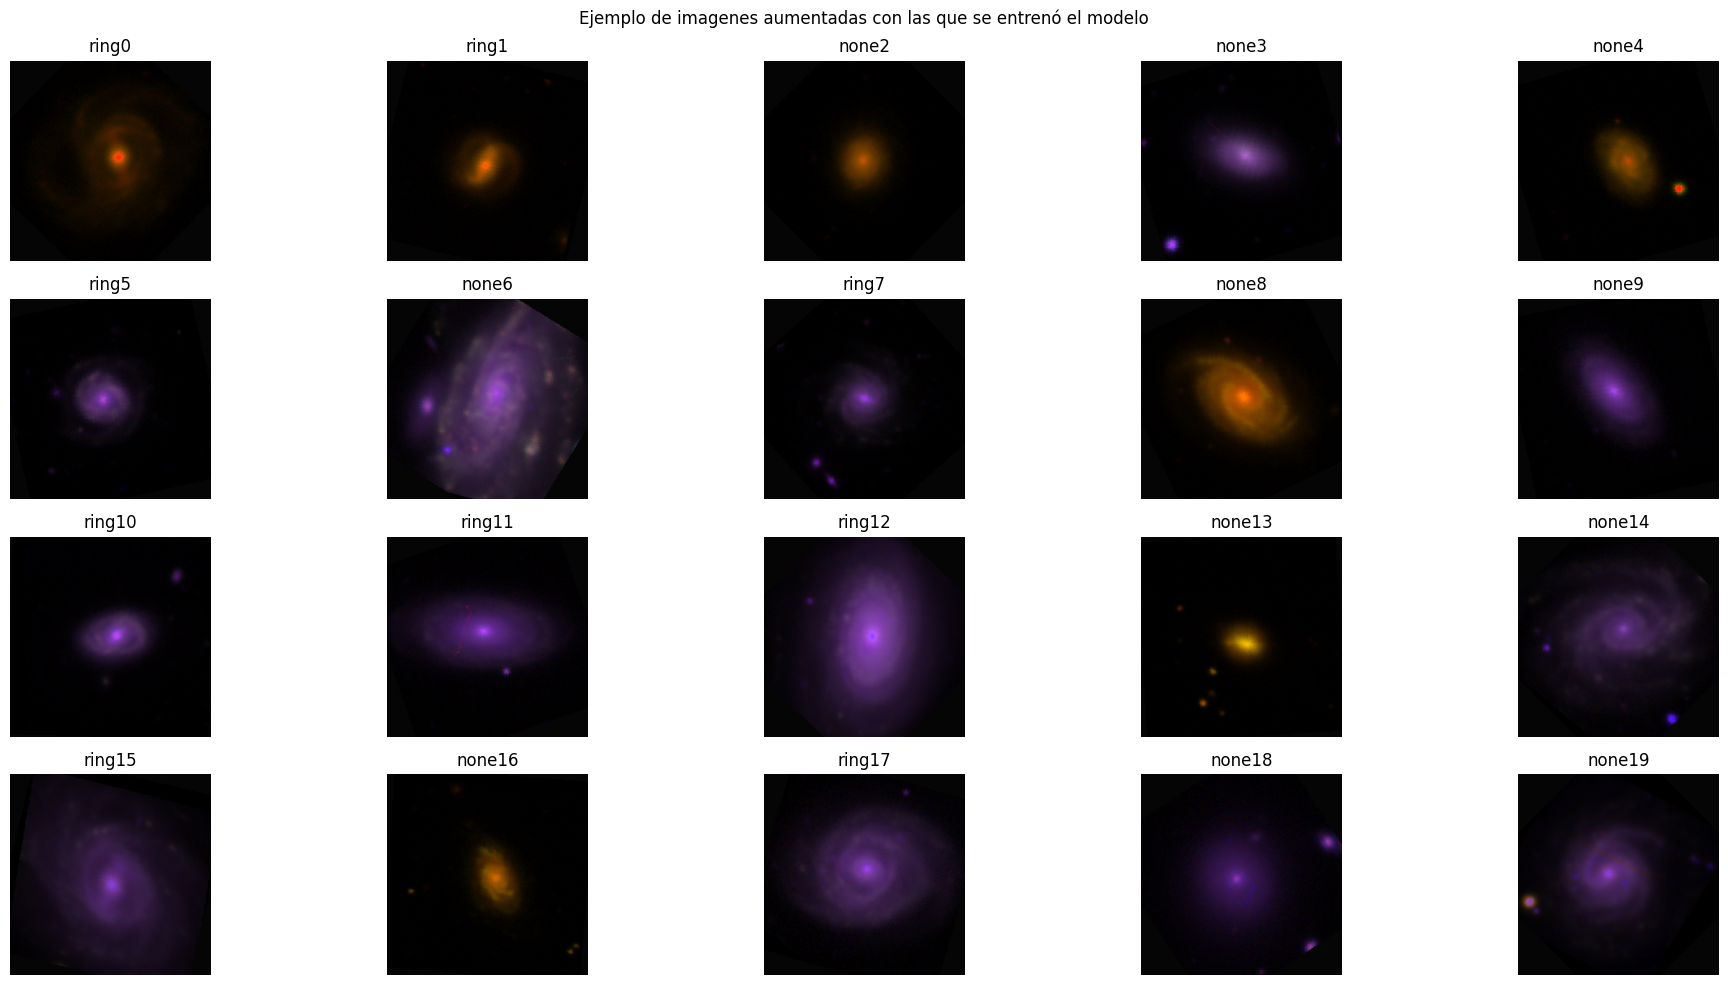

In [ ]:
"""
Configura el dataset a utilizar, define las transformaciones de entrenamiento y validación,
crea los objetos Dataset y DataLoader, y finalmente visualiza ejemplos de imágenes aumentadas.
"""

#Selección del dataset y de las clases a usar (binario o multiclase) según lo creado anteriormente
dataset_to_use = Path("/content/dataset_rgi_stack")

print("Dataset:", dataset_to_use)
print("Classes:", RING_TYPE)

#Definición de transformaciones,  incluye augmentations (flips, affine, blur, rotación) + conversión a tensor + normalización
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=20, translate=(0.05,0.05), scale=(0.9,1.1), shear=5, fill=0),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5)], p=0.3),
    transforms.RandomRotation(180, fill=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#No realizamos estos pasos para no tener una fuga de datos
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Creación de los DataLoaders, en donde - train_dataloader con shuffle=True para mezclar datos en cada época | - val_dataloader con shuffle=False para evaluación estable.
train_dataset = AugmentedDataset(f"{str(dataset_to_use)}/train", RING_TYPE, transform=train_transform, target_count=None, balance=True)
val_dataset = AugmentedDataset(f"{str(dataset_to_use)}/val", RING_TYPE, transform=val_transform, target_count=None)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(train_dataset)
print(val_dataset)

visualize_augmented_images(train_dataloader, RING_TYPE)

### Construcción de modelos y sus funciones

Se procedió a la creación de **clases específicas** para cada modelo empleado en este proyecto, incorporando en su diseño todas las funcionalidades esenciales requeridas para su entrenamiento, evaluación, inferencia y visualización.

El **proceso gradual** de entrenamiento consta de 3 fases progresivas:

**Fase 1: Ajuste del _Head_**

El head es la última parte de la red, la capa de clasificación que convierte las features en predicciones de clases.
En esta fase se entrena exclusivamente este bloque para adaptar la salida del modelo sin comprometer los pesos adquiridos en el preentrenamiento.

**Fase 2: Ajuste del _Head_ + Bloque anterior**

Se “descongela” el bloque inmediatamente anterior al head, que generalmente corresponde al bloque de atención o capas de convolución de alto nivel. Ahora el modelo ajusta no solo la capa final, sino también las representaciones más cercanas a la salida.

**Fase 3: Ajuste del _Head_ + Bloque anterior + _Backbone_**

Finalmente se descongela un siguiente bloque del _backbone_ (capas intermedias). El modelo ahora puede reajustar desde las características básicas hasta las representaciones más abstractas logrando una optimización más profunda.

#### YOLO11 cls Small
El modelo YOLO11-cls small es un modelo de capas convolucionales **compacto, rápido y optimizado**. Se distingue por ser eficiente y veloz en entrenamiento e inferencia.

El objetivo de este modelo es obtener una clasificación robusta, ya que esta versión incorpora **capas de atención**, y con un consumo computacional bajo.

Se utilizó una versión preentrenada con **ImageNet1k (1.2 millones de imágenes).**

Referencia: Khanam, R., & Hussain, M. (octubre de 2024). YOLOv11: An Overview of the Key Architectural Enhancements. https://arxiv.org/abs/2410.17725

In [ ]:
class YOLO_2CLS(nn.Module):
  """
  Clase YOLO_2CLS: Adaptación de un modelo YOLO preentrenado para clasificación binaria
  ('none' vs 'ring') con un head personalizado.

  Características principales:
      - Carga un modelo YOLO de clasificación preentrenado.
      - Modifica la última capa (head) para salida binaria con Dropout y Linear(…, 1).
      - Usa BCEWithLogitsLoss para entrenamiento estable en binario.
      - Entrenamiento progresivo por fases:
          Fase 1: solo head.
          Fase 2: head + bloque anterior (attention).
          Fase 3: head + attention + backbone completo.
      - Optimización con Adam + weight decay.
      - Scheduler ReduceLROnPlateau monitorizando f1-score de la clase 'ring'.
      - Guarda el mejor modelo según f1-score de 'ring'.
      - Evaluación con búsqueda de umbral óptimo para maximizar f1-score.

  Métodos:
      __init__(): Inicializa modelo, head, hiperparámetros y scheduler.
      load_model(path): Carga un modelo previamente guardado.
      __str__(): Imprime información del modelo y del dispositivo.
      train_model(train_loader, val_loader, ...): Entrena el modelo por fases,
          calcula métricas y guarda el mejor checkpoint.
      evaluation(val_loader, ...): Evalúa el modelo, busca el mejor umbral,
          imprime classification_report y genera matriz de confusión.
  """
  def __init__(self, model=YOLO('yolo11s-cls.pt').model):
    super().__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = model.to(self.device)
    self.model.to(self.device)
    self.ring_type = ["none", "ring"]
    # Model configuration
    self.model.model[-1].drop = nn.Dropout(p=0.4)
    self.model.model[-1].linear = nn.Linear(model.model[-1].linear.in_features, 1)
    # Training hyperparameters
    self.num_epochs = 15
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.0001, weight_decay=1e-4)
    self.criterion = torch.nn.BCEWithLogitsLoss()
    self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=5)

  def forward(self, x):
    return self.model(x)

  def load_model(self, path):
    self.model = torch.load(str(path), weights_only=False, map_location=self.device)

  def __str__(self):
    print("Modelo YOLO11-cls small de 2 clases: ['none', 'ring']")
    print("Usando el device:", self.device)
    print("Número de parámetros:", sum(p.numel() for p in self.model.parameters()))
    print("Head:\n", self.model.model[-1])
    return ""

  def train_model(self, train_loader, val_loader, epochs=None, fase=1, return_history=False):
    """
    Entrena el modelo YOLO adaptado para clasificación binaria ('none' vs 'ring')
    siguiendo un esquema de fases de fine-tuning.

    Args:
        train_loader (DataLoader): Cargador de datos de entrenamiento.
        val_loader (DataLoader): Cargador de datos de validación.
        epochs (int, optional): Número de épocas de entrenamiento
        fase (int, optional): fase de entrenamiento (1, 2, 3).
        return_history (bool, optional): si True, devuelve también el historial de métricas.
    """

    self.model.to(self.device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    num_epochs = epochs if epochs is not None else self.num_epochs
    for param in self.model.parameters():
      param.requires_grad = False
    if fase == 1:
      print("Entrenando Head...")
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    elif fase == 2:
      print("Entrenando Head | Attention...")
      for param in self.model.model[-2].parameters():
        param.requires_grad = True
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    elif fase == 3:
      print("Entrenando Head | Attention | Backbone...")
      for param in self.model.model[-3].parameters():
        param.requires_grad = True
      for param in self.model.model[-2].parameters():
        param.requires_grad = True
      for param in self.model.model[-1].parameters():
        param.requires_grad = True
    else:
      print("Entrenando Head...")
      for param in self.model.model[-1].parameters():
        param.requires_grad = True

    #Loop de entrenamiento
    for epoch in range(num_epochs):
      self.model.train()
      running_loss = 0.0
      correct = 0
      total = 0
      for param_group in self.optimizer.param_groups:
          print("LR:", param_group['lr'])
      for i, (images, labels) in enumerate(train_dataloader):
          print(f"{i+1}/{len(train_dataloader)}", end='\r')
          images, labels = images.to(self.device), labels.to(self.device)

          self.optimizer.zero_grad()

          outputs = self.model(images)
          # print("train", outputs.shape, labels.shape)
          outputs = outputs.squeeze(1)
          labels = labels.float()
          loss = self.criterion(outputs, labels)
          loss.backward()
          self.optimizer.step()

          running_loss += loss.item() * images.size(0)
          preds = (torch.sigmoid(outputs) > 0.5).long()
          correct += (preds == labels).sum().item()
          total += labels.size(0)

      epoch_loss = running_loss / total
      epoch_acc = correct / total
      history["train_loss"].append(epoch_loss)
      history["train_acc"].append(epoch_acc)
      print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

      # Validación, calcula loss y accuracy. Guarda all_labels y all_preds para métricas.
      self.model.eval()
      running_loss = 0.0
      correct = 0
      total = 0
      all_labels = []
      all_preds = []
      with torch.no_grad():
          for images, labels in val_dataloader:
              images, labels = images.to(self.device), labels.to(self.device)
              outputs = self.model(images)
              if isinstance(outputs, tuple):
                  outputs = outputs[1]
              outputs = outputs.squeeze(1)
              labels = labels.float()
              loss = self.criterion(outputs, labels)
              running_loss += loss.item() * images.size(0)
              preds = (torch.sigmoid(outputs) > 0.5).long()
              all_labels.extend(labels.cpu().numpy())
              all_preds.extend(preds.cpu().numpy())

              correct += (preds == labels).sum().item()
              total += labels.size(0)
      #Calcula loss y accuracy promedio por época.
      #Guarda en historial para utilizar luego.
      epoch_loss = running_loss / total
      val_accuracy = correct / total
      history["val_loss"].append(epoch_loss)
      history["val_acc"].append(val_accuracy)

      print(f"Validation Loss: {epoch_loss:.4f}, Accuracy: {val_accuracy:.4f}")
      cm = classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
      print("ring class metrics:", cm['ring'])

      self.scheduler.step(cm['ring']['f1-score'])

      if epoch == 0:
          best_ring_f1 = cm['ring']['f1-score']
          torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')

      else:
          if cm['ring']['f1-score'] > best_ring_f1:
              best_ring_f1 = cm['ring']['f1-score']
              torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')
              print("Model saved with ring f1-score: ", best_ring_f1)

    if return_history:
      return self.model, history
    else:
      return self.model

  def predict_supervised(self, val_dataloader):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
      for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            preds = (torch.sigmoid(outputs) > 0.5).long()
            probs_out = torch.sigmoid(outputs)
            all_probs.extend(probs_out.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)
    return probs_all, labels_all

  def evaluation(self, val_dataloader, use_best_th=True, threshold=None, ax=None):#return_fig=False):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            preds = (torch.sigmoid(outputs) > 0.5).long()
            all_probs.extend(outputs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)

    ths = np.linspace(0.01, 0.99, 99)
    best_f1 = 0
    best_th = 0.9
    for th in ths:
        preds = (probs_all >= th).astype(int)
        f1 = f1_score(labels_all, preds, pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    if use_best_th:
      all_preds = (probs_all >= best_th).astype(int)
      print("Using best threshold:", best_th)
    elif threshold is not None:
      all_preds = (probs_all >= threshold).astype(int)
      print("Using threshold:", threshold)
    print("Classification Report:")
    # Generar la matriz de confusión
    if ax:
      conf_matrix = confusion_matrix(all_labels, all_preds, normalize='true')
      sns.heatmap(conf_matrix, annot=True, fmt='.2%', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', ax=ax, cbar=False)
      return classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
    else:
      conf_matrix = confusion_matrix(all_labels, all_preds)
      print(classification_report(all_labels, all_preds, target_names=self.ring_type))
      fig, ax = plt.subplots(figsize=(10, 8))
      sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', cbar=False)
      ax.set_xlabel('Predicted')
      ax.set_ylabel('True')
      ax.set_title('Confusion Matrix')
      print("Confusion Matrix:")
      plt.show()
      return None

  def get_activation(self, name):
    self.activation = {}
    def hook(model, input, output):
        self.activation[name] = output.detach()
    return hook

  def get_attention(self):
    return self.model.model[-2].register_forward_hook(self.get_activation('att_layer')) # pull attention

  def return_attention_map(self, image, best_th=0.5):
    layer_name = "att_layer"
    get_attention = self.get_attention()
    self.model.eval()
    with torch.no_grad():
      outputs = self.model(image)

    feature_map = self.activation[layer_name][0].cpu()

    attention_map = feature_map.mean(dim=0, keepdim=True)
    attention_map = F.interpolate(attention_map.unsqueeze(0), size=image.shape[2:], mode='bilinear', align_corners=False)
    attention_map = attention_map.squeeze().numpy()

    return attention_map, torch.sigmoid(outputs[1]).item() > best_th


#Iniciarlizar una instancia para nuestro objeto - modelo.
model = YOLO_2CLS()

#Imprimimos las configuraciones personalizada
print(model)

Modelo YOLO11-cls small de 2 clases: ['none', 'ring']
Usando el device: cuda
Número de parámetros: 5444289
Head:
 Classify(
  (conv): Conv(
    (conv): Conv2d(512, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.4, inplace=False)
  (linear): Linear(in_features=1280, out_features=1, bias=True)
)



#### EfficientNet B6
EfficientNet es una familia de **redes neuronales convolucionales (CNNs)** desarrollada por Google que busca lograr un **alto rendimiento** utilizando menos recursos computacionales en comparación con arquitecturas anteriores. El modelo B6 es una de las variantes más grandes, ofreciendo alta precisión pero puede requerir más recursos computacionales.

EfficientNet introduce un **método de escalado compuesto** que ajusta de forma uniforme la profundidad, el ancho y la resolución utilizando un conjunto fijo de coeficientes. Este enfoque equilibra todas las dimensiones, evitando los rendimientos decrecientes que se observan al escalar solo una dimensión.

Se utilizó una versión preentrenada en **ImageNet1k (1.2 millones de imágenes)**.

Referencia: Tan, M., & Le, Q. (mayo de 2019). EfficientNet: Rethinking model scaling for convolutional neural networks. https://arxiv.org/abs/1905.11946

In [ ]:
class EfficientNet_2CLS(nn.Module):
  """
  Clase
  """
  def __init__(self, model=efficientnet_b6(weights='IMAGENET1K_V1')):
    super().__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = model.to(self.device)
    self.model.to(self.device)
    self.ring_type = ["none", "ring"]
    # Model configuration
    self.model.classifier[-1] = nn.Linear(self.model.classifier[-1].in_features, 1)
    # Training hyperparameters
    self.num_epochs = 15
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.0001, weight_decay=1e-4)
    self.criterion = torch.nn.BCEWithLogitsLoss()
    self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=5)

  def forward(self, x):
    return self.model(x)

  def load_model(self, path):
    self.model = torch.load(str(path), weights_only=False, map_location=self.device)

  def __str__(self):
    print("Modelo EfficientNet B6 de 2 clases: ['none', 'ring']")
    print("Usando el device:", self.device)
    print("Número de parámetros:", sum(p.numel() for p in self.model.parameters()))
    print("Head:\n", self.model.classifier)
    return ""

  def train_model(self, train_loader, val_loader, epochs=None, fase=1, return_history=False):
    """
    Entrena el modelo YOLO adaptado para clasificación binaria ('none' vs 'ring')
    siguiendo un esquema de fases de fine-tuning.

    Args:
        train_loader (DataLoader): Cargador de datos de entrenamiento.
        val_loader (DataLoader): Cargador de datos de validación.
        epochs (int, optional): Número de épocas de entrenamiento
        fase (int, optional): fase de entrenamiento (1, 2, 3).
        return_history (bool, optional): si True, devuelve también el historial de métricas.
    """

    self.model.to(self.device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    num_epochs = epochs if epochs is not None else self.num_epochs
    for param in self.model.parameters():
      param.requires_grad = False
    if fase == 1:
      print("Entrenando Head...")
      for param in model.features[8].parameters():
        param.requires_grad = True
      for param in model.classifier.parameters():
        param.requires_grad = True
    elif fase == 2:
      print("Entrenando Head | Attention...")
      for param in model.features[7].parameters():
        param.requires_grad = True
      for param in model.features[8].parameters():
        param.requires_grad = True
      for param in model.classifier.parameters():
        param.requires_grad = True
    elif fase == 3:
      print("Entrenando Head | Attention | Backbone...")
      for param in model.features[6].parameters():
        param.requires_grad = True
      for param in model.features[7].parameters():
        param.requires_grad = True
      for param in model.features[8].parameters():
        param.requires_grad = True
      for param in model.classifier.parameters():
        param.requires_grad = True
    else:
      print("Entrenando Head...")
      for param in model.features[8].parameters():
        param.requires_grad = True
      for param in model.classifier.parameters():
        param.requires_grad = True

    #Loop de entrenamiento
    for epoch in range(num_epochs):
      self.model.train()
      running_loss = 0.0
      correct = 0
      total = 0
      for param_group in self.optimizer.param_groups:
          print("LR:", param_group['lr'])
      for i, (images, labels) in enumerate(train_dataloader):
          print(f"{i+1}/{len(train_dataloader)}", end='\r')
          images, labels = images.to(self.device), labels.to(self.device)

          self.optimizer.zero_grad()

          outputs = self.model(images)
          # print("train", outputs.shape, labels.shape)
          outputs = outputs.squeeze(1)
          labels = labels.float()
          loss = self.criterion(outputs, labels)
          loss.backward()
          self.optimizer.step()

          running_loss += loss.item() * images.size(0)
          preds = (torch.sigmoid(outputs) > 0.5).long()
          correct += (preds == labels).sum().item()
          total += labels.size(0)

      epoch_loss = running_loss / total
      epoch_acc = correct / total
      history["train_loss"].append(epoch_loss)
      history["train_acc"].append(epoch_acc)
      print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

      # Validación, calcula loss y accuracy. Guarda all_labels y all_preds para métricas.
      self.model.eval()
      running_loss = 0.0
      correct = 0
      total = 0
      all_labels = []
      all_preds = []
      with torch.no_grad():
          for images, labels in val_dataloader:
              images, labels = images.to(self.device), labels.to(self.device)
              outputs = self.model(images)
              if isinstance(outputs, tuple):
                  outputs = outputs[1]
              outputs = outputs.squeeze(1)
              labels = labels.float()
              loss = self.criterion(outputs, labels)
              running_loss += loss.item() * images.size(0)
              preds = (torch.sigmoid(outputs) > 0.5).long()
              all_labels.extend(labels.cpu().numpy())
              all_preds.extend(preds.cpu().numpy())

              correct += (preds == labels).sum().item()
              total += labels.size(0)
      #Calcula loss y accuracy promedio por época.
      #Guarda en historial para utilizar luego.
      epoch_loss = running_loss / total
      val_accuracy = correct / total
      history["val_loss"].append(epoch_loss)
      history["val_acc"].append(val_accuracy)

      print(f"Validation Loss: {epoch_loss:.4f}, Accuracy: {val_accuracy:.4f}")
      cm = classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
      print("ring class metrics:", cm['ring'])

      self.scheduler.step(cm['ring']['f1-score'])

      if epoch == 0:
          best_ring_f1 = cm['ring']['f1-score']
          torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')

      else:
          if cm['ring']['f1-score'] > best_ring_f1:
              best_ring_f1 = cm['ring']['f1-score']
              torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')
              print("Model saved with ring f1-score: ", best_ring_f1)

    if return_history:
      return self.model, history
    else:
      return self.model

  def predict_supervised(self, val_dataloader):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
      for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            preds = (torch.sigmoid(outputs) > 0.5).long()
            probs_out = torch.sigmoid(outputs)
            all_probs.extend(probs_out.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)
    return probs_all, labels_all

  def evaluation(self, val_dataloader, use_best_th=True, threshold=None, ax=None):#return_fig=False):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            preds = (torch.sigmoid(outputs) > 0.5).long()
            all_probs.extend(outputs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)

    ths = np.linspace(0.01, 0.99, 99)
    best_f1 = 0
    best_th = 0.9
    for th in ths:
        preds = (probs_all >= th).astype(int)
        f1 = f1_score(labels_all, preds, pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    if use_best_th:
      all_preds = (probs_all >= best_th).astype(int)
      print("Using best threshold:", best_th)
    elif threshold is not None:
      all_preds = (probs_all >= threshold).astype(int)
      print("Using threshold:", threshold)
    print("Classification Report:")
    # Generar la matriz de confusión
    if ax:
      conf_matrix = confusion_matrix(all_labels, all_preds, normalize='true')
      sns.heatmap(conf_matrix, annot=True, fmt='.2%', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', ax=ax, cbar=False)
      return classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
    else:
      conf_matrix = confusion_matrix(all_labels, all_preds)
      print(classification_report(all_labels, all_preds, target_names=self.ring_type))
      fig, ax = plt.subplots(figsize=(10, 8))
      sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', cbar=False)
      ax.set_xlabel('Predicted')
      ax.set_ylabel('True')
      ax.set_title('Confusion Matrix')
      print("Confusion Matrix:")
      plt.show()
      return None

  def get_activation(self, name):
    self.activation = {}
    def hook(model, input, output):
        self.activation[name] = output.detach()
    return hook

  def get_attention(self):
    return self.model.features[8].register_forward_hook(self.get_activation('att_layer')) # pull attention

  def return_attention_map(self, image, best_th=0.5):
    layer_name = "att_layer"
    get_attention = self.get_attention()
    self.model.eval()
    with torch.no_grad():
      outputs = self.model(image)

    feature_map = self.activation[layer_name][0].cpu()

    attention_map = feature_map.mean(dim=0, keepdim=True)
    attention_map = F.interpolate(attention_map.unsqueeze(0), size=image.shape[2:], mode='bilinear', align_corners=False)
    attention_map = attention_map.squeeze().numpy()

    return attention_map, torch.sigmoid(outputs[0]).item() > best_th


#Iniciarlizar una instancia para nuestro objeto - modelo.
model = EfficientNet_2CLS()

#Imprimimos las configuraciones personalizada
print(model)

Modelo EfficientNet B6 de 2 clases: ['none', 'ring']
Usando el device: cuda
Número de parámetros: 40738009
Head:
 Sequential(
  (0): Dropout(p=0.5, inplace=True)
  (1): Linear(in_features=2304, out_features=1, bias=True)
)



#### ViT Base
ViT se refiere al **Vision Transformer**, una arquitectura de aprendizaje profundo diseñada para tareas basadas en imágenes que adapta el modelo Transformer originalmente desarrollado para procesamiento de lenguaje natural.

ViT divide una imagen en **parches de tamaño fijo**, los aplana y trata cada parche como un token —similar a las palabras en una oración. Estos tokens se procesan mediante un codificador Transformer estándar, que modela las relaciones entre parches utilizando el **mecanismo de auto-atención (_self-attention_)**.

Se utilizó una versión preentrenada en **ImageNet21k (14 millones de imágenes)**.

Reference: Dosovitskiy, A., et al. (octubre de 2020). An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale. https://arxiv.org/pdf/2106.10270

In [ ]:
class ViT_2CLS(nn.Module):
  """
  Clase
  """
  def __init__(self, model=ViTForImageClassification.from_pretrained('google/vit-base-patch16-224-in21k')):
    super().__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = model.to(self.device)
    self.model.to(self.device)
    self.ring_type = ["none", "ring"]
    # Model configuration
    self.model.classifier = nn.Linear(self.model.classifier.in_features, 1)
    # Training hyperparameters
    self.num_epochs = 15
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.0001, weight_decay=1e-4)
    self.criterion = torch.nn.BCEWithLogitsLoss()
    self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=5)

  def forward(self, x):
    return self.model(x)

  def load_model(self, path):
    self.model = torch.load(str(path), weights_only=False, map_location=self.device)

  def __str__(self):
    print("Modelo ViT Base de 2 clases: ['none', 'ring']")
    print("Usando el device:", self.device)
    print("Número de parámetros:", sum(p.numel() for p in self.model.parameters()))
    print("Head:\n", self.model.classifier)
    return ""

  def train_model(self, train_loader, val_loader, epochs=None, fase=1, return_history=False):
    """
    Entrena el modelo YOLO adaptado para clasificación binaria ('none' vs 'ring')
    siguiendo un esquema de fases de fine-tuning.

    Args:
        train_loader (DataLoader): Cargador de datos de entrenamiento.
        val_loader (DataLoader): Cargador de datos de validación.
        epochs (int, optional): Número de épocas de entrenamiento
        fase (int, optional): fase de entrenamiento (1, 2, 3).
        return_history (bool, optional): si True, devuelve también el historial de métricas.
    """

    self.model.to(self.device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    num_epochs = epochs if epochs is not None else self.num_epochs
    for param in self.model.parameters():
      param.requires_grad = False
    if fase == 1:
      print("Entrenando Head...")
      for param in self.model.classifier.parameters():
        param.requires_grad = True
      for param in self.model.vit.layernorm.parameters():
        param.requires_grad = True
    elif fase == 2:
      print("Entrenando Head | Attention...")
      for param in self.model.vit.encoder.layer[-2:].parameters():
        param.requires_grad = True
      for param in self.model.classifier.parameters():
        param.requires_grad = True
      for param in self.model.vit.layernorm.parameters():
        param.requires_grad = True
    elif fase == 3:
      print("Entrenando Head | Attention | Backbone...")
      for param in self.model.vit.encoder.layer[-4:].parameters():
        param.requires_grad = True
      for param in self.model.classifier.parameters():
        param.requires_grad = True
      for param in self.model.vit.layernorm.parameters():
        param.requires_grad = True
    else:
      print("Entrenando Head...")
      for param in self.model.classifier.parameters():
        param.requires_grad = True
      for param in self.model.vit.layernorm.parameters():
        param.requires_grad = True

    #Loop de entrenamiento
    for epoch in range(num_epochs):
      self.model.train()
      running_loss = 0.0
      correct = 0
      total = 0
      for param_group in self.optimizer.param_groups:
          print("LR:", param_group['lr'])
      for i, (images, labels) in enumerate(train_dataloader):
          print(f"{i+1}/{len(train_dataloader)}", end='\r')
          images, labels = images.to(self.device), labels.to(self.device)

          self.optimizer.zero_grad()

          outputs = self.model(images)
          # print("train", outputs.shape, labels.shape)
          outputs = outputs.logits.squeeze(1)
          labels = labels.float()
          loss = self.criterion(outputs, labels)
          loss.backward()
          self.optimizer.step()

          running_loss += loss.item() * images.size(0)
          preds = (torch.sigmoid(outputs) > 0.5).long()
          correct += (preds == labels).sum().item()
          total += labels.size(0)

      epoch_loss = running_loss / total
      epoch_acc = correct / total
      history["train_loss"].append(epoch_loss)
      history["train_acc"].append(epoch_acc)
      print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

      # Validación, calcula loss y accuracy. Guarda all_labels y all_preds para métricas.
      self.model.eval()
      running_loss = 0.0
      correct = 0
      total = 0
      all_labels = []
      all_preds = []
      with torch.no_grad():
          for images, labels in val_dataloader:
              images, labels = images.to(self.device), labels.to(self.device)
              outputs = self.model(images)
              if isinstance(outputs, tuple):
                  outputs = outputs[1]
              outputs = outputs.logits.squeeze(1)
              labels = labels.float()
              loss = self.criterion(outputs, labels)
              running_loss += loss.item() * images.size(0)
              preds = (torch.sigmoid(outputs) > 0.5).long()
              all_labels.extend(labels.cpu().numpy())
              all_preds.extend(preds.cpu().numpy())

              correct += (preds == labels).sum().item()
              total += labels.size(0)
      #Calcula loss y accuracy promedio por época.
      #Guarda en historial para utilizar luego.
      epoch_loss = running_loss / total
      val_accuracy = correct / total
      history["val_loss"].append(epoch_loss)
      history["val_acc"].append(val_accuracy)

      print(f"Validation Loss: {epoch_loss:.4f}, Accuracy: {val_accuracy:.4f}")
      cm = classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
      print("ring class metrics:", cm['ring'])

      self.scheduler.step(cm['ring']['f1-score'])

      if epoch == 0:
          best_ring_f1 = cm['ring']['f1-score']
          torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')

      else:
          if cm['ring']['f1-score'] > best_ring_f1:
              best_ring_f1 = cm['ring']['f1-score']
              torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')
              print("Model saved with ring f1-score: ", best_ring_f1)

    if return_history:
      return self.model, history
    else:
      return self.model

  def predict_supervised(self, val_dataloader):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
      for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            outputs = outputs.logits.squeeze(1)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            probs_out = torch.sigmoid(outputs)
            all_probs.extend(probs_out.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)
    return probs_all, labels_all


  def evaluation(self, val_dataloader, use_best_th=True, threshold=None, ax=None):#return_fig=False):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            outputs = outputs.logits.squeeze(1)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            all_probs.extend(outputs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)

    ths = np.linspace(0.01, 0.99, 99)
    best_f1 = 0
    best_th = 0.9
    for th in ths:
        preds = (probs_all >= th).astype(int)
        f1 = f1_score(labels_all, preds, pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    if use_best_th:
      all_preds = (probs_all >= best_th).astype(int)
      print("Using best threshold:", best_th)
    elif threshold is not None:
      all_preds = (probs_all >= threshold).astype(int)
      print("Using threshold:", threshold)
    print("Classification Report:")
    # Generar la matriz de confusión
    if ax:
      conf_matrix = confusion_matrix(all_labels, all_preds, normalize='true')
      sns.heatmap(conf_matrix, annot=True, fmt='.2%', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', ax=ax, cbar=False)
      return classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
    else:
      conf_matrix = confusion_matrix(all_labels, all_preds)
      print(classification_report(all_labels, all_preds, target_names=self.ring_type))
      fig, ax = plt.subplots(figsize=(10, 8))
      sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', cbar=False)
      ax.set_xlabel('Predicted')
      ax.set_ylabel('True')
      ax.set_title('Confusion Matrix')
      print("Confusion Matrix:")
      plt.show()
      return None

  def get_activation(self, name):
    self.activation = {}
    def hook(model, input, output):
        self.activation[name] = output.detach()
    return hook

  def get_attention(self):
    return self.model.vit.encoder.layer[-1].register_forward_hook(self.get_activation('att_layer')) # pull attention

  def return_attention_map(self, image, best_th=0.5):
    layer_name = "att_layer"
    get_attention = self.get_attention()
    self.model.eval()
    with torch.no_grad():
      outputs = self.model(image)

    feature_map = self.activation[layer_name][0].cpu()
    patch_tokens = feature_map[1:, :] # Exclude CLS token
    grid = int(np.sqrt(patch_tokens.shape[0]))

    attention_map = patch_tokens.mean(dim=1, keepdim=True)
    attention_map = attention_map.reshape(1, 1, grid, grid)
    attention_map = F.interpolate(attention_map, size=image.shape[2:], mode='bilinear', align_corners=False)
    attention_map = attention_map.squeeze().numpy()

    return attention_map, torch.sigmoid(outputs.logits.squeeze(1)).item() > best_th

model = ViT_2CLS()
print(model)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modelo ViT Base de 2 clases: ['none', 'ring']
Usando el device: cuda
Número de parámetros: 85799425
Head:
 Linear(in_features=768, out_features=1, bias=True)



#### DINOv2 ViT Base

DINOv2 (Self-Distillation with No Labels v2) es una arquitectura de **aprendizaje auto-supervisado** desarrollada por Meta AI para diversas tareas visuales. A diferencia de los modelos tradicionales que requieren etiquetas manuales, DINOv2 aprende **representaciones visuales sólidas** sin necesidad de etiquetado.

El modelo aprende relaciones espaciales entre regiones de la imagen, lo que le permite **capturar detalles finos y estructuras complejas** como los anillos galácticos. DINOv2 utiliza la arquitectura ViT Base, pero se entrena sin etiquetas.

Se usó una versión preentrenada en un conjunto de datos curado de **142 millones de imágenes** provenientes de dominios visuales diversos.

Reference: Oquab, M., et al. (abril de 2023) DINOv2: Learning Robust Visual Features without Supervision. https://arxiv.org/abs/2304.07193


In [ ]:
class DINO_2CLS(nn.Module):
  """
  Clase
  """
  def __init__(self, model=AutoModel.from_pretrained("facebook/dinov2-base")):
    super().__init__()
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    self.model = model.to(self.device)
    self.model.to(self.device)
    self.ring_type = ["none", "ring"]
    # Model configuration
    self.model.classifier = torch.nn.Linear(self.model.config.hidden_size, 1)
    # Training hyperparameters
    self.num_epochs = 15
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=0.0001, weight_decay=1e-4)
    self.criterion = torch.nn.BCEWithLogitsLoss()
    self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=5)

  def forward(self, x):
    return self.model(x)

  def load_model(self, path):
    self.model = torch.load(str(path), weights_only=False, map_location=self.device)

  def __str__(self):
    print("Modelo DINOv2 ViT Base de 2 clases: ['none', 'ring']")
    print("Usando el device:", self.device)
    print("Número de parámetros:", sum(p.numel() for p in self.model.parameters()))
    print("Head:\n", self.model.classifier)
    return ""

  def train_model(self, train_loader, val_loader, epochs=None, fase=1, return_history=False):
    """
    Entrena el modelo YOLO adaptado para clasificación binaria ('none' vs 'ring')
    siguiendo un esquema de fases de fine-tuning.

    Args:
        train_loader (DataLoader): Cargador de datos de entrenamiento.
        val_loader (DataLoader): Cargador de datos de validación.
        epochs (int, optional): Número de épocas de entrenamiento
        fase (int, optional): fase de entrenamiento (1, 2, 3).
        return_history (bool, optional): si True, devuelve también el historial de métricas.
    """

    self.model.to(self.device)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    num_epochs = epochs if epochs is not None else self.num_epochs
    for param in self.model.parameters():
      param.requires_grad = False
    if fase == 1:
      print("Entrenando Head...")
      for param in self.model.classifier.parameters():
        param.requires_grad = True
      for param in self.model.layernorm.parameters():
        param.requires_grad = True
    elif fase == 2:
      print("Entrenando Head | Attention...")
      for param in self.model.vit.encoder.layer[-2:].parameters():
        param.requires_grad = True
      for param in self.model.classifier.parameters():
        param.requires_grad = True
      for param in self.model.layernorm.parameters():
        param.requires_grad = True
    elif fase == 3:
      print("Entrenando Head | Attention | Backbone...")
      for param in self.model.vit.encoder.layer[-4:].parameters():
        param.requires_grad = True
      for param in self.model.classifier.parameters():
        param.requires_grad = True
      for param in self.model.layernorm.parameters():
        param.requires_grad = True
    else:
      print("Entrenando Head...")
      for param in self.model.classifier.parameters():
        param.requires_grad = True
      for param in self.model.layernorm.parameters():
        param.requires_grad = True

    #Loop de entrenamiento
    for epoch in range(num_epochs):
      self.model.train()
      running_loss = 0.0
      correct = 0
      total = 0
      for param_group in self.optimizer.param_groups:
          print("LR:", param_group['lr'])
      for i, (images, labels) in enumerate(train_dataloader):
          print(f"{i+1}/{len(train_dataloader)}", end='\r')
          images, labels = images.to(self.device), labels.to(self.device)

          self.optimizer.zero_grad()

          outputs = self.model(images).last_hidden_state
          # print("train", outputs.shape, labels.shape)
          outputs = self.model.classifier(outputs[:, 0, :]).squeeze(1)
          labels = labels.float()
          loss = self.criterion(outputs, labels)
          loss.backward()
          self.optimizer.step()

          running_loss += loss.item() * images.size(0)
          preds = (torch.sigmoid(outputs) > 0.5).long()
          correct += (preds == labels).sum().item()
          total += labels.size(0)

      epoch_loss = running_loss / total
      epoch_acc = correct / total
      history["train_loss"].append(epoch_loss)
      history["train_acc"].append(epoch_acc)
      print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

      # Validación, calcula loss y accuracy. Guarda all_labels y all_preds para métricas.
      self.model.eval()
      running_loss = 0.0
      correct = 0
      total = 0
      all_labels = []
      all_preds = []
      with torch.no_grad():
          for images, labels in val_dataloader:
              images, labels = images.to(self.device), labels.to(self.device)
              outputs = self.model(images).last_hidden_state
              if isinstance(outputs, tuple):
                  outputs = outputs[1]
              outputs = self.model.classifier(outputs[:, 0, :]).squeeze(1)
              labels = labels.float()
              loss = self.criterion(outputs, labels)
              running_loss += loss.item() * images.size(0)
              preds = (torch.sigmoid(outputs) > 0.5).long()
              all_labels.extend(labels.cpu().numpy())
              all_preds.extend(preds.cpu().numpy())

              correct += (preds == labels).sum().item()
              total += labels.size(0)
      #Calcula loss y accuracy promedio por época.
      #Guarda en historial para utilizar luego.
      epoch_loss = running_loss / total
      val_accuracy = correct / total
      history["val_loss"].append(epoch_loss)
      history["val_acc"].append(val_accuracy)

      print(f"Validation Loss: {epoch_loss:.4f}, Accuracy: {val_accuracy:.4f}")
      cm = classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
      print("ring class metrics:", cm['ring'])

      self.scheduler.step(cm['ring']['f1-score'])

      if epoch == 0:
          best_ring_f1 = cm['ring']['f1-score']
          torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')

      else:
          if cm['ring']['f1-score'] > best_ring_f1:
              best_ring_f1 = cm['ring']['f1-score']
              torch.save(self.model, f'best_model_e{epoch}_f1{best_ring_f1*100:.0f}.pt')
              print("Model saved with ring f1-score: ", best_ring_f1)

    if return_history:
      return self.model, history
    else:
      return self.model

  def predict_supervised(self, val_dataloader):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images).last_hidden_state
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            outputs = self.model.classifier(outputs[:, 0, :]).squeeze(1)
            probs_out = torch.sigmoid(outputs)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            all_probs.extend(probs_out.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)
    return probs_all, labels_all

  def evaluation(self, val_dataloader, use_best_th=True, threshold=None, ax=None):#return_fig=False):
    self.model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images).last_hidden_state
            if isinstance(outputs, tuple):
                outputs = outputs[1]
            outputs = self.model.classifier(outputs[:, 0, :]).squeeze(1)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            all_probs.extend(outputs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    probs_all = np.array(all_probs)
    labels_all = np.array(all_labels)

    ths = np.linspace(0.01, 0.99, 99)
    best_f1 = 0
    best_th = 0.9
    for th in ths:
        preds = (probs_all >= th).astype(int)
        f1 = f1_score(labels_all, preds, pos_label=1)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th

    if use_best_th:
      all_preds = (probs_all >= best_th).astype(int)
      print("Using best threshold:", best_th)
    elif threshold is not None:
      all_preds = (probs_all >= threshold).astype(int)
      print("Using threshold:", threshold)
    print("Classification Report:")
    # Generar la matriz de confusión
    if ax:
      conf_matrix = confusion_matrix(all_labels, all_preds, normalize='true')
      sns.heatmap(conf_matrix, annot=True, fmt='.2%', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', ax=ax, cbar=False)
      return classification_report(all_labels, all_preds, target_names=self.ring_type, output_dict=True)
    else:
      conf_matrix = confusion_matrix(all_labels, all_preds)
      print(classification_report(all_labels, all_preds, target_names=self.ring_type))
      fig, ax = plt.subplots(figsize=(10, 8))
      sns.heatmap(conf_matrix, annot=True, fmt='.0f', xticklabels=self.ring_type, yticklabels=self.ring_type, cmap='Blues', cbar=False)
      ax.set_xlabel('Predicted')
      ax.set_ylabel('True')
      ax.set_title('Confusion Matrix')
      print("Confusion Matrix:")
      plt.show()
      return None

  def get_activation(self, name):
    self.activation = {}
    def hook(model, input, output):
        self.activation[name] = output.detach()
    return hook

  def get_attention(self):
    return self.model.encoder.layer[-1].register_forward_hook(self.get_activation('att_layer')) # pull attention

  def return_attention_map(self, image, best_th=0.5):
    layer_name = "att_layer"
    get_attention = self.get_attention()
    self.model.eval()
    with torch.no_grad():
      outputs = self.model(image)
      outputs = self.model.classifier(outputs.last_hidden_state[:, 0, :]).squeeze(1)

    feature_map = self.activation[layer_name][0].cpu()
    patch_tokens = feature_map[1:, :] # Exclude CLS token
    grid = int(np.sqrt(patch_tokens.shape[0]))

    attention_map = patch_tokens.mean(dim=1, keepdim=True)
    attention_map = attention_map.reshape(1, 1, grid, grid)
    attention_map = F.interpolate(attention_map, size=image.shape[2:], mode='bilinear', align_corners=False)
    attention_map = attention_map.squeeze().numpy()

    return attention_map, torch.sigmoid(outputs[0]).item() > best_th, torch.sigmoid(outputs[0]).item()

model = DINO_2CLS()
print(model)

Modelo DINOv2 ViT Base de 2 clases: ['none', 'ring']
Usando el device: cuda
Número de parámetros: 86581249
Head:
 Linear(in_features=768, out_features=1, bias=True)



### Métricas y resultados 📈

Para evaluar el rendimiento de los modelos entrenados con nuestro conjunto de datos, nos centramos en la métrica F1, que constituye el promedio armónico entre la _precision_ y el _recall_.

En primer lugar, se generaron las **matrices de confusión** para cada modelo, destacando su desempeño óptimo en cada conjunto de datos (dataset) utilizado. Adicionalmente, se elaboró un gráfico de barras que presenta los resultados de la métrica F1 en sus variantes de **promedio ponderado** (weighted avg) y **promedio macro** (macro avg). El objetivo de esta visualización es evaluar el desempeño real del modelo y el desempeño ponderado (ajustado por el desbalance de clases), lo que facilita la **comparación de modelos y la selección** de la arquitectura final.

Posteriormente, se crearon gráficos de barras detallados para identificar la **combinación óptima de modelo y estrategia de preprocesamiento**, basándonos en las siguientes métricas

- F1 promedio ponderado (_weighted avg_)
- F1 promedio macro (_macro avg_)
- F1 para la clase 'none'
- F1 para la clase 'ring'

Finalmente, se graficó la **curva ROC** (Curva Característica Operativa del Receptor), la cual ilustra la relación entre la Tasa de Verdaderos Positivos (_True Positive Rate_) y la Tasa de Falsos Positivos (_False Positive Rate_). Esta curva brinda una visualización del desempeño del clasificador a través de diferentes umbrales de decisión y, de igual manera, nos ofrece una **métrica adicional** (AUC o área debajo de la curva) para comparar los modelos. Adicionalmente, se graficaron las **curvas Precision-Recall** que nos dan una perspectiva del intercambio (_trade-off_) entre estas dos métricas esenciales.

#### Matrices de confusión
Observando las matrices de confusión y las gráficas de barras, podemos llegar a las siguientes conclusiones:

- Al usar el dataset **_rgi_canny_stack_**, **EfficientNetB6 logra el mejor desempeño** entre todos los modelos, sin embargo, YOLO11Small tiene el mejor recall para "ring", lo que sugiere que detecta más anillos, aunque con más falsos positivos. ViTBase tiene el rendimiento más bajo en este conjunto de datos. A pesar de esto, este dataset es el que **peores resultados** da para la métrica F1.

- Al usar el dataset **_rgi_stack_**, **DINOv2 ViTBase es el más robusto** en todos los aspectos: precisión, recall, F1, y balance entre clases (comparándolo entre las métricas de Macro vs Weighted F1). En segundo lugar se encuentra ViTBase, seguido de YOLO11Small, lo cual nos indica que los modelos con capas de atención son mejores al tener un mayor contexto y detalles, mientras que los modelos CNN son mejores en características específicas.

- Al igual que con el dataset anterior, con **_rgi_unsharp_mask_**, **DINOv2 ViTBase es el que mejor resultados da en toda perspectiva**. Los modelos tienen un desempeño similar como con el conjunto de datos anterior, por lo que hay que hacer una inspección más detallada.

==================== dataset_rgi_canny_stack
Cargando modelo EfficientNetB6 con ring F1 en train: 60
Evaluando...
Using best threshold: 0.44
Classification Report:
{'none': {'precision': 0.8901209677419355, 'recall': 0.883, 'f1-score': 0.8865461847389559, 'support': 1000.0}, 'ring': {'precision': 0.596551724137931, 'recall': 0.6134751773049646, 'f1-score': 0.6048951048951049, 'support': 282.0}, 'accuracy': 0.8237129485179407, 'macro avg': {'precision': 0.7433363459399333, 'recall': 0.7482375886524824, 'f1-score': 0.7457206448170304, 'support': 1282.0}, 'weighted avg': {'precision': 0.825544893875844, 'recall': 0.8237129485179407, 'f1-score': 0.8245917350385145, 'support': 1282.0}}
Cargando modelo DINOv2ViTBase con ring F1 en train: 54
Evaluando...
Using best threshold: 0.18000000000000002
Classification Report:
{'none': {'precision': 0.8869475847893115, 'recall': 0.863, 'f1-score': 0.8748099341104917, 'support': 1000.0}, 'ring': {'precision': 0.5566343042071198, 'recall': 0.60992907801

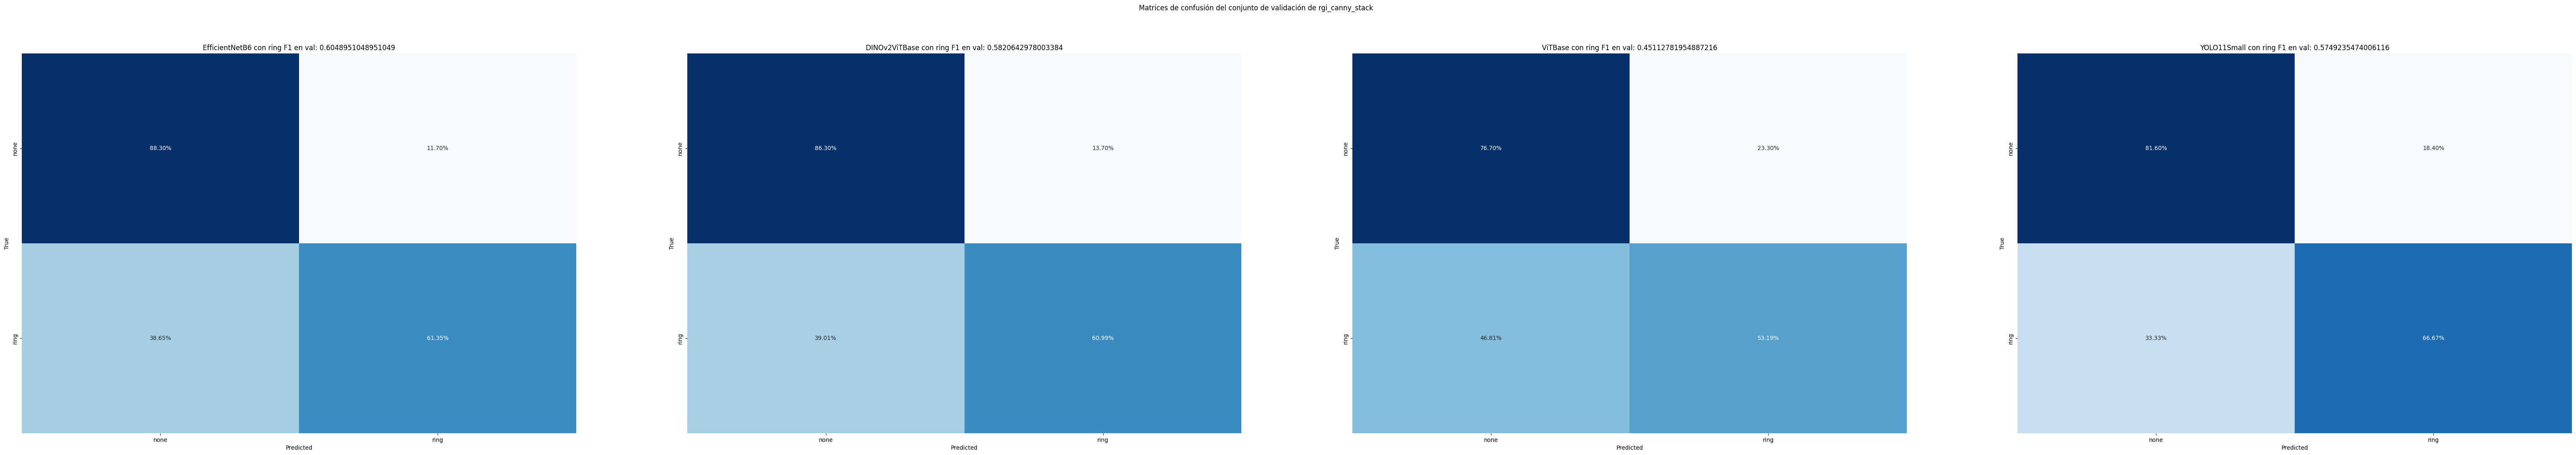

{'EfficientNetB6': 0.8245917350385145, 'DINOv2ViTBase': 0.810415028151472, 'ViTBase': 0.7293382376590245, 'YOLO11Small': 0.7929631061989681}


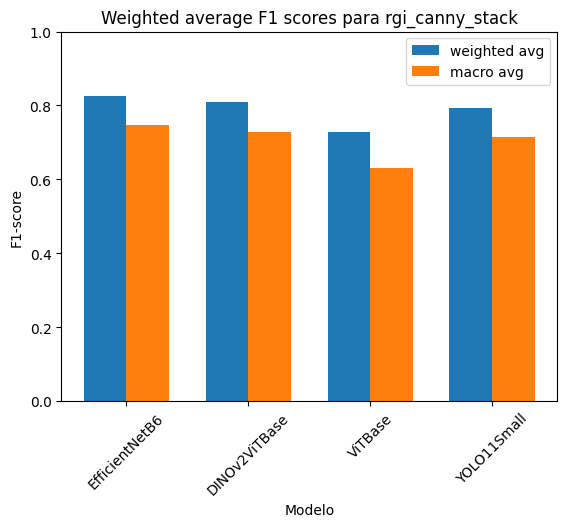

==================== dataset_rgi_stack
Cargando modelo EfficientNetB6 con ring F1 en train: 63
Evaluando...
Using best threshold: 0.37
Classification Report:
{'none': {'precision': 0.9191919191919192, 'recall': 0.819, 'f1-score': 0.8662083553675304, 'support': 1000.0}, 'ring': {'precision': 0.5370843989769821, 'recall': 0.7446808510638298, 'f1-score': 0.6240713224368499, 'support': 282.0}, 'accuracy': 0.8026521060842434, 'macro avg': {'precision': 0.7281381590844507, 'recall': 0.7818404255319149, 'f1-score': 0.7451398389021902, 'support': 1282.0}, 'weighted avg': {'precision': 0.8351401869761531, 'recall': 0.8026521060842434, 'f1-score': 0.8129457631004072, 'support': 1282.0}}
Cargando modelo DINOv2ViTBase con ring F1 en train: 75
Evaluando...
Using best threshold: 0.8400000000000001
Classification Report:
{'none': {'precision': 0.936127744510978, 'recall': 0.938, 'f1-score': 0.9370629370629371, 'support': 1000.0}, 'ring': {'precision': 0.7785714285714286, 'recall': 0.7730496453900709,

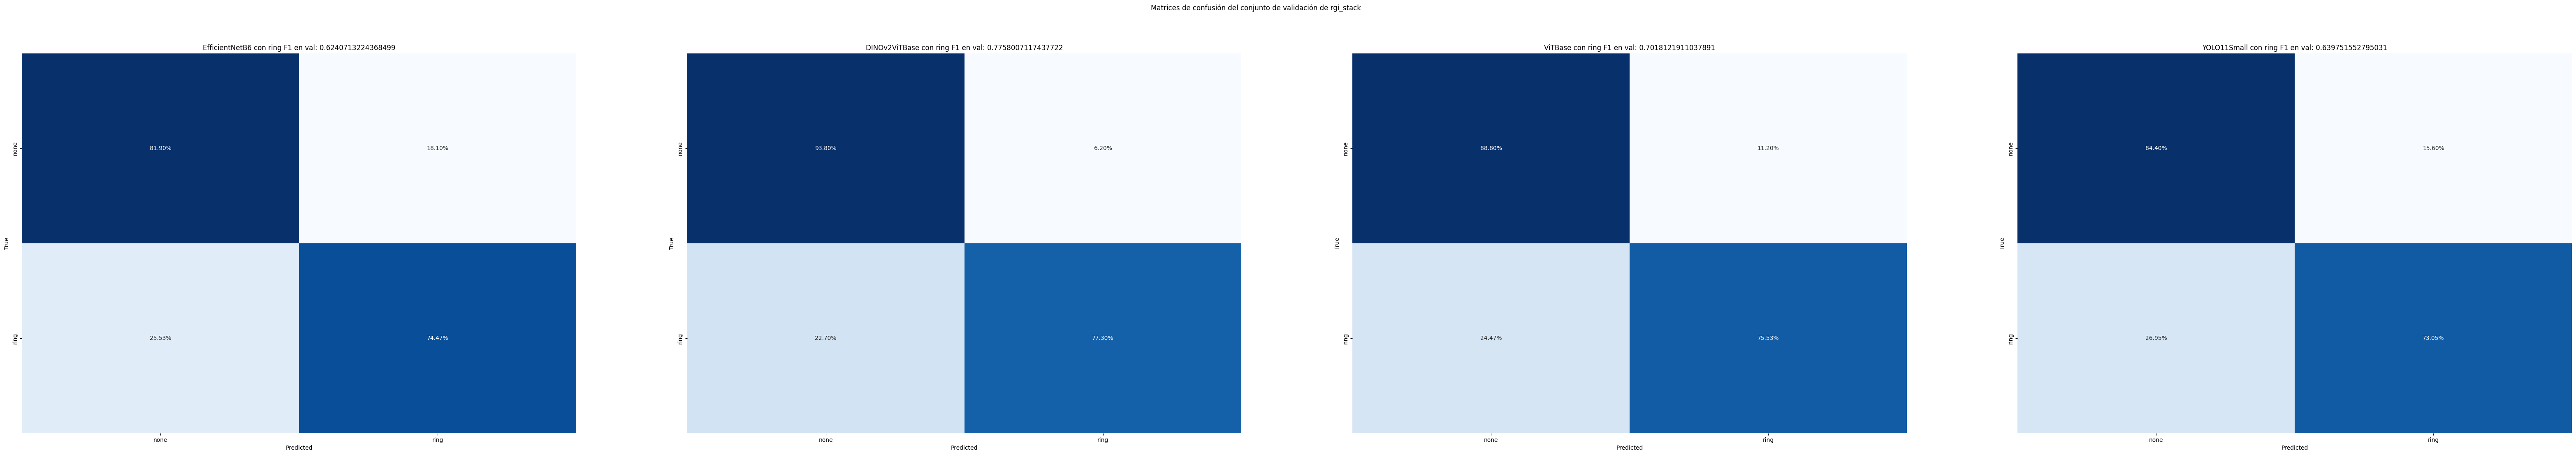

{'EfficientNetB6': 0.8129457631004072, 'DINOv2ViTBase': 0.901590279075414, 'ViTBase': 0.8622640679257757, 'YOLO11Small': 0.8265028116652615}


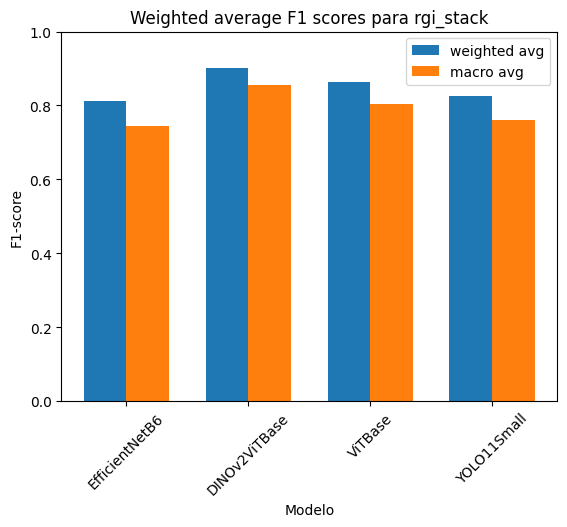

==================== dataset_rgi_unsharp_mask
Cargando modelo EfficientNetB6 con ring F1 en train: 64
Evaluando...
Using best threshold: 0.86
Classification Report:
{'none': {'precision': 0.9321663019693655, 'recall': 0.852, 'f1-score': 0.890282131661442, 'support': 1000.0}, 'ring': {'precision': 0.5978260869565217, 'recall': 0.7801418439716312, 'f1-score': 0.676923076923077, 'support': 282.0}, 'accuracy': 0.8361934477379095, 'macro avg': {'precision': 0.7649961944629435, 'recall': 0.8160709219858155, 'f1-score': 0.7836026042922595, 'support': 1282.0}, 'weighted avg': {'precision': 0.8586218864985216, 'recall': 0.8361934477379095, 'f1-score': 0.8433497966877923, 'support': 1282.0}}
Cargando modelo DINOv2ViTBase con ring F1 en train: 73
Evaluando...
Using best threshold: 0.76
Classification Report:
{'none': {'precision': 0.9448491155046826, 'recall': 0.908, 'f1-score': 0.9260581336053034, 'support': 1000.0}, 'ring': {'precision': 0.7133956386292835, 'recall': 0.8120567375886525, 'f1-sco

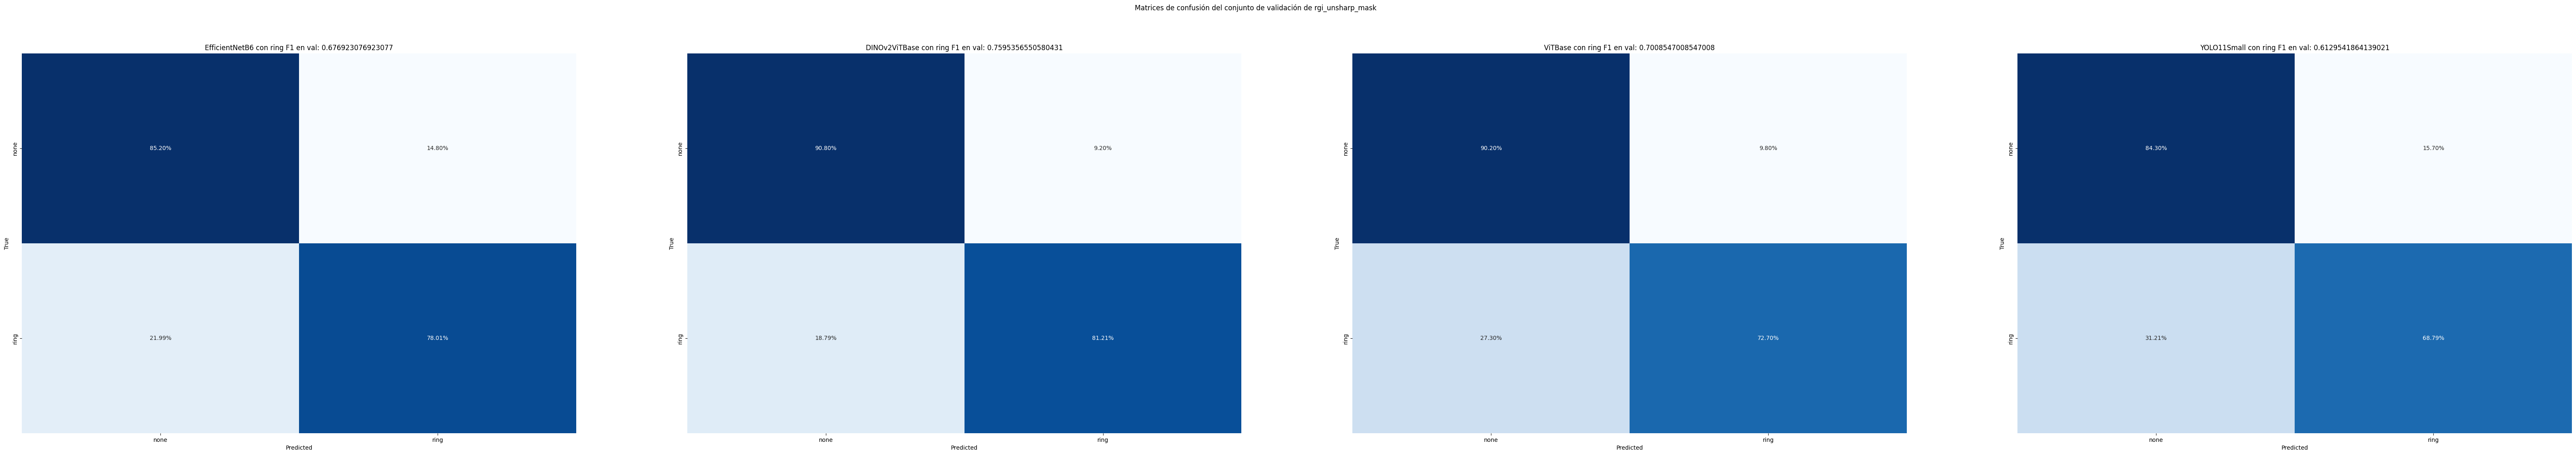

{'EfficientNetB6': 0.8433497966877923, 'DINOv2ViTBase': 0.8894283840340652, 'ViTBase': 0.865220379406384, 'YOLO11Small': 0.8158937713753994}


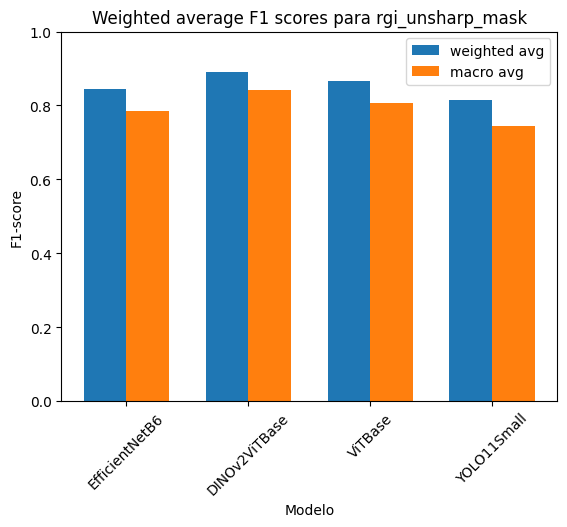

In [ ]:
model_paths = Path("/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals")
dataset_to_show = ["rgi_canny_stack", "rgi_stack", "rgi_unsharp_mask"]
f1_scores = plot_confmat(model_paths, dataset_to_show)

#### Gráficas de barras de modelos + dataset
Las gráficas de barras que nos muestran el desempeño de los modelos en cada dataset para todas las métricas de F1 nos da una perspectiva de comparación mucho más clara y nos da una guía de qué modelo podría ser el mejor. Observando las gráficas podemos concluir lo siguiente:

- El modelo **DINOv2ViTBase está en los primeros dos lugares** con el conjunto de datos **_rgi_stack_** y **_rgi_unsharp_mask_**.

- El modelo **DINOv2ViTBase** será el modelo que utilizaremos para evaluar a mayor detalle ya que nos da resultados altos en la métricas F1.

[('rgi_canny_stack_ViTBase', 0.7293382376590245), ('rgi_canny_stack_YOLO11Small', 0.7929631061989681), ('rgi_canny_stack_DINOv2ViTBase', 0.810415028151472), ('rgi_stack_EfficientNetB6', 0.8129457631004072), ('rgi_unsharp_mask_YOLO11Small', 0.8158937713753994), ('rgi_canny_stack_EfficientNetB6', 0.8245917350385145), ('rgi_stack_YOLO11Small', 0.8265028116652615), ('rgi_unsharp_mask_EfficientNetB6', 0.8433497966877923), ('rgi_stack_ViTBase', 0.8622640679257757), ('rgi_unsharp_mask_ViTBase', 0.865220379406384), ('rgi_unsharp_mask_DINOv2ViTBase', 0.8894283840340652), ('rgi_stack_DINOv2ViTBase', 0.901590279075414)]


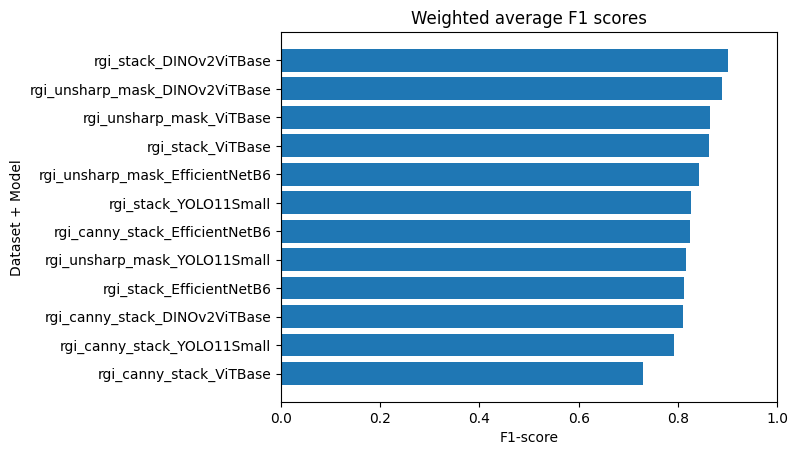

[('rgi_canny_stack_ViTBase', 0.6294606975574798), ('rgi_canny_stack_YOLO11Small', 0.7146869045903581), ('rgi_canny_stack_DINOv2ViTBase', 0.728437115955415), ('rgi_unsharp_mask_YOLO11Small', 0.7430384603742219), ('rgi_stack_EfficientNetB6', 0.7451398389021902), ('rgi_canny_stack_EfficientNetB6', 0.7457206448170304), ('rgi_stack_YOLO11Small', 0.7594591097308488), ('rgi_unsharp_mask_EfficientNetB6', 0.7836026042922595), ('rgi_stack_ViTBase', 0.8046618441466825), ('rgi_unsharp_mask_ViTBase', 0.8062131008063297), ('rgi_unsharp_mask_DINOv2ViTBase', 0.8427968943316733), ('rgi_stack_DINOv2ViTBase', 0.8564318244033546)]


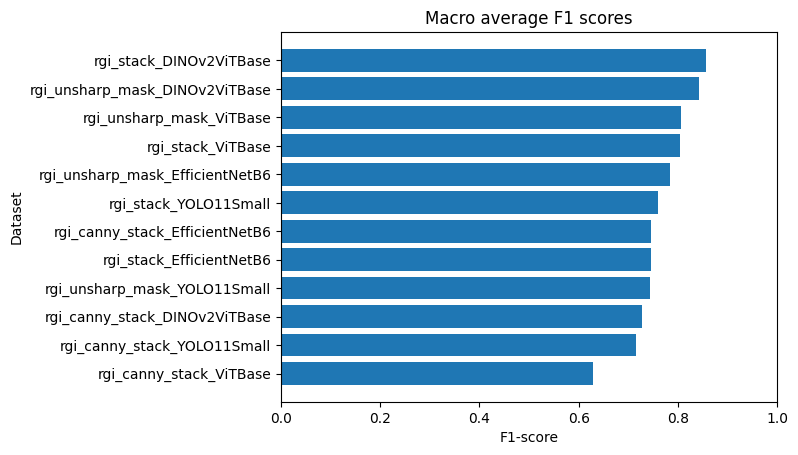

[('rgi_canny_stack_ViTBase', 0.45112781954887216), ('rgi_canny_stack_YOLO11Small', 0.5749235474006116), ('rgi_canny_stack_DINOv2ViTBase', 0.5820642978003384), ('rgi_canny_stack_EfficientNetB6', 0.6048951048951049), ('rgi_unsharp_mask_YOLO11Small', 0.6129541864139021), ('rgi_stack_EfficientNetB6', 0.6240713224368499), ('rgi_stack_YOLO11Small', 0.639751552795031), ('rgi_unsharp_mask_EfficientNetB6', 0.676923076923077), ('rgi_unsharp_mask_ViTBase', 0.7008547008547008), ('rgi_stack_ViTBase', 0.7018121911037891), ('rgi_unsharp_mask_DINOv2ViTBase', 0.7595356550580431), ('rgi_stack_DINOv2ViTBase', 0.7758007117437722)]


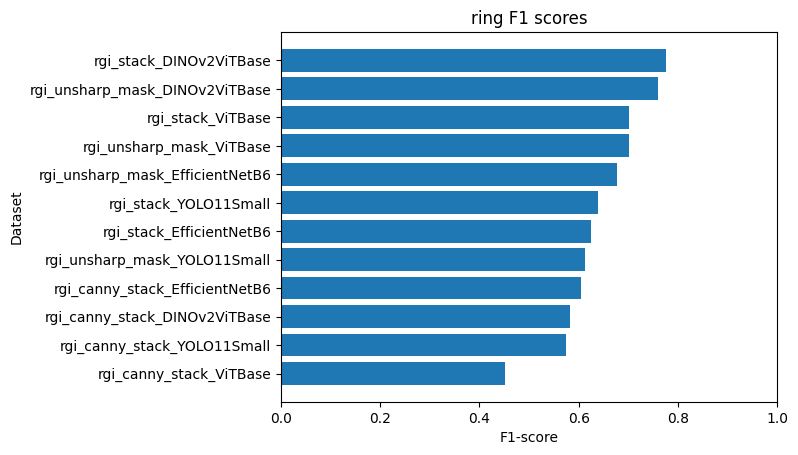

[('rgi_canny_stack_ViTBase', 0.8077935755660874), ('rgi_canny_stack_YOLO11Small', 0.8544502617801047), ('rgi_stack_EfficientNetB6', 0.8662083553675304), ('rgi_unsharp_mask_YOLO11Small', 0.8731227343345417), ('rgi_canny_stack_DINOv2ViTBase', 0.8748099341104917), ('rgi_stack_YOLO11Small', 0.8791666666666667), ('rgi_canny_stack_EfficientNetB6', 0.8865461847389559), ('rgi_unsharp_mask_EfficientNetB6', 0.890282131661442), ('rgi_stack_ViTBase', 0.9075114971895759), ('rgi_unsharp_mask_ViTBase', 0.9115715007579586), ('rgi_unsharp_mask_DINOv2ViTBase', 0.9260581336053034), ('rgi_stack_DINOv2ViTBase', 0.9370629370629371)]


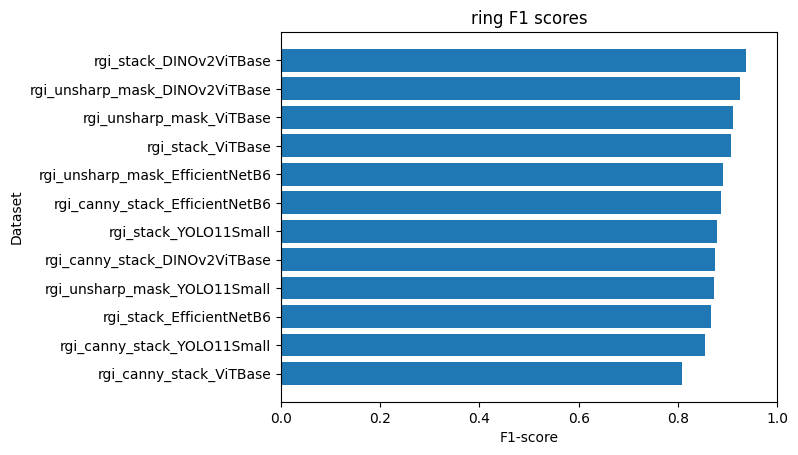

In [ ]:
# f1_scores
# order according to values
overall_f1_scores = {}
for trans, _ in f1_scores['weighted_avg'].items():
  for model, f1 in f1_scores['weighted_avg'][trans].items():
    dict_name = trans + "_" + model
    overall_f1_scores[dict_name] = f1
# sort according to value
sorted_overall = sorted(overall_f1_scores.items(), key=lambda kv: kv[1], reverse=False)
print(sorted_overall)
# plot barh of list of tuples
plt.barh(list(zip(*sorted_overall))[0], list(zip(*sorted_overall))[1])
plt.ylabel('Dataset + Model')
plt.xlabel('F1-score')
plt.title("Weighted average F1 scores")
plt.xlim(0,1)
plt.show()

overall_f1_scores = {}
for trans, _ in f1_scores['macro_avg'].items():
  for model, f1 in f1_scores['macro_avg'][trans].items():
    dict_name = trans + "_" + model
    overall_f1_scores[dict_name] = f1
# sort according to value
sorted_overall = sorted(overall_f1_scores.items(), key=lambda kv: kv[1], reverse=False)
print(sorted_overall)
plt.barh(list(zip(*sorted_overall))[0], list(zip(*sorted_overall))[1])
plt.ylabel('Dataset')
plt.xlabel('F1-score')
plt.title("Macro average F1 scores")
plt.xlim(0,1)
plt.show()

overall_f1_scores = {}
for trans, _ in f1_scores['ring'].items():
  for model, f1 in f1_scores['ring'][trans].items():
    dict_name = trans + "_" + model
    overall_f1_scores[dict_name] = f1
# sort according to value
sorted_overall = sorted(overall_f1_scores.items(), key=lambda kv: kv[1], reverse=False)
print(sorted_overall)
plt.barh(list(zip(*sorted_overall))[0], list(zip(*sorted_overall))[1])
plt.ylabel('Dataset')
plt.xlabel('F1-score')
plt.title("ring F1 scores")
plt.xlim(0,1)
plt.show()

overall_f1_scores = {}
for trans, _ in f1_scores['none'].items():
  for model, f1 in f1_scores['none'][trans].items():
    dict_name = trans + "_" + model
    overall_f1_scores[dict_name] = f1
# sort according to value
sorted_overall = sorted(overall_f1_scores.items(), key=lambda kv: kv[1], reverse=False)
print(sorted_overall)
plt.barh(list(zip(*sorted_overall))[0], list(zip(*sorted_overall))[1])
plt.ylabel('Dataset')
plt.xlabel('F1-score')
plt.title("ring F1 scores")
plt.xlim(0,1)
plt.show()

#### Curva ROC y curva Precision-Recall

La curva ROC y la curva Precision-Recall nos permite comparar el modelo DINOv2ViTBase para los dos mejores datasets. Observando los resultados, vemos que son modelos muy similares, pero la métrica AUC nos indica que el modelo en el dataset **_rgi_stack_** **es ligeramente mejor de manera balanceada**.

Analizando la gráfica Precision vs Recall, nos indica en qué umbral encontraríamos un balance para estas dos métricas. Se graficó en conjunto el umbral donde se calculó el mejor resultado de F1 para modelo; concluimo que, a pesar de que el modelo entrenado con **_rgi_stack_** es ligeramente mejor en cuanto a desempeño, el modelo **_rgi_unsharp_mask_** nos da un **recall mayor** al utilizar el umbral para un F1 óptimo, por lo que este modelo podría ser más útil si es crítico obtener la mayor cantidad de anillos posibles.

==================== dataset_rgi_stack
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_stack
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_stack/best_model_e12_f175.pt
Best threshold: 0.7044033408164978 with F1: 0.776386404293381
CM for rgi_stack
[[       0.94        0.06]
 [    0.23404     0.76596]]
==================== dataset_rgi_unsharp_mask
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_unsharp_mask
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_unsharp_mask/best_model_e3_f173.pt
Best threshold: 0.6841901540756226 with F1: 0.7595356550580431
CM for rgi_unsharp_mask
[[      0.908       0.092]
 [    0.19149     0.80851]]


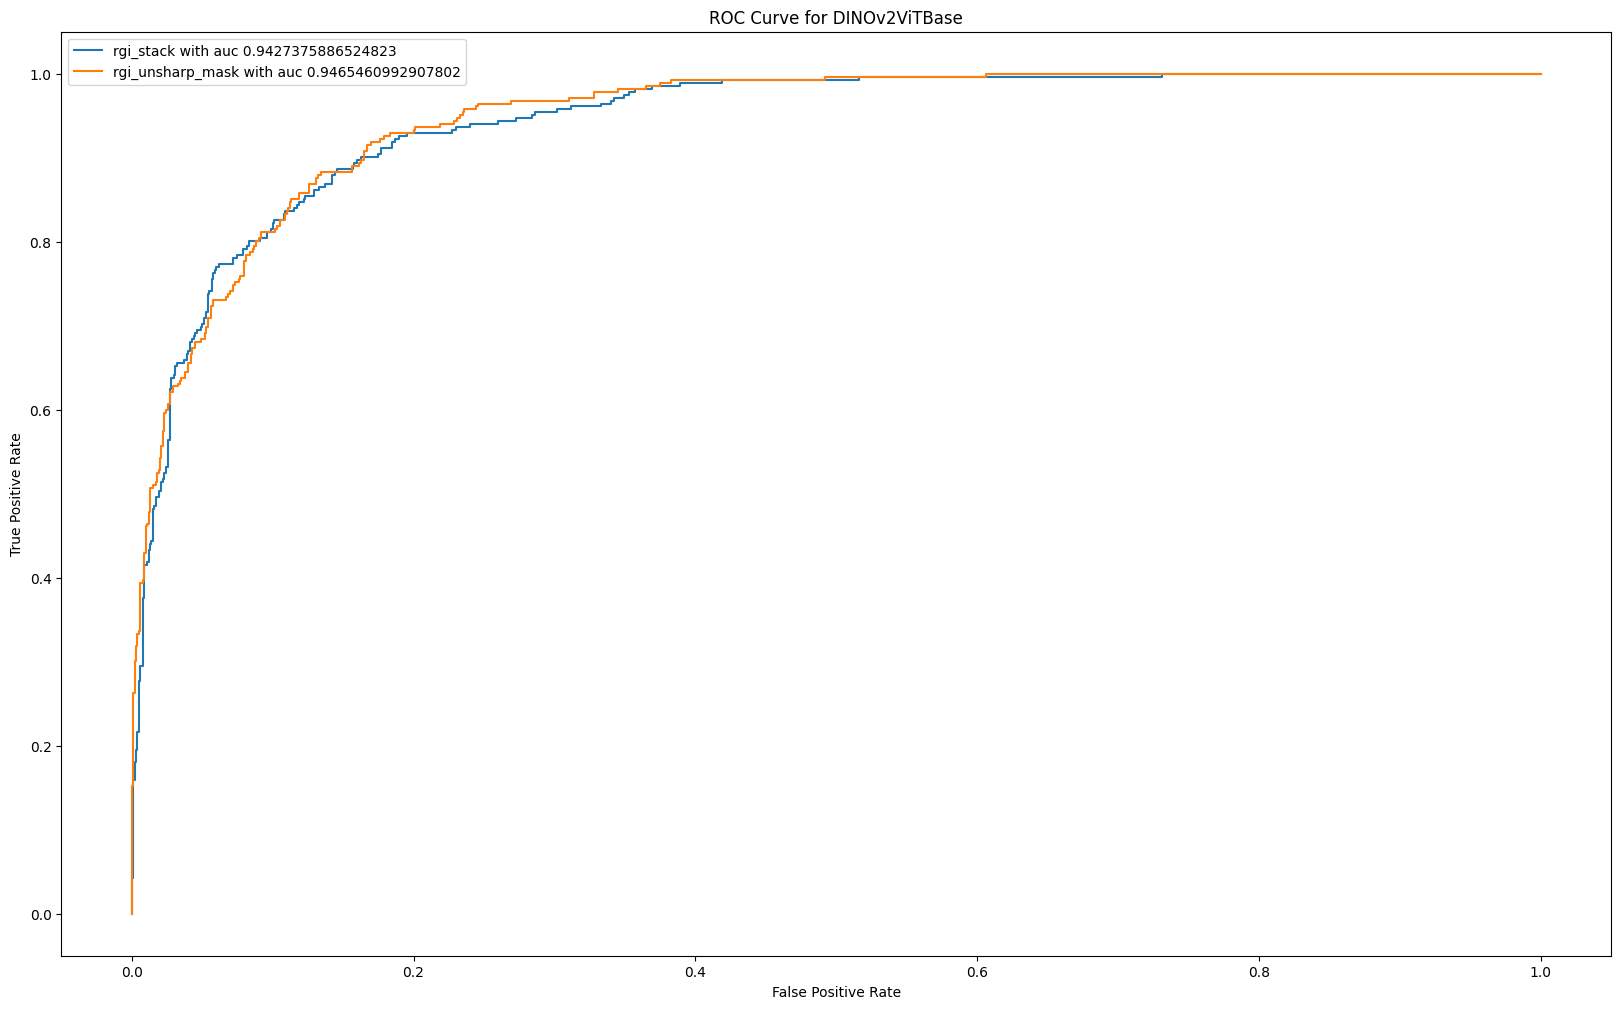

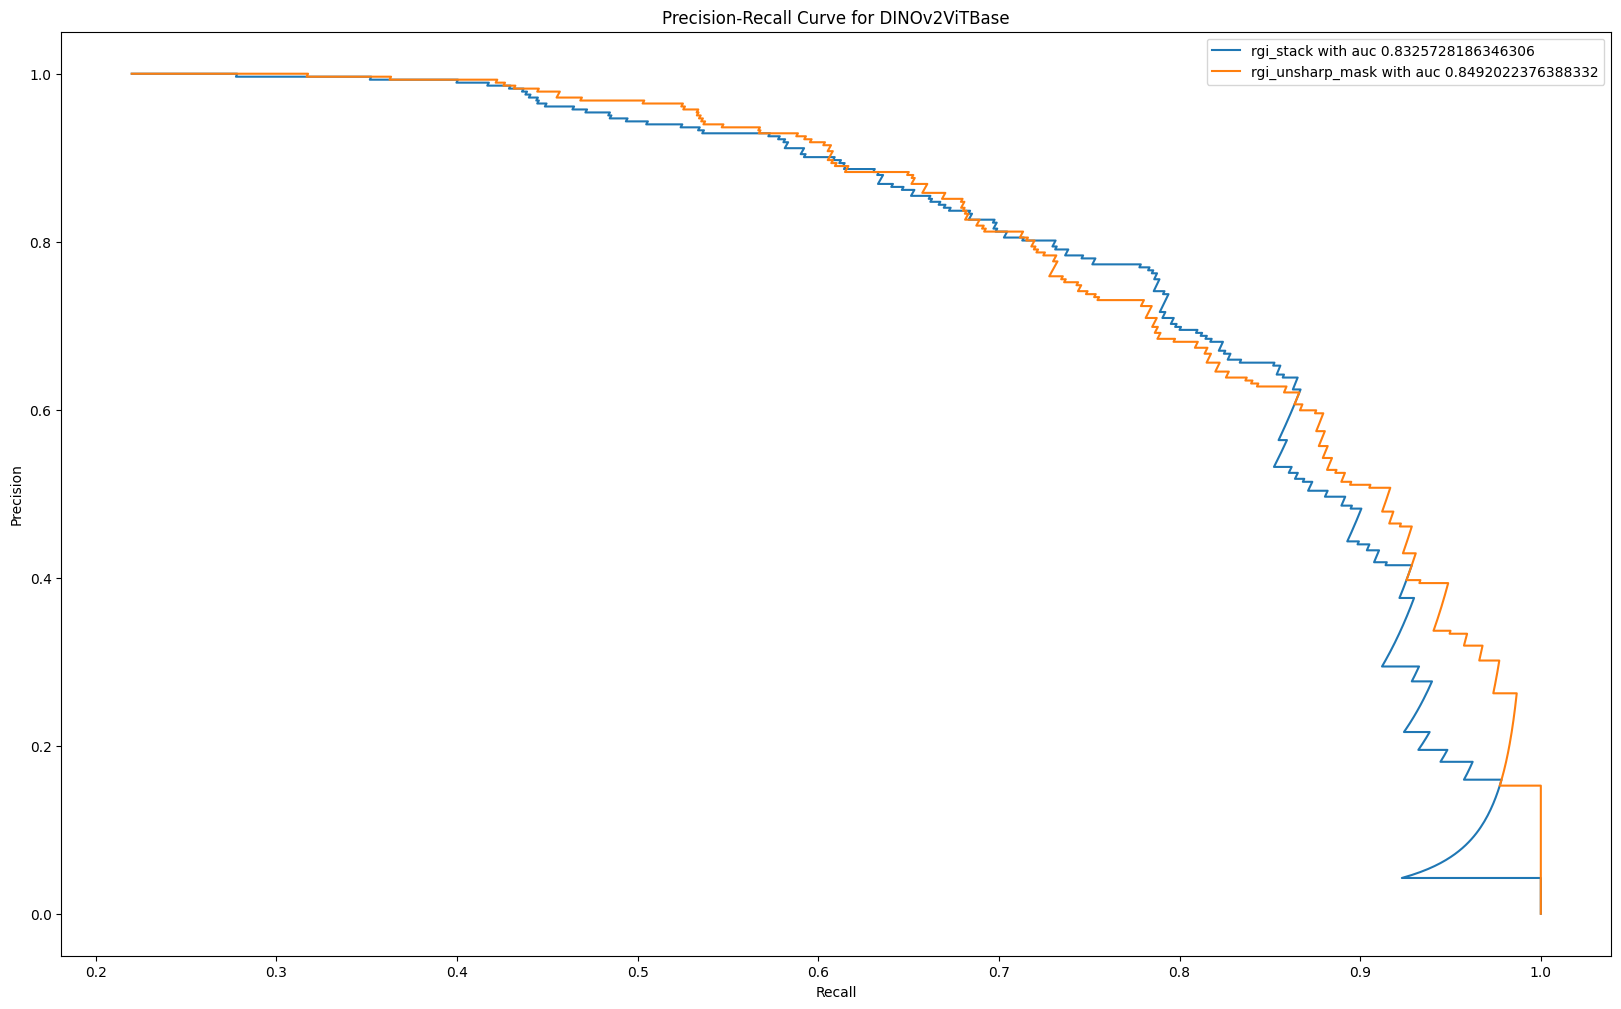

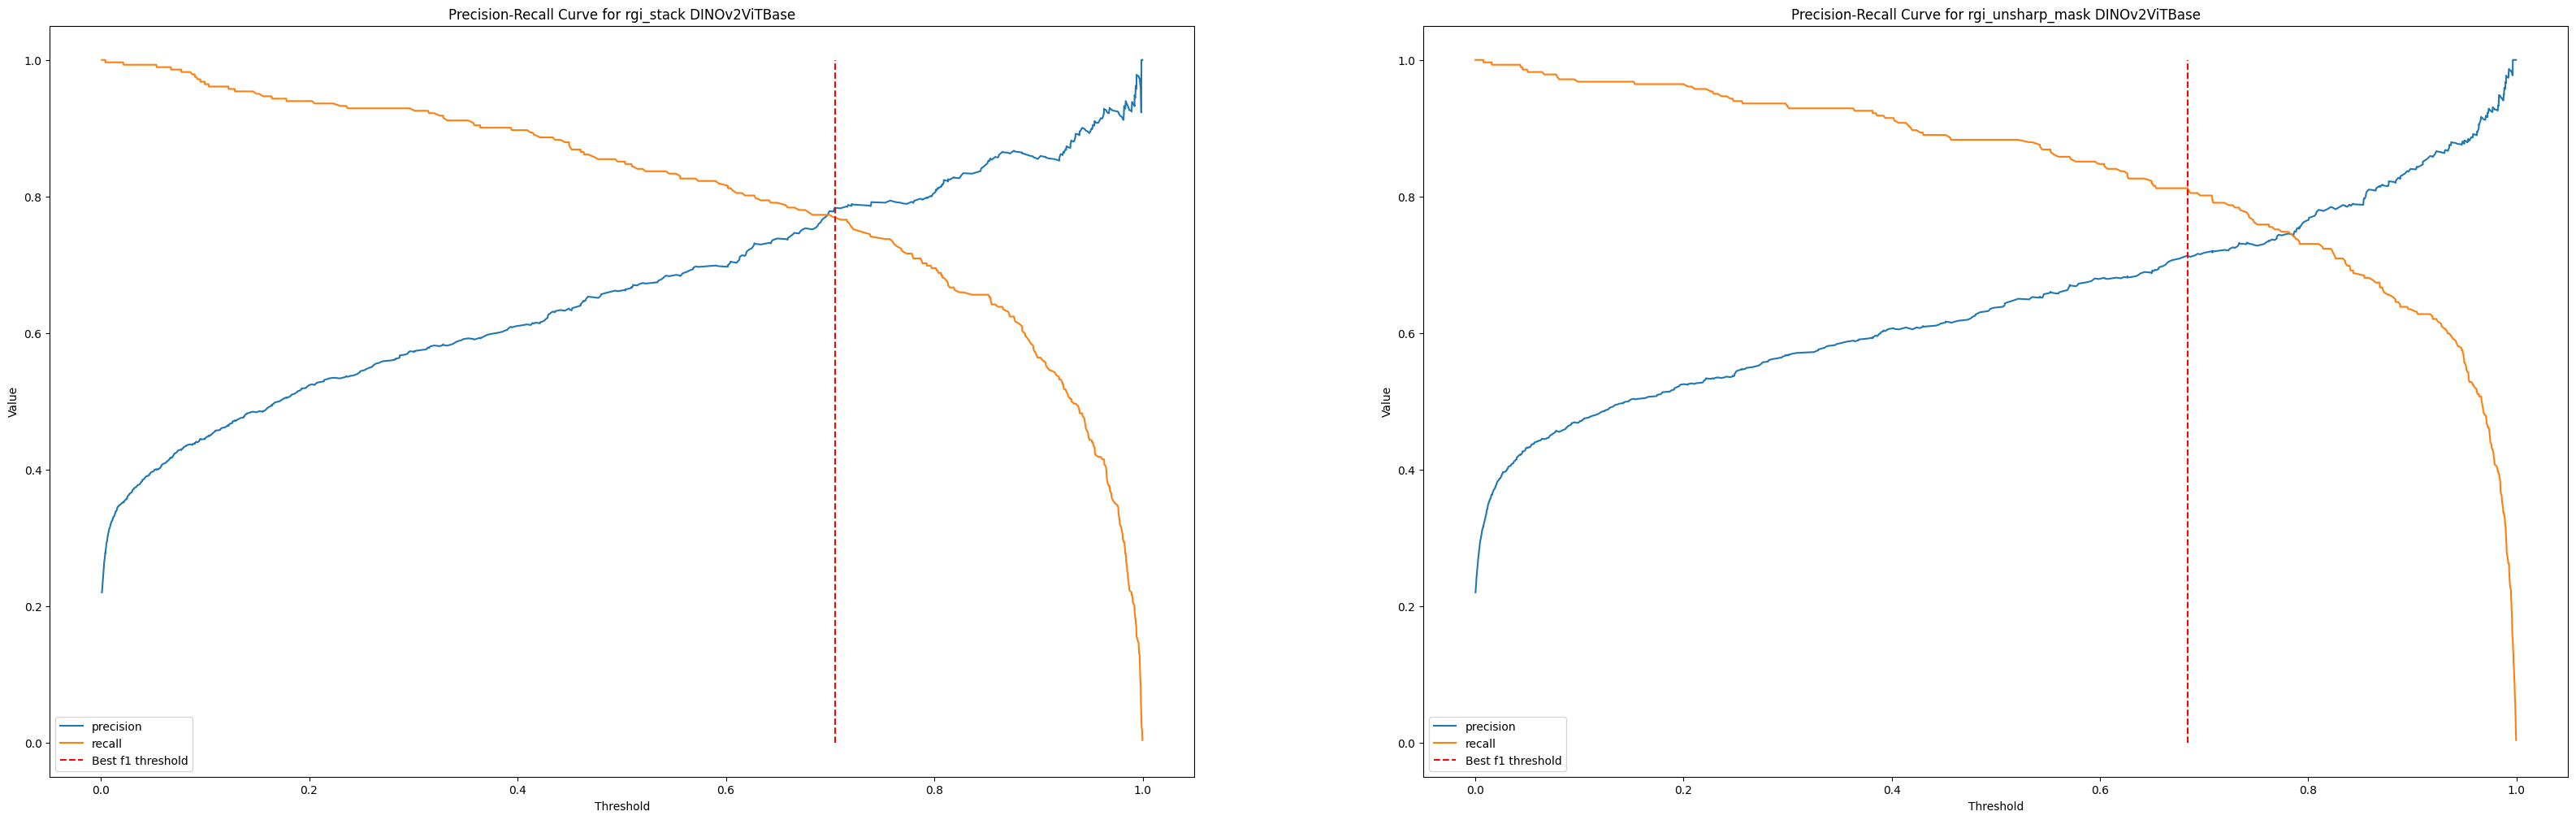

In [ ]:
# ROC curves
root = Path("/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals")
models = [root / "DINOv2ViTBase"]
datasets_to_show = ["rgi_stack", "rgi_unsharp_mask"]
plot_roc_and_pr(models, datasets_to_show)


### Visualizaciones
Haciendo uso del resultado de las últimas capas de atención, podemos obtener una visualización de las activaciones importantes para el modelo en la imagen que nos pueden indicar las características utilizadas para la toma de decisiones.

Podemos observar que, debido a que el dataset **_rgi_unsharp_mask_** nos da un mayor contraste y detalles de anillos, el modelo entrenado en este conjunto engloba la galaxia de una mejor manera.

==================== dataset_rgi_stack
desired label ring
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_stack
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_stack/best_model_e12_f175.pt
Loading trained model... 0.7
==================== dataset_rgi_unsharp_mask
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_unsharp_mask
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_unsharp_mask/best_model_e3_f173.pt
Loading trained model... 0.68


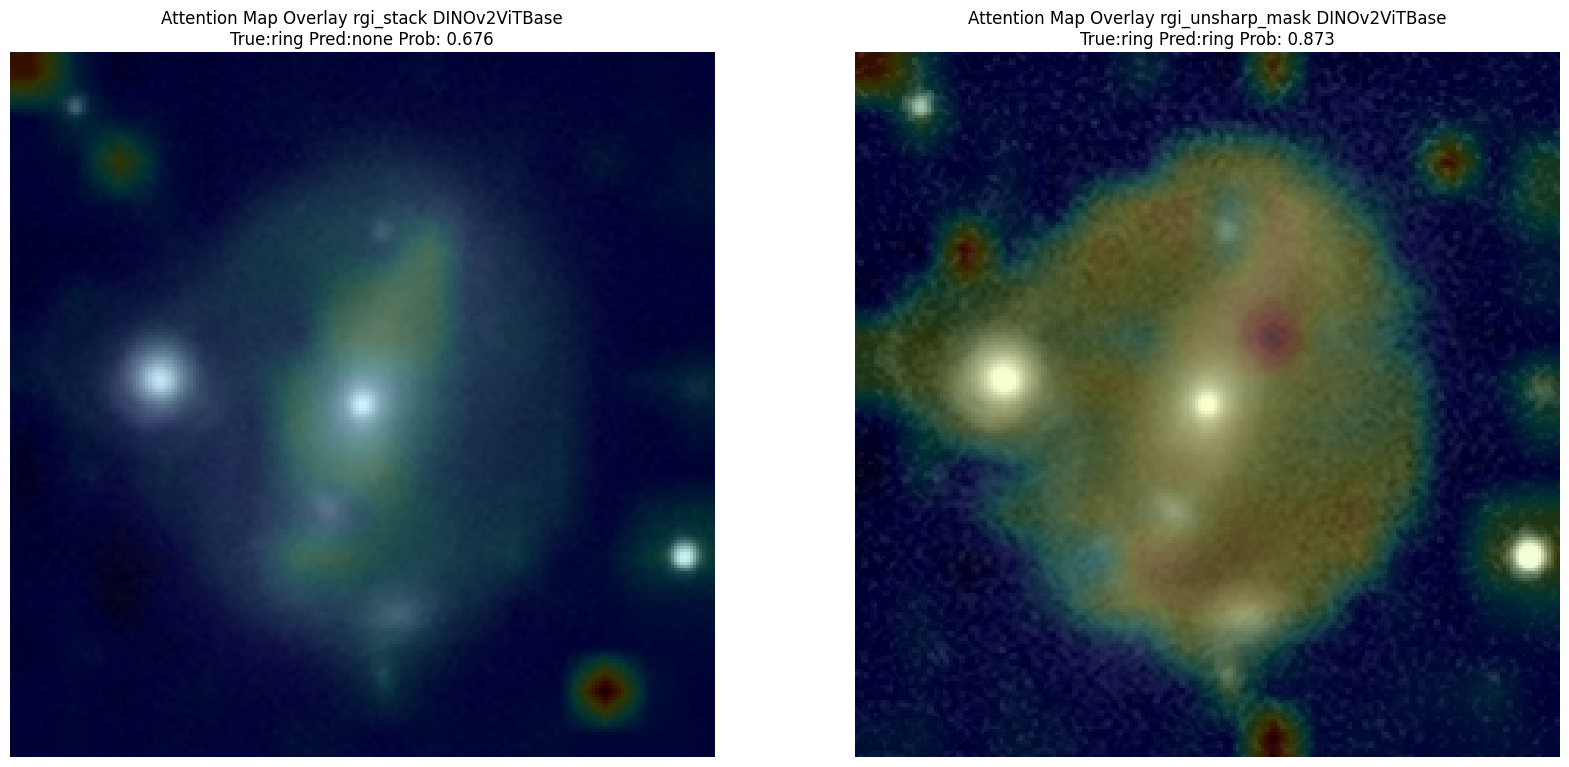

In [ ]:
root = Path("/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals")
models = [root / "DINOv2ViTBase"]
datasets_to_show = ["rgi_stack", "rgi_unsharp_mask"]
vis_att_map(models, datasets_to_show, f1_th=[0.70, 0.68])

### Tabla comparativa

Finalmente, podemos crear una tabla comparativa entre todos los modelos y así obtener una guía para el uso de cada uno. Podemos concluir lo siguiente:

- DINOv2ViTBase es el mejor modelo en cuanto a desempeño. Sin embargo, también es el más grande y el de mayor latencia por imagen.

- YOLO11-cls Small es el modelo más rápido y más pequeño, pero le que peores resultados nos brinda.

- ViT Base es el segundo lugar en cuanto a resultados, pero EfficientNetB6 es tiene la mitad de tamaño, es más rápido y poseé resultados ligeramente menores, por lo que podría ser una mejor opción si la rapidez es una necesidad crítica.

In [ ]:
model_paths = Path("/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals")
datasets_to_show = ["rgi_stack", "rgi_unsharp_mask"]
summary = models_summary(model_paths, datasets_to_show)

==================== dataset_rgi_stack
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/EfficientNetB6/rgi_stack
<class 'list'>
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_stack
<class 'list'>
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/ViTBase/rgi_stack
<class 'list'>
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/YOLO11Small/rgi_stack
<class 'list'>
==================== dataset_rgi_unsharp_mask
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/EfficientNetB6/rgi_unsharp_mask
<class 'list'>
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/DINOv2ViTBase/rgi_unsharp_mask
<class 'list'>
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/ViTBase/rgi_unsharp_mask
<class 'list'>
/content/drive/MyDrive/Proyecto Integrador/Codigo/Modelos/Finals/YOLO11Small/rgi_unsharp_mask
<class 'list'>


{'EfficientNetB6': {'datasets': {'rgi_stack': {'mAP': np.float64(0.6623601802355203),
    'F1 ring': 0.6240713224368499,
    'F1 ring@0.5': 0.6114819759679573},
   'rgi_unsharp_mask': {'mAP': np.float64(0.7264474240826558),
    'F1 ring': 0.6871961102106969,
    'F1 ring@0.5': 0.6409574468085106}},
  'params': 40738009,
  'size_MB': 155.40317153930664,
  'lat/img': '0.006586765627968703 ± 5.984774758106614e-05'},
 'DINOv2ViTBase': {'datasets': {'rgi_stack': {'mAP': np.float64(0.8330126517943767),
    'F1 ring': 0.7755834829443446,
    'F1 ring@0.5': 0.7453416149068323},
   'rgi_unsharp_mask': {'mAP': np.float64(0.849483601593575),
    'F1 ring': 0.7583892617449665,
    'F1 ring@0.5': 0.7410714285714286}},
  'params': 86581249,
  'size_MB': 330.28125381469727,
  'lat/img': '0.014168976809220907 ± 7.432519892508907e-05'},
 'ViTBase': {'datasets': {'rgi_stack': {'mAP': np.float64(0.7078466792401233),
    'F1 ring': 0.7018121911037891,
    'F1 ring@0.5': 0.6827067669172933},
   'rgi_unshar

In [ ]:
summary_df(summary, datasets_to_show)

,model,mAP_rgi_stack,mAP_rgi_unsharp_mask,F1 ring_rgi_stack,F1 ring_rgi_unsharp_mask,F1 ring@0.5_rgi_stack,F1 ring@0.5_rgi_unsharp_mask,params,size_MB,lat/img (s)
0,DINOv2ViTBase,0.833013,0.849484,0.775583,0.758389,0.745342,0.741071,86581249,330.281254,0.0142 ±7.433e-05
1,EfficientNetB6,0.662360,0.726447,0.624071,0.687196,0.611482,0.640957,40738009,155.403172,0.0066 ±5.985e-05
2,ViTBase,0.707847,0.721161,0.701812,0.706240,0.682707,0.699670,85799425,327.298832,0.0104 ±6.699e-05
3,YOLO11Small,0.619184,0.623573,0.637904,0.610015,0.628734,0.604585,5444289,20.768314,0.0009 ±2.189e-05


## Modelo de medición de anillo

Tras identificar las galaxias con anillos mediante el modelo de clasificación, el siguiente paso crítico consiste en la **extracción de características geométricas** de los anillos detectados. Este proceso permite cuantificar propiedades físicas fundamentales como el tamaño, forma y orientación de cada estructura anular.

El sistema de medición implementado se divide en **tres pasos principales**: preprocesamiento especializado y detección de máscaras, ajuste robusto de elipses mediante RANSAC, y cálculo de propiedades geométricas cuantitativas.

---

**Pipeline de segmentación y medición**

El pipeline completo sigue una estrategia de **preprocesamiento diferenciado** según el tipo de anillo esperado. Los anillos externos (_outer rings_) presentan estructuras difusas, tenues y alejadas del núcleo galáctico, fácilmente contaminadas por el brillo central. Para estos casos se aplica un suavizado fuerte (σ=3.5), supresión del núcleo mediante erosión morfológica, realce gamma (γ=0.7) para amplificar señales débiles, y _unsharp mask_ agresivo (radio=4.0, amount=2.0). La detección de bordes utiliza umbrales Canny bajos (0.03/0.10) para capturar estructuras de bajo contraste, seguido de remoción de fuentes brillantes compactas mediante filtrado por excentricidad.

Los anillos internos (_inner rings_) son estructuras compactas y bien definidas pero cercanas al núcleo, susceptibles a fragmentación. Estos requieren suavizado moderado (σ=1.6), umbrales Canny medios (0.05/0.15), relleno de huecos mediante _binary fill_, y operaciones morfológicas anti-fragmentación. El refinamiento final utiliza _distance transform_ conservador (threshold=1.5) para obtener el esqueleto del anillo sin adelgazamiento excesivo.

Para anillos duales (_inner+outer_) se implementa una estrategia combinada mediante unión lógica de máscaras, con **detección jerárquica** donde primero se identifica el anillo externo y posteriormente el interno queda restringido al interior del primero. La validación geométrica aplica filtros estrictos basados en excentricidad, aspecto (_aspect ratio_), solidez (_solidity_) y contención espacial para evitar falsos positivos.

---

**Ajuste robusto con RANSAC**

El método **RANSAC** (_RANdom SAmple Consensus_) es fundamental para obtener parámetros geométricos confiables ante la presencia de contornos ruidosos o fragmentados, outliers provenientes de estrellas o artefactos, y máscaras con múltiples componentes conectados. El proceso inicia con limpieza de máscara mediante remoción de objetos pequeños (<64 píxeles) y operaciones morfológicas de _opening_ y _closing_. Se extrae el contorno principal (el de mayor longitud) y se submuestrea si excede 500 puntos para acelerar el ajuste sin pérdida de precisión. El algoritmo realiza ajuste iterativo con tolerancia relajada (4.0 píxeles) y hasta 5000 intentos, seguido de validación multi-criterio que incluye _aspect ratio_ < 0.9, tamaño mínimo (a≥10px, b≥7px), y ratio de _inliers_ ≥ 25%.

Se aplican criterios adicionales de rechazo cuando la coincidencia entre máscara y elipse es inferior al 20% (indica ajuste incorrecto) o cuando el centro se encuentra desplazado más del 60% del semieje mayor (elipse mal centrada).

---

**Extracción de propiedades geométricas**

Una vez validada la elipse, se calculan propiedades geométricas exhaustivas que incluyen los semiejes mayor y menor ($a$, $b$) expresados tanto en píxeles como en arcosegundos mediante conversión con _pixel scale_ = 0.262 arcsec/px, el ángulo de posición (PA) que indica la orientación del semieje mayor respecto al norte celeste, la circunferencia calculada mediante la fórmula de Ramanujan para elipses:

$$C \approx \pi(a + b)\left(1 + \frac{3h}{10 + \sqrt{4 - 3h}}\right), \quad h = \frac{(a-b)^2}{(a+b)^2}$$

Esta aproximación es válida para cualquier excentricidad. Adicionalmente, el ancho radial se estima mediante el rango intercuartil (Q75 - Q25) de distancias elípticas normalizadas, método robusto ante valores extremos que proporciona una medida confiable del grosor del anillo. Los resultados completos se encapsulan en una clase de datos `RingMeasurement` que facilita el almacenamiento, análisis estadístico y exportación a formatos tabulares para estudios poblacionales.

---

**Limitaciones del enfoque**

El método implementado presenta desafíos inherentes que impactan la tasa de detección exitosa. Para **anillos externos extremadamente tenues** (_faint outer rings_), el preprocesamiento agresivo necesario para amplificar señales débiles puede resultar insuficiente cuando el contraste con el fondo es muy bajo o cuando el anillo está fragmentado en múltiples arcos discontinuos. En estos casos, la detección de bordes con Canny no logra generar contornos continuos, y el posterior ajuste RANSAC falla por falta de puntos coherentes, resultando en mediciones nulas incluso cuando el anillo es visualmente perceptible.

La detección de **anillos internos** enfrenta el problema de contaminación por estructuras nucleares. El pipeline identifica bordes basándose en gradientes de intensidad, lo que frecuentemente captura el **núcleo galáctico brillante** y **barras estelares** como si fueran parte del anillo interno. Los filtros de validación geométrica (excentricidad > 0.3, solidez > 0.6) mitigan parcialmente este problema rechazando estructuras muy circulares o compactas, pero barras elongadas con orientación adecuada pueden pasar estos criterios y ser clasificadas erróneamente como anillos internos. Esta confusión es particularmente problemática en galaxias con barras prominentes donde la morfológia se superpone con la de anillos genuinos.

In [ ]:
import kagglehub
import warnings, math
from dataclasses import dataclass
from typing import Optional, Dict, Tuple, List
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse as MplEllipse
from astropy.io import fits
from skimage.feature import canny
from skimage.filters import unsharp_mask
from skimage import morphology, measure, feature
from skimage.transform import hough_ellipse
from skimage.measure import EllipseModel, ransac
import scipy.ndimage as ndi
from astropy.visualization import make_lupton_rgb
from photutils.isophote import Ellipse, EllipseGeometry
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Descargar el dataset desde KaggleHub  
path = kagglehub.dataset_download("domenicomoralesortiz/lsdr10-224-gri-262")
print("Path to dataset files:", path)

DOWNLOAD_PATH = Path(path) / "ls_dr10_224_gri_262"
FITS_PATH = DOWNLOAD_PATH / "fits"
CSV_PATH = DOWNLOAD_PATH / "lsdr10_paths.csv"

print("FITS path:", FITS_PATH)
print("CSV path:", CSV_PATH)

### Imagenes de muestra

[WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237661872934486174_none_ra166.013460_dec43.537852_s224.fits')
 WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237669696756187675_none_ra321.826440_dec4.556051_s224.fits')
 WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237665369040814167_none_ra159.608250_dec30.144831_s224.fits')]


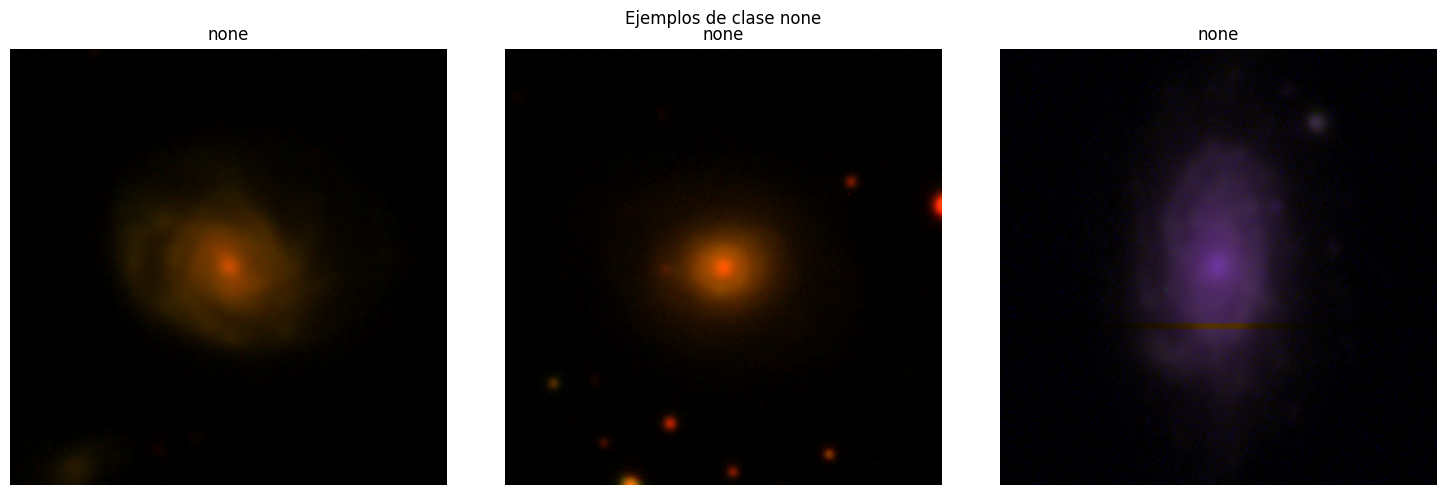

[WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237667967494586544_inner_ra223.444740_dec20.115958_s224.fits')
 WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237651755081007109_inner_ra172.921390_dec3.488024_s224.fits')
 WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237662224596926539_inner_ra163.246090_dec37.613414_s224.fits')]


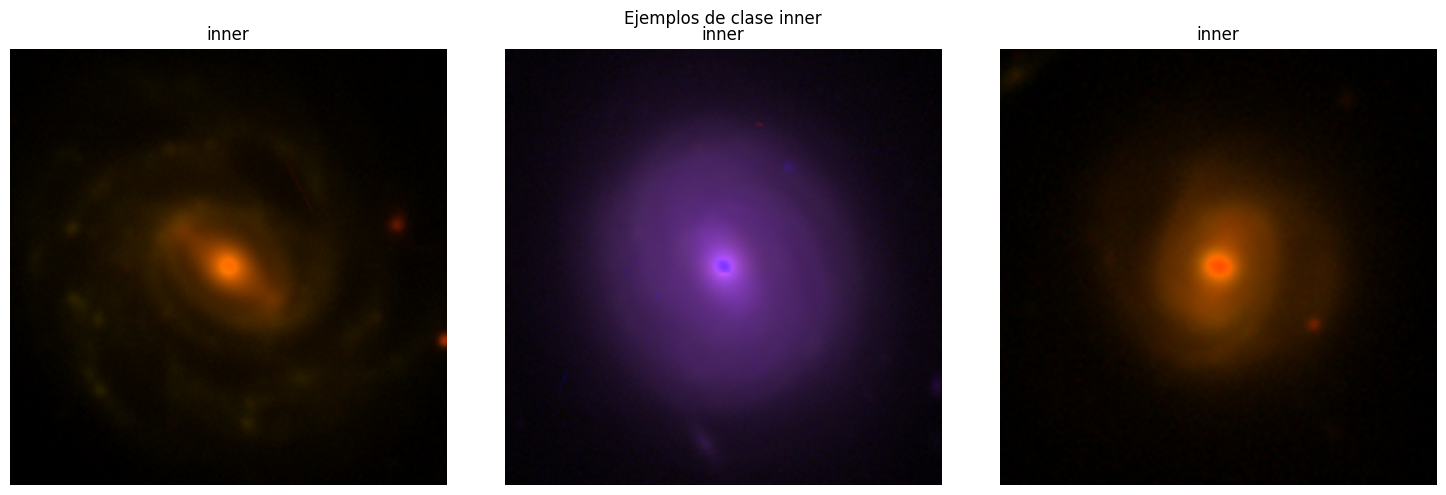

[WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237662636370231323_inner+outer_ra227.998360_dec10.516383_s224.fits')
 WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237667212133859377_inner+outer_ra168.792250_dec29.530080_s224.fits')
 WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237655472357441665_inner+outer_ra247.381410_dec40.412814_s224.fits')]


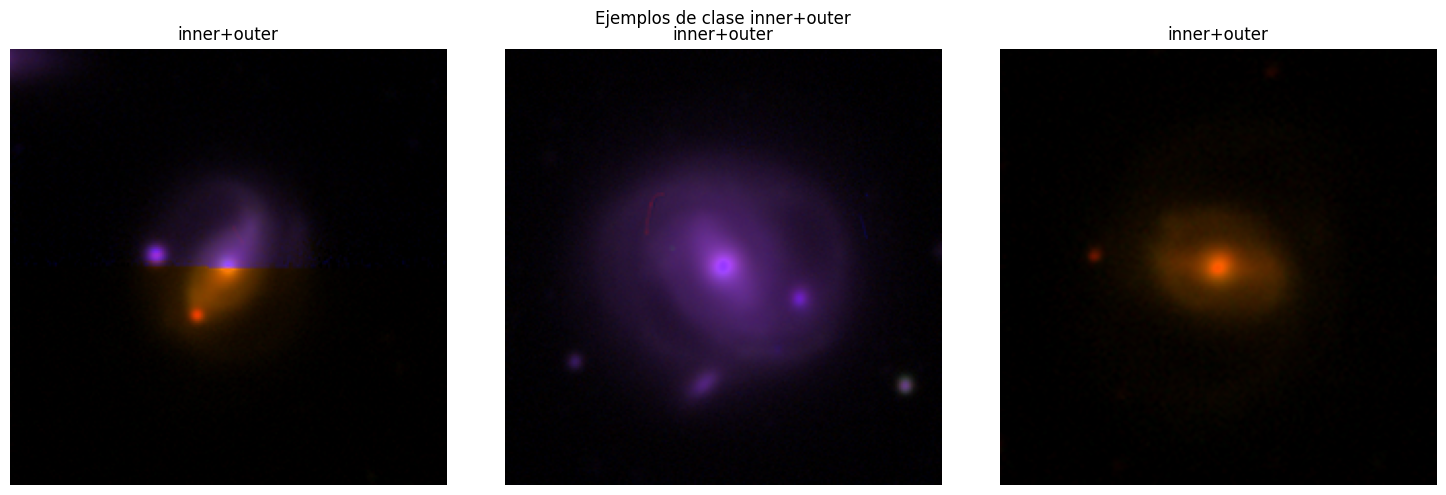

[WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237655465926787251_outer_ra230.236610_dec54.674962_s224.fits')
 WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237662237478551702_outer_ra213.053020_dec8.661841_s224.fits')
 WindowsPath('C:/Users/Oscar/.cache/kagglehub/datasets/domenicomoralesortiz/lsdr10-224-gri-262/versions/1/ls_dr10_224_gri_262/fits/SDSS_1237678617437601937_outer_ra45.214786_dec0.807383_s224.fits')]


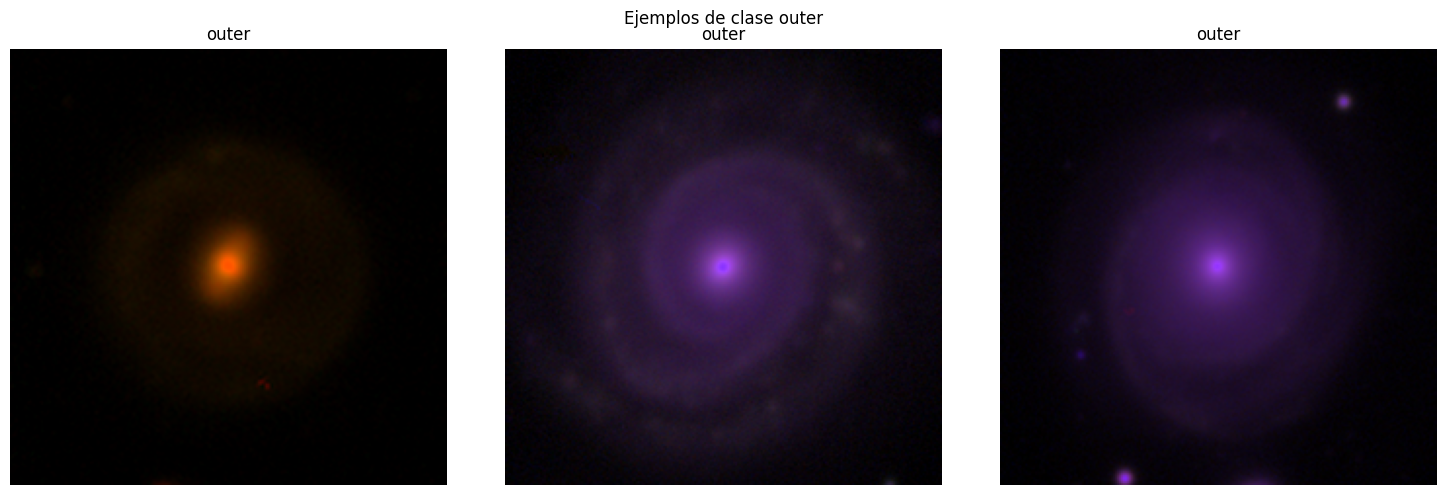

In [ ]:
# Leer el csv para obtener los tipos de anillo
df = pd.read_csv(CSV_PATH)

# Crear la variable para almacenar tipos de anillo
RING_TYPE = list(df["ring_type"].unique())

BANDS = ["G", "R", "I"]

def plot_rgb_sample_images(dataset_path, samples_per_class=3, same_samples=None, return_samples=False):
  """ Visualizar ejemplos de cada clase en formato RGB según sea indicado.

  Args:
      dataset_path (Path): Ruta al dataset.
      samples_per_class (int): Número de imágenes a mostrar por clase.
      same_samples (list, optional): Lista de ejemplos para cada clase.
      return_samples (bool, optional): Devolver los ejemplos.
  """
  # Placeholder para guardar los ejemplos
  samples_used = []

  # Por cada tipo de anillo
  for i, class_name in enumerate(RING_TYPE):
    ring_type_files = list(FITS_PATH.glob(f"*_{class_name}_*.fits"))

    # Asignar los ejemplo o extraerlos
    if same_samples is not None:
      sample_files = same_samples[i]
    else:
      sample_files = np.random.choice(ring_type_files,
                                    size=min(samples_per_class, len(ring_type_files)),
                                    replace=False)
      samples_used.append(sample_files)
    print(sample_files)

    # Por cada ejemplo
    fig, axs = plt.subplots(1, samples_per_class, figsize=(5 * samples_per_class, 5))
    for i, fits_file in enumerate(sample_files):
      # Leer la imagen fits
      with fits.open(fits_file) as hdul:
        data = hdul[0].data
        # Obtener transformación
        rgb_img = make_lupton_rgb(data[1], data[0], data[2], stretch=0.5, Q=8)
        axs[i].imshow(rgb_img, cmap='gray')
        axs[i].set_title(f"{class_name}")
        axs[i].axis('off')
    plt.suptitle(f"Ejemplos de clase {class_name}")
    plt.tight_layout()
    plt.show()

  if return_samples:
    return samples_used

# Visualizar imagenes en RGB y obtener los ejemplos usados
same_samples = plot_rgb_sample_images(FITS_PATH, return_samples=True)

### Segmentación de discos galácticos

In [ ]:
# Parámetros de configuración
PIX_SCALE_AS = 0.262
_RING_COLORS = {
    "outer": "#ff7f0e",
    "inner": "#1f77b4"
}


# === FUNCIONES DE PREPROCESAMIENTO DE IMÁGENES ===

def robust_scale(img, p_lo=1, p_hi=99):
    """
    Normaliza una imagen utilizando percentiles para mayor robustez ante valores extremos.
    Esto evita que píxeles muy brillantes o muy oscuros distorsionen la escala.
    """
    finite = np.isfinite(img)
    if not finite.any():
        return np.zeros_like(img, dtype=np.float32)
    # Usar percentiles en lugar de min/max para robustez
    lo, hi = np.percentile(img[finite], [p_lo, p_hi])
    if hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    # Normalizar al rango [0, 1]
    x = np.clip((img - lo) / (hi - lo), 0, 1)
    return x.astype(np.float32)

def read_fits_gri(path: Path) -> Dict[str, np.ndarray]:
    """
    Lee un archivo FITS con las tres bandas (G, R, I) del Legacy Survey.
    Retorna un diccionario con cada banda separada.
    """
    with fits.open(path, memmap=False) as hdul:
        data = np.asarray(hdul[0].data, dtype=np.float32)
    if data.ndim != 3 or data.shape[0] < 3:
        raise ValueError(f"{path} no contiene las bandas esperadas (gri).")
    # Extraer las tres bandas (orden: G, R, I)
    g = data[0]
    r = data[1]
    i = data[2]
    return {"g": g, "r": r, "i": i}

def stacked_image(gr_dict: Dict[str, np.ndarray]):
    """
    Crea una imagen apilada promediando las tres bandas GRI.
    Esto proporciona una imagen monocromática con mejor relación señal/ruido.
    """
    # Normalizar cada banda y luego promediar
    chans = [robust_scale(gr_dict[b]) for b in ("g", "r", "i")]
    return np.mean(np.stack(chans, axis=0), axis=0)

def estimate_center(image: np.ndarray) -> Tuple[float, float]:
    """
    Estima el centro de la galaxia usando el centroide ponderado por intensidad.
    Esto es más preciso que usar simplemente el centro geométrico de la imagen.
    """
    img = np.nan_to_num(image, nan=0.0)
    total = img.sum()
    if total <= 0:
        # Si la imagen está vacía, usar el centro geométrico
        h, w = image.shape
        return w / 2.0, h / 2.0
    # Calcular centroide ponderado por intensidad
    yy, xx = np.indices(image.shape)
    x0 = float((xx * img).sum() / total)
    y0 = float((yy * img).sum() / total)
    return x0, y0

# === CLASE DE DATOS PARA ALMACENAR MEDICIONES DE ANILLOS ===

@dataclass
class RingMeasurement:
    """
    Almacena todas las propiedades geométricas y fotométricas de un anillo detectado.
    Incluye parámetros de la elipse ajustada, dimensiones físicas y contraste.
    """
    ring_label: str              # Tipo de anillo: 'inner', 'outer', etc.
    center_xy: Tuple[float, float]  # Centro (x, y) en píxeles
    a_pix: float                 # Semieje mayor en píxeles
    b_pix: float                 # Semieje menor en píxeles
    pa_deg: float                # Ángulo de posición en grados
    width_pix: float             # Ancho radial del anillo en píxeles
    width_as: float              # Ancho radial en arcosegundos
    a_as: float                  # Semieje mayor en arcosegundos
    b_as: float                  # Semieje menor en arcosegundos
    circumference_pix: float     # Circunferencia en píxeles
    circumference_as: float      # Circunferencia en arcosegundos
    contrast_mag: float          # Contraste en magnitudes
    method: str                  # Método de ajuste:

# === FUNCIONES AUXILIARES PARA GEOMETRÍA ===

def ellipse_circumference(a: float, b: float) -> float:
    """
    Calcula la circunferencia aproximada de una elipse usando la fórmula de Ramanujan.
    Esta aproximación es muy precisa para todo tipo de elipticidades.
    """
    if a <= 0 or b <= 0:
        return math.nan
    # Fórmula de Ramanujan para circunferencia de elipse
    h = ((a - b) ** 2) / ((a + b) ** 2)
    return math.pi * (a + b) * (1 + (3 * h) / (10 + math.sqrt(max(0.0, 4 - 3 * h))))

def _ellipse_from_mask(mask: np.ndarray) -> Optional[EllipseModel]:
    """
    Ajusta una elipse a una máscara binaria usando RANSAC para robustez ante ruido.
    Este es el método principal para convertir una máscara detectada en parámetros geométricos.
    
    Pasos:
    1. Limpia la máscara de fragmentos pequeños (estrellas, ruido)
    2. Extrae el contorno principal
    3. Ajusta elipse con RANSAC (robusto ante outliers)
    4. Valida que la elipse sea elongada (no circular) y de tamaño razonable
    """
    # Preprocesar: eliminar componentes aislados pequeños (estrellas/ruido)
    mask_cleaned = morphology.remove_small_objects(mask.astype(bool), min_size=64)
    mask_cleaned = morphology.binary_closing(mask_cleaned, morphology.disk(3))
    
    if not mask_cleaned.any():
        return None
    
    # Extraer contornos de la máscara limpia
    contours = measure.find_contours(mask_cleaned, level=0.5)
    if not contours:
        return None
    
    # Usar el contorno más largo (estructura principal del anillo)
    contours_sorted = sorted(contours, key=len, reverse=True)
    main_contour = contours_sorted[0]
    
    # Validar que el contorno tenga suficientes puntos
    if len(main_contour) < 30:
        return None
    
    # Convertir a coordenadas xy (scikit-image devuelve yx)
    pts_xy = np.fliplr(main_contour)
    
    # Submuestrear si hay demasiados puntos (acelera RANSAC)
    if len(pts_xy) > 500:
        indices = np.linspace(0, len(pts_xy) - 1, 500, dtype=int)
        pts_xy = pts_xy[indices]
    
    model = EllipseModel()
    try:
        # Usar RANSAC con tolerancia relajada para aceptar anillos difusos/pequeños
        model_robust, inliers = ransac(
            pts_xy, 
            EllipseModel, 
            min_samples=10,           # Mínimo de puntos para ajustar
            residual_threshold=4.0,   # Tolerancia en píxeles
            max_trials=5000           # Intentos máximos
        )
        
        if model_robust is None:
            return None
        
        # Extraer parámetros para validación
        xc, yc, a, b, theta = model_robust.params
        if b > a:
            a, b = b, a
        
        # Validar aspecto: rechazar ajustes casi circulares (pueden ser discos, no anillos)
        aspect_ratio = b / max(a, 1e-6)
        if aspect_ratio > 0.9:
            return None
        
        # Validar tamaño mínimo
        if a < 10 or b < 7:
            return None
        
        # Validar calidad del ajuste: ratio de inliers debe ser razonable
        if inliers is not None:
            inlier_ratio = np.sum(inliers) / len(inliers)
            if inlier_ratio < 0.25:  # Al menos 25% de puntos deben seguir la elipse
                return None
        
        return model_robust
    except Exception:
        return None

def _ellipse_to_params(model: EllipseModel):
    """
    Extrae y normaliza los parámetros de una elipse.
    Asegura que 'a' sea siempre el semieje mayor.
    """
    xc, yc, a, b, theta = model.params
    # Asegurar que a >= b (convención: a es semieje mayor)
    if b > a:
        a, b = b, a
        theta = (theta + np.pi / 2) % np.pi
    return float(xc), float(yc), float(a), float(b), float(theta)

def _radial_width(mask, xc, yc, a, b, theta):
    """
    Estima el ancho radial del anillo usando la distribución de distancias elípticas.
    Usa cuartiles (Q75 - Q25) para robustez ante valores extremos.
    """
    ys, xs = np.nonzero(mask)
    if len(xs) < 20:
        return math.nan
    
    # Transformar al sistema de coordenadas de la elipse
    cos_t, sin_t = math.cos(theta), math.sin(theta)
    x = xs - xc
    y = ys - yc
    xp = x * cos_t + y * sin_t
    yp = -x * sin_t + y * cos_t
    
    # Calcular distancia elíptica para cada píxel
    q = max(b, 1e-6) / max(a, 1e-6)
    r_e = np.sqrt(xp**2 + (yp / q) ** 2)
    
    # Usar rango intercuartil como medida robusta del ancho
    q25, q75 = np.percentile(r_e, [25, 75])
    return float(q75 - q25)

def _surface_brightness_contrast(image, xc, yc, a, b, theta, dr_pix=3.0):
    """
    Calcula el contraste de brillo superficial entre el anillo y el gap interior.
    Un valor positivo indica que el anillo es más brillante que el gap (anillo en emisión).
    Retorna la diferencia en magnitudes.
    """
    # Crear grilla de coordenadas
    yy, xx = np.indices(image.shape)
    
    # Transformar a coordenadas elípticas
    cos_t, sin_t = math.cos(theta), math.sin(theta)
    x = xx - xc
    y = yy - yc
    xp = x * cos_t + y * sin_t
    yp = -x * sin_t + y * cos_t
    q = max(b, 1e-6) / max(a, 1e-6)
    r_e = np.sqrt(xp**2 + (yp / q) ** 2)
    
    # Definir regiones: anillo y gap interior
    ring_mask = (r_e >= (a - dr_pix)) & (r_e <= (a + dr_pix))
    gap_mask = (r_e >= (a - 2 * dr_pix)) & (r_e < (a - dr_pix))
    
    # Extraer intensidades
    I_ring = image[ring_mask]
    I_gap = image[gap_mask]
    I_ring = I_ring[np.isfinite(I_ring)]
    I_gap = I_gap[np.isfinite(I_gap)]
    
    if len(I_ring) < 50 or len(I_gap) < 50:
        return math.nan
    
    # Convertir a magnitudes (brillo superficial)
    eps = 1e-6
    mu_ring = -2.5 * np.log10(np.clip(I_ring.mean(), eps, None))
    mu_gap = -2.5 * np.log10(np.clip(I_gap.mean(), eps, None))
    
    # Contraste: negativo si anillo es más brillante (menor magnitud)
    return float(mu_ring - mu_gap)


def extract_ring_masks(mask: np.ndarray,
                       ring_type: str,
                       image: Optional[np.ndarray] = None) -> List[Tuple[str, np.ndarray]]:
    """
    Separa componentes individuales de una máscara binaria y los clasifica (outer, inner).
    
    Esta función es crítica para detectar correctamente anillos múltiples (inner+outer).
    Usa un sistema de puntuación inteligente para priorizar componentes periféricos y difusos
    sobre componentes centrales y brillantes cuando se buscan anillos externos.

    Sistema de puntuación para anillos externos:
    - Área (50%): Componentes grandes son preferidos (anillos genuinos vs fragmentos)
    - Periferalidad (30%): Componentes alejados del centro son preferidos (externos vs internos)
    - Penalización por brillo (20%): Componentes tenues son preferidos (anillos difusos vs núcleos brillantes)

    Estrategia dual para detección de anillo interno en casos inner+outer:
    1. Primer intento: Buscar con heurística específica para anillos internos (más confiable)
    2. Segundo intento: Buscar en componentes restantes con filtros geométricos estrictos
    
    Args:
        mask: Máscara binaria con posibles anillos detectados
        ring_type: Tipo de anillo esperado ('outer', 'inner', 'inner+outer')
        image: Imagen original (necesaria para scoring inteligente)
    
    Returns:
        Lista de tuplas (etiqueta, máscara) para cada componente detectado
    """
    mask_bool = mask.astype(bool)
    if not mask_bool.any():
        return []
    
    # Etiquetar componentes conectados
    labeled = measure.label(mask_bool, connectivity=2)
    regions = [r for r in measure.regionprops(labeled) if r.area >= 48]
    if not regions:
        return []
    
    # ANILLOS EXTERNOS: Priorizar componentes periféricos y difusos sobre centrales y brillantes
    # Esto es crucial porque los anillos externos tienden a ser más débiles y alejados del núcleo
    if ring_type in ("outer", "inner+outer") and image is not None:
        # Calcular centro de la imagen como referencia
        img_center_y, img_center_x = np.array(image.shape) / 2.0
        
        # Sistema de puntuación: área (50%) + periferalidad (30%) - brillo (20%)
        # Componentes grandes, periféricos y tenues obtienen mayor puntuación
        scored_regions = []
        for r in regions:
            cy, cx = r.centroid
            dist_from_center = np.sqrt((cx - img_center_x)**2 + (cy - img_center_y)**2)
            
            # Extraer intensidad promedio en esta región
            # Para outer: menor intensidad es mejor (anillos difusos vs núcleos brillantes)
            region_mask = labeled == r.label
            mean_intensity = np.mean(image[region_mask])
            
            # Normalizar componentes del score para comparación justa
            peripherality_score = dist_from_center / max(image.shape)  # [0, ~1]
            area_score = r.area / max([rr.area for rr in regions])      # [0, 1]
            intensity_penalty = mean_intensity / (np.mean(image) + 1e-6)  # Relativo al promedio
            
            # Combinar: favorece grande + periférico + tenue
            score = area_score * 0.5 + peripherality_score * 0.3 - intensity_penalty * 0.2
            scored_regions.append((score, r))
        
        # Ordenar por puntuación: mejor candidato primero
        scored_regions.sort(key=lambda x: x[0], reverse=True)
        regions = [r for _, r in scored_regions]
    else:
        # Para inner o casos sin imagen: simplemente ordenar por área (más simple)
        regions.sort(key=lambda r: r.area, reverse=True)
    
    components: List[Tuple[str, np.ndarray]] = []

    # CASO ESPECIAL: INNER+OUTER (galaxias con dos anillos distintos)
    # Requiere estrategia dual para separar correctamente ambos componentes
    if ring_type == "inner+outer":
        # Paso 1: Identificar el anillo externo (ya ordenado por scoring, el primero es el mejor)
        outer_region = regions[0]
        outer_mask = (labeled == outer_region.label).astype(np.uint8)
        components.append(("outer", outer_mask))

        # Extraer propiedades geométricas del externo para validación del interno
        outer_cy, outer_cx = outer_region.centroid
        outer_major = max(outer_region.major_axis_length, 1e-3)
        outer_minor = max(outer_region.minor_axis_length, 1e-3)
        outer_area = outer_region.area

        # Definir región interior donde debe estar el anillo interno
        # Rellenamos huecos y erosionamos para obtener el área contenida por el externo
        outer_interior = ndi.binary_fill_holes(outer_mask.astype(bool))
        outer_interior = morphology.binary_erosion(outer_interior, morphology.disk(3))
        if not outer_interior.any():
            outer_interior = outer_mask.astype(bool)

        # Paso 2a: ESTRATEGIA PRIMARIA - Buscar anillo interno con heurística específica
        # Esto es más confiable que buscar en componentes ya detectados
        inner_mask = None
        if image is not None:
            # Aplicar detección especializada para anillos internos
            inner_candidate = heuristic_ring_mask(image, "inner").astype(bool)
            # Restringir búsqueda al interior del externo
            inner_candidate &= outer_interior
            inner_candidate = morphology.remove_small_objects(inner_candidate, min_size=64)
            
            if inner_candidate.any():
                labeled_inner = measure.label(inner_candidate, connectivity=2)
                inner_regions = [r for r in measure.regionprops(labeled_inner) if r.area >= 64]
                
                # Filtros de validación geométrica (relajados para mayor sensibilidad)
                valid_inner = []
                for r in inner_regions:
                    # Debe ser más pequeño que el externo (15% del tamaño)
                    if r.major_axis_length < outer_major * 0.15:
                        continue
                    # Debe tener área significativa (3% del externo)
                    if r.area < outer_area * 0.03:
                        continue
                    # Debe ser elongado, no circular (aspecto < 0.9)
                    aspect_ratio = r.minor_axis_length / max(r.major_axis_length, 1e-3)
                    if aspect_ratio > 0.9:
                        continue
                    # Debe tener excentricidad mínima (Evita nucleos galacticos y estrellas)
                    if r.eccentricity < 0.3:
                        continue
                    # Debe ser razonablemente compacto (solidity > 0.6)
                    if r.solidity < 0.6:
                        continue
                    valid_inner.append(r)
                
                if valid_inner:
                    # Preferir candidatos grandes y elongados
                    valid_inner.sort(key=lambda r: r.area * (1 - aspect_ratio), reverse=True)
                    inner_mask = (labeled_inner == valid_inner[0].label).astype(np.uint8)

        # Paso 2b: ESTRATEGIA SECUNDARIA - Buscar en componentes restantes
        # Solo si la estrategia primaria falló
        if inner_mask is None:
            for region in regions[1:]:  # Saltar el anillo externo (ya procesado)
                # Debe ser estrictamente menor que el externo
                if region.major_axis_length >= outer_major or region.minor_axis_length >= outer_minor:
                    continue
                # Filtros de tamaño mínimo
                if region.major_axis_length < outer_major * 0.15:
                    continue
                if region.area < outer_area * 0.03:
                    continue
                
                # Filtros de forma: debe ser elongado
                aspect_ratio = region.minor_axis_length / max(region.major_axis_length, 1e-3)
                if aspect_ratio > 0.9:
                    continue
                # Excentricidad mínima (Evita núcleos galácticos y estrellas)
                if region.eccentricity < 0.25:
                    continue
                # Validación adicional: rechazar estructuras muy sólidas (barras centrales)
                if region.solidity < 0.6:
                    continue

                # Verificar que esté contenido dentro del anillo externo (coordenadas elípticas)
                cy, cx = region.centroid
                norm_x = (cx - outer_cx) / (outer_major * 0.5)
                norm_y = (cy - outer_cy) / (outer_minor * 0.5)
                # Debe estar dentro de la elipse del anillo externo (con margen 5%)
                if norm_x**2 + norm_y**2 <= 1.05:
                    candidate = ((labeled == region.label).astype(bool)) & outer_interior
                    candidate = morphology.remove_small_objects(candidate, min_size=64)
                    if candidate.any():
                        inner_mask = candidate.astype(np.uint8)
                        break

        # Agregar el anillo interno si se encontró
        if inner_mask is not None:
            components.append(("inner", inner_mask))
    
    # CASOS SIMPLES: OUTER, INNER o NONE
    # Solo hay un componente dominante
    else:
        dominant = regions[0]
        label_name = ring_type if ring_type not in ("none", "") else "disk"
        components = [(label_name, (labeled == dominant.label).astype(np.uint8))]

    return components

def measure_ring_from_mask(image,
                           mask,
                           pixscale_as=PIX_SCALE_AS,
                           ring_label: str = "disk"):
    """
    Ajusta una elipse a una máscara de anillo usando RANSAC y calcula sus propiedades.
    
    Pipeline de medición en 4 pasos:
    1. Limpieza de máscara: remover estrellas y artefactos pequeños
    2. Ajuste RANSAC: método robusto para elipses elongadas
    3. Validación: verificar solapamiento con máscara y posición del centro
    4. Cálculo de propiedades: ancho radial, contraste, circunferencia
    
    Criterios de rechazo:
    - Aspect ratio > 0.9 (demasiado circular, probablemente no un anillo)
    - Tamaño mínimo: a < 8px o b < 6px
    - Solapamiento con máscara < 20%
    - Centro desplazado > 60% del semieje mayor
    """
    # Paso 1: Limpiar máscara de estrellas y fragmentos pequeños
    mask = morphology.remove_small_objects(mask.astype(bool), min_size=64)
    mask = morphology.binary_opening(mask, morphology.disk(2))
    mask = morphology.binary_closing(mask, morphology.disk(4))
    mask = mask.astype(np.uint8)
    if mask.sum() == 0:
        return None
    
    # Paso 2: Ajuste RANSAC (único método, sin fallback)
    model = _ellipse_from_mask(mask)
    if model is None:
        return None
    
    # Paso 3: Validar resultado de RANSAC
    xc, yc, a, b, theta = _ellipse_to_params(model)
    
    # Validación 1: Rechazar ajustes casi circulares
    aspect_ratio = b / max(a, 1e-6)
    if aspect_ratio > 0.9:
        return None
    
    # Validación 2: Rechazar tamaños muy pequeños
    if a < 8 or b < 6:
        return None
    
    # Validación 3: Verificar que la elipse tenga sentido dado la máscara
    yy, xx = np.indices(mask.shape)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    x = xx - xc
    y = yy - yc
    xp = x * cos_t + y * sin_t
    yp = -x * sin_t + y * cos_t
    q = max(b, 1e-6) / max(a, 1e-6)
    r_e = np.sqrt(xp**2 + (yp / q) ** 2)
    
    # Verificar solapamiento entre elipse ajustada y máscara real
    ellipse_ring = (r_e >= a * 0.75) & (r_e <= a * 1.25)
    overlap = np.sum(ellipse_ring & mask.astype(bool)) / max(np.sum(ellipse_ring), 1)
    
    # Verificar que la elipse no esté centrada en un punto brillante lejos de la máscara
    mask_centroid_y, mask_centroid_x = ndi.center_of_mass(mask)
    dist_from_mask_center = np.sqrt((xc - mask_centroid_x)**2 + (yc - mask_centroid_y)**2)
    max_allowed_offset = max(a, b) * 0.6
    
    # Rechazar si solapamiento bajo o centro muy desplazado
    if overlap < 0.2 or dist_from_mask_center > max_allowed_offset:
        return None
    
    # Paso 4: Calcular propiedades geométricas y fotométricas
    width_pix = _radial_width(mask, xc, yc, a, b, theta)
    contrast = _surface_brightness_contrast(image, xc, yc, a, b, theta, dr_pix=max(3, 0.05 * a))
    circ_pix = ellipse_circumference(a, b)
    circ_as = circ_pix * pixscale_as if math.isfinite(circ_pix) else math.nan
    
    return RingMeasurement(
        ring_label=ring_label,
        center_xy=(xc, yc),
        a_pix=a,
        b_pix=b,
        pa_deg=theta * 180.0 / math.pi,
        width_pix=width_pix,
        width_as=width_pix * pixscale_as if math.isfinite(width_pix) else math.nan,
        a_as=a * pixscale_as,
        b_as=b * pixscale_as,
        circumference_pix=circ_pix,
        circumference_as=circ_as,
        contrast_mag=contrast,
        method="ransac",
    )

def heuristic_ring_mask(image: np.ndarray, ring_type: str) -> np.ndarray:
    """
    Genera una máscara binaria de anillo usando preprocesamiento especializado según el tipo.

    Esta es la función central del pipeline de detección. Cada tipo de anillo requiere
    una estrategia de preprocesamiento diferente para maximizar la detección:
    
    OUTER RINGS (anillos externos difusos):
    - Objetivo: Detectar estructuras débiles, difusas y alejadas del núcleo
    - Estrategia: Suavizado fuerte, supresión del núcleo, realce gamma, unsharp mask agresivo
    - Umbrales Canny bajos (0.03/0.10) para capturar bordes tenues
    - Remoción de fuentes brillantes compactas (estrellas que interfieren con RANSAC)
    
    INNER RINGS (anillos internos compactos):
    - Objetivo: Detectar estructuras compactas, bien definidas cerca del núcleo
    - Estrategia: Suavizado moderado, conectividad mejorada, anti-fragmentación
    - Umbrales Canny medios (0.05/0.15) para estructuras definidas
    - Distance transform conservador para obtener esqueleto del anillo
    
    INNER+OUTER (galaxias con dos anillos):
    - Objetivo: Detectar ambos componentes simultáneamente
    - Estrategia: Pipeline dual combinando ambos enfoques
    - Outer con estrategia difusa + Inner con estrategia compacta
    - Unión lógica de ambas máscaras
    """
    work_img = image.copy()
    ringy = None
    # ============================================================================
    # OUTER RINGS: Preprocesamiento especializado para estructuras difusas y tenues
    # ============================================================================
    if ring_type == "outer":
        # Paso 1: Suavizado fuerte para enfatizar características de gran escala
        work_img = ndi.gaussian_filter(image, sigma=3.5)
        
        # Paso 2: Suprime regiones centrales brillantes
        # Esto evita que el núcleo domine la detección
        p90 = np.percentile(work_img[work_img > 0], 90)
        bright_mask = work_img > p90
        bright_core = morphology.binary_erosion(bright_mask, morphology.disk(6))
        bright_core = morphology.binary_dilation(bright_core, morphology.disk(10))
        
        if bright_core.any():
            work_img_suppressed = work_img.copy()
            work_img_suppressed[bright_core] = np.median(work_img[~bright_core])
            work_img = work_img_suppressed
        
        # Paso 3: Realzar características tenues con ecualización adaptativa
        # Gamma < 1 amplifica valores bajos (estructuras débiles)
        work_min, work_max = work_img.min(), work_img.max()
        if work_max > work_min:
            work_norm = (work_img - work_min) / (work_max - work_min)
            work_norm = np.clip(work_norm ** 0.7, 0, 1)
            work_img = work_norm * (work_max - work_min) + work_min
        
        # Paso 4: Unsharp mask fuerte para realzar bordes difusos
        work_img = unsharp_mask(work_img, radius=4.0, amount=2.0)
        
        # Paso 5: Umbrales Canny bajos para detectar bordes tenues
        edges = feature.canny(work_img, sigma=3.0, low_threshold=0.03, high_threshold=0.10)
        
        # Paso 6: Morfología moderada - balance entre conectividad y delgadez
        ringy = morphology.binary_dilation(edges, morphology.disk(2))
        ringy = morphology.binary_closing(ringy, morphology.disk(2))
        ringy = morphology.remove_small_objects(ringy, min_size=48)
        
        # Paso 7: Opening morfológico para suavizar protuberancias y reducir grosor
        ringy = morphology.binary_opening(ringy, morphology.disk(2))

        # Paso 8: Remueve fuentes brillantes redondas (estrellas, objetos en primer plano)
        # Estas interfieren con RANSAC al crear outliers circulares
        bright_threshold = np.percentile(image[image > 0], 99.5)
        bright_sources = image > bright_threshold
        bright_sources = morphology.binary_opening(bright_sources, morphology.disk(2))
        
        # Etiquetar y filtrar por forma: remover objetos compactos circulares
        labeled_bright = measure.label(bright_sources)
        for region in measure.regionprops(labeled_bright):
            # Mantener solo objetos muy compactos y circulares (probablemente estrellas)
            if region.area < 200 and region.eccentricity < 0.6:  # Circular y pequeño
                # Dilatar para asegurar remoción completa
                source_mask = labeled_bright == region.label
                source_mask_dilated = morphology.binary_dilation(source_mask, morphology.disk(5))
                ringy = ringy & ~source_mask_dilated
        
    # ============================================================================
    # INNER+OUTER: Pipeline dual combinando ambas estrategias
    # ============================================================================
    elif ring_type == "inner+outer":
        # COMPONENTE OUTER: usa el mismo enfoque del caso externo solo
        work_outer = ndi.gaussian_filter(image, sigma=3.5)
        p90 = np.percentile(work_outer[work_outer > 0], 90)
        bright_mask = work_outer > p90
        bright_core = morphology.binary_erosion(bright_mask, morphology.disk(6))
        bright_core = morphology.binary_dilation(bright_core, morphology.disk(10))
        
        if bright_core.any():
            work_outer[bright_core] = np.median(work_outer[~bright_core])
        
        # Realzar características tenues
        work_min, work_max = work_outer.min(), work_outer.max()
        if work_max > work_min:
            work_norm = (work_outer - work_min) / (work_max - work_min)
            work_norm = np.clip(work_norm ** 0.7, 0, 1)
            work_outer = work_norm * (work_max - work_min) + work_min
        
        # Unsharp mask fuerte
        work_outer = unsharp_mask(work_outer, radius=4.0, amount=2.0)

        # Detectar bordes externos
        outer_edges = feature.canny(work_outer, sigma=3.0, low_threshold=0.03, high_threshold=0.10)
        ringy = morphology.binary_dilation(outer_edges, morphology.disk(2))
        ringy = morphology.binary_closing(ringy, morphology.disk(2))
        ringy = morphology.remove_small_objects(ringy, min_size=48)
        ringy = morphology.binary_opening(ringy, morphology.disk(2))
        
        # Remover fuentes brillantes redondas 
        bright_threshold = np.percentile(image[image > 0], 99.5)
        bright_sources = image > bright_threshold
        bright_sources = morphology.binary_opening(bright_sources, morphology.disk(2))
        
        labeled_bright = measure.label(bright_sources)
        for region in measure.regionprops(labeled_bright):
            if region.area < 200 and region.eccentricity < 0.6:
                source_mask = labeled_bright == region.label
                source_mask_dilated = morphology.binary_dilation(source_mask, morphology.disk(5))
                ringy = ringy & ~source_mask_dilated
        
        # COMPONENTE INNER: preprocesamiento diferente para características compactas
        inner_work = ndi.gaussian_filter(image, sigma=1.6)
        inner_edges = feature.canny(inner_work, sigma=1.8, low_threshold=0.05, high_threshold=0.15)
        inner = morphology.binary_dilation(inner_edges, morphology.disk(2))
        inner = ndi.binary_fill_holes(inner)
        inner = morphology.remove_small_objects(inner, min_size=48)
        
        # Combinar ambos componentes
        ringy = np.logical_or(ringy, inner)
        ringy = morphology.binary_closing(ringy, morphology.disk(2))
        
    # ============================================================================
    # INNER RINGS: Preprocesamiento para estructuras compactas y bien definidas
    # ============================================================================
    elif ring_type == "inner":
        # Suavizado moderado para inner rings
        work_img = ndi.gaussian_filter(image, sigma=1.6)
        edges = feature.canny(work_img, sigma=1.8, low_threshold=0.05, high_threshold=0.15)

        # Construir máscara conectada con closing antes de rellenar huecos
        ringy = morphology.binary_dilation(edges, morphology.disk(2))
        ringy = morphology.binary_closing(ringy, morphology.disk(3))  
        ringy = ndi.binary_fill_holes(ringy)
        
        # Remover fragmentos pequeños
        ringy = morphology.remove_small_objects(ringy, min_size=100)  # Incrementado de 64
        
        # Refinamiento suave para obtener estructura de anillo sin fragmentar
        ringy = morphology.binary_erosion(ringy, morphology.disk(1))  
        ringy = morphology.binary_dilation(ringy, morphology.disk(2))

        # Usar distance transform conservadoramente
        # Esto obtiene el "esqueleto" del anillo sin adelgazarlo demasiado
        dist = ndi.distance_transform_edt(ringy)
        core = dist >= 1.5  
        if core.any() and np.sum(core) > 50:  # Solo usar si el resultado es sustancial
            ringy = core
            # Rellenar pequeños gaps creados por distance transform
            ringy = morphology.binary_closing(ringy, morphology.disk(2))
        
        # Limpieza final
        ringy = morphology.remove_small_objects(ringy, min_size=48)
            
    return ringy.astype(np.uint8)

def segment_and_measure_ring(fits_path: Path,
                             ring_type: str,
                             pixscale_as: float = PIX_SCALE_AS):
    """
    Pipeline completo de segmentación y medición de anillos galácticos.
    
    Flujo en 5 pasos:
    1. Leer archivo FITS y extraer bandas GRI
    2. Apilar bandas para obtener imagen monocromática con mejor SNR
    3. Generar máscara heurística especializada según tipo de anillo
    4. Extraer y separar componentes individuales (outer/inner)
    5. Ajustar elipses con RANSAC y calcular propiedades para cada componente
    
    Returns:
        tuple: (imagen apilada, máscara binaria, lista de mediciones)
    """
    gri = read_fits_gri(fits_path)
    img = stacked_image(gri)
    mask = heuristic_ring_mask(img, ring_type)
    ring_masks = extract_ring_masks(mask, ring_type, image=img)
    measurements: List[RingMeasurement] = []
    for label_name, component_mask in ring_masks:
        meas = measure_ring_from_mask(img, component_mask,
                                      pixscale_as=pixscale_as,
                                      ring_label=label_name)
        if meas is not None:
            measurements.append(meas)
    return img, mask, measurements

def visualize_ring_segmentation(fits_path: Path, ring_type: str):
    """
    Visualiza los resultados de la segmentación de anillos en dos paneles.
    
    Panel izquierdo: Imagen apilada GRI en escala de grises
    Panel derecho: Imagen + máscara heurística (rojo) + elipses ajustadas (coloreadas)
    
    Para cada anillo detectado se muestra:
    - Elipse ajustada con color según tipo (outer=naranja, inner=azul)
    - Etiqueta con tipo, circunferencia en píxeles y arcosegundos
    - Propiedades impresas: semiejes, ángulo de posición, método de ajuste (siempre RANSAC)
    """
    img, mask, measurements = segment_and_measure_ring(fits_path, ring_type=ring_type)
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(img, cmap="gray")
    axs[0].set_title(f"{fits_path.name}\nStack GRI")
    axs[0].axis("off")
    axs[1].imshow(img, cmap="gray")
    axs[1].imshow(mask, cmap="Reds", alpha=0.35)
    axs[1].set_title("Máscara heurística + elipses")
    axs[1].axis("off")

    for idx, meas in enumerate(measurements):
        color = _RING_COLORS.get(meas.ring_label, _RING_COLORS.get(ring_type, "#2ca02c"))
        ellipse_patch = MplEllipse(
            xy=meas.center_xy,
            width=2 * meas.a_pix,
            height=2 * meas.b_pix,
            angle=meas.pa_deg,
            fill=False,
            edgecolor=color,
            linewidth=2,
        )
        axs[1].add_patch(ellipse_patch)
        axs[1].text(
            meas.center_xy[0] + 8,
            meas.center_xy[1] - 12 * (idx + 1),
            f"{meas.ring_label.capitalize()} · C={meas.circumference_pix:.1f}px ({meas.circumference_as:.2f}\")",
            color="white",
            fontsize=8,
            bbox=dict(facecolor=color, alpha=0.6, edgecolor="none", pad=2),
        )

    plt.tight_layout()
    plt.show()

    if not measurements:
        print("No se encontró anillo.")
    else:
        for meas in measurements:
            circ_as = None if not math.isfinite(meas.circumference_as) else f"{meas.circumference_as:.2f}\""
            print(
                f"{meas.ring_label.capitalize()} → "
                f"a={meas.a_pix:.1f}px ({meas.a_as:.2f}\"), "
                f"b={meas.b_pix:.1f}px ({meas.b_as:.2f}\"), "
                f"C={meas.circumference_pix:.1f}px ({circ_as}), "
                f"PA={meas.pa_deg:.1f}°, método={meas.method}"
            )


Clase: INNER

Muestra 1: SDSS_1237667967494586544_inner_ra223.444740_dec20.115958_s224.fits
  • Inner → a=38.4px (10.06"), b=29.7px (7.79"), C=214.9px (56.31"), PA=46.7°

Muestra 2: SDSS_1237651755081007109_inner_ra172.921390_dec3.488024_s224.fits
  • Inner → a=20.0px (5.23"), b=15.3px (4.00"), C=111.2px (29.14"), PA=65.5°

Muestra 1: SDSS_1237667967494586544_inner_ra223.444740_dec20.115958_s224.fits
  • Inner → a=38.4px (10.06"), b=29.7px (7.79"), C=214.9px (56.31"), PA=46.7°

Muestra 2: SDSS_1237651755081007109_inner_ra172.921390_dec3.488024_s224.fits
  • Inner → a=20.0px (5.23"), b=15.3px (4.00"), C=111.2px (29.14"), PA=65.5°

Muestra 3: SDSS_1237662224596926539_inner_ra163.246090_dec37.613414_s224.fits
  • Inner → a=33.1px (8.66"), b=15.1px (3.96"), C=156.7px (41.04"), PA=99.7°

Muestra 3: SDSS_1237662224596926539_inner_ra163.246090_dec37.613414_s224.fits
  • Inner → a=33.1px (8.66"), b=15.1px (3.96"), C=156.7px (41.04"), PA=99.7°


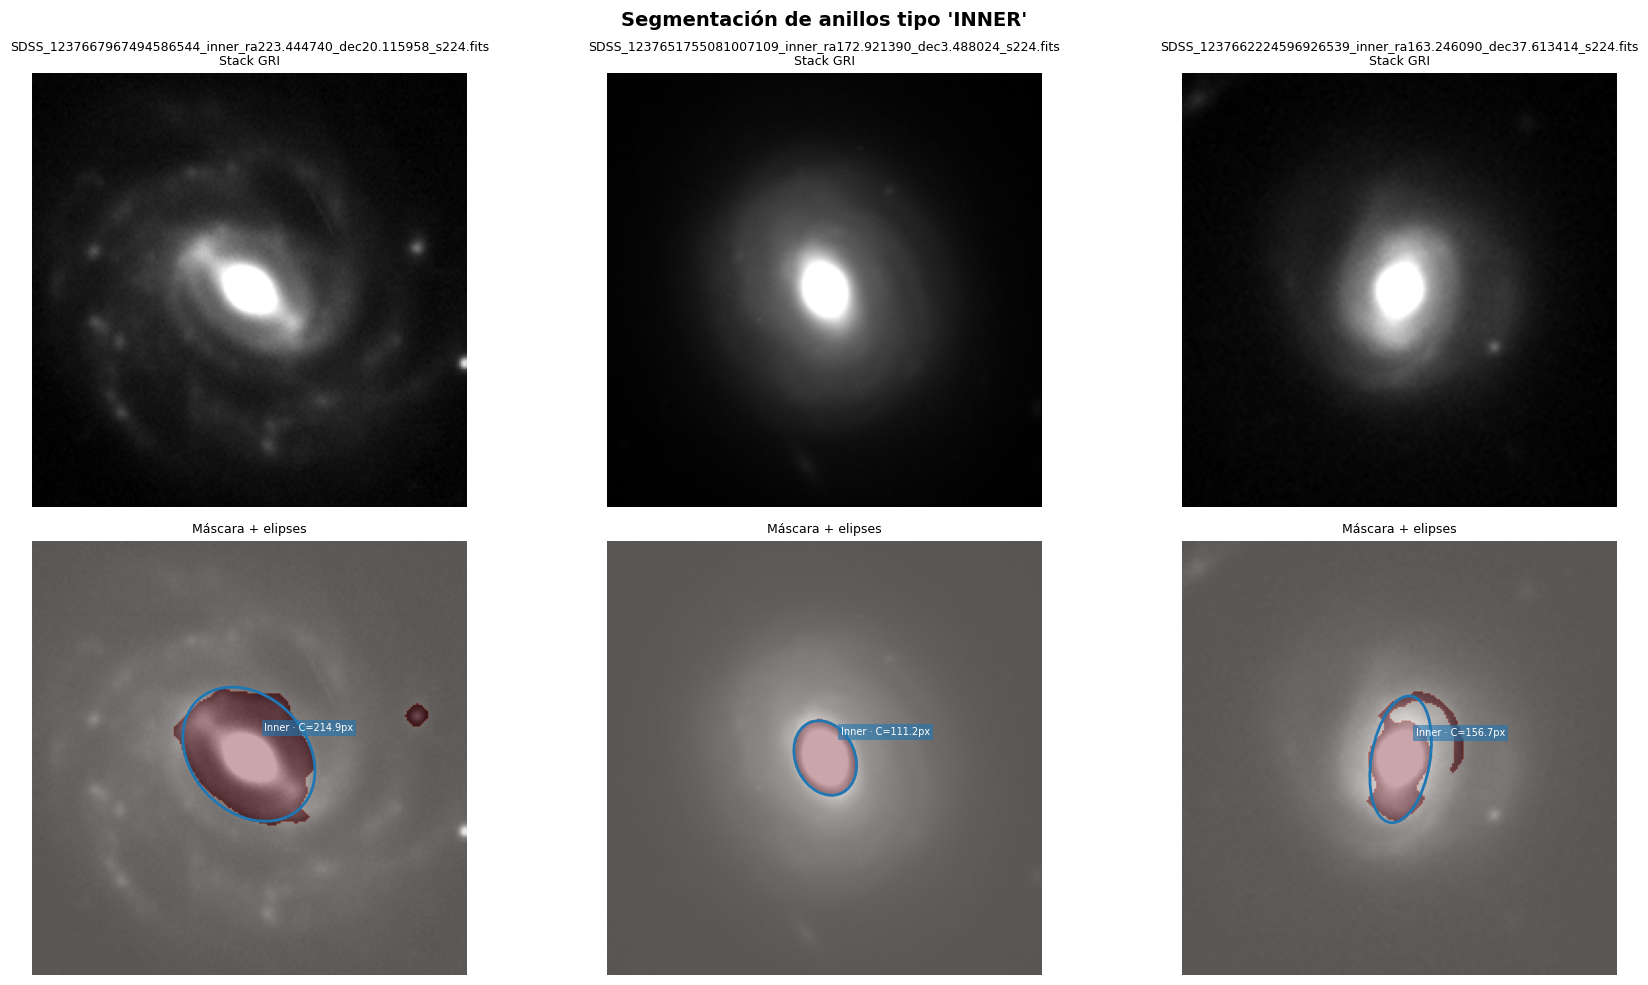


Clase: INNER+OUTER

Muestra 1: SDSS_1237662636370231323_inner+outer_ra227.998360_dec10.516383_s224.fits
  • Outer → a=51.8px (13.58"), b=40.0px (10.49"), C=289.8px (75.93"), PA=141.3°
  • Inner → a=31.4px (8.22"), b=13.4px (3.50"), C=146.3px (38.34"), PA=122.2°

Muestra 1: SDSS_1237662636370231323_inner+outer_ra227.998360_dec10.516383_s224.fits
  • Outer → a=51.8px (13.58"), b=40.0px (10.49"), C=289.8px (75.93"), PA=141.3°
  • Inner → a=31.4px (8.22"), b=13.4px (3.50"), C=146.3px (38.34"), PA=122.2°

Muestra 2: SDSS_1237667212133859377_inner+outer_ra168.792250_dec29.530080_s224.fits
  • Outer → a=61.8px (16.19"), b=46.8px (12.27"), C=342.8px (89.82"), PA=44.2°
  • Inner → a=21.7px (5.67"), b=14.1px (3.70"), C=113.6px (29.77"), PA=52.4°

Muestra 2: SDSS_1237667212133859377_inner+outer_ra168.792250_dec29.530080_s224.fits
  • Outer → a=61.8px (16.19"), b=46.8px (12.27"), C=342.8px (89.82"), PA=44.2°
  • Inner → a=21.7px (5.67"), b=14.1px (3.70"), C=113.6px (29.77"), PA=52.4°

Muestra 3: 

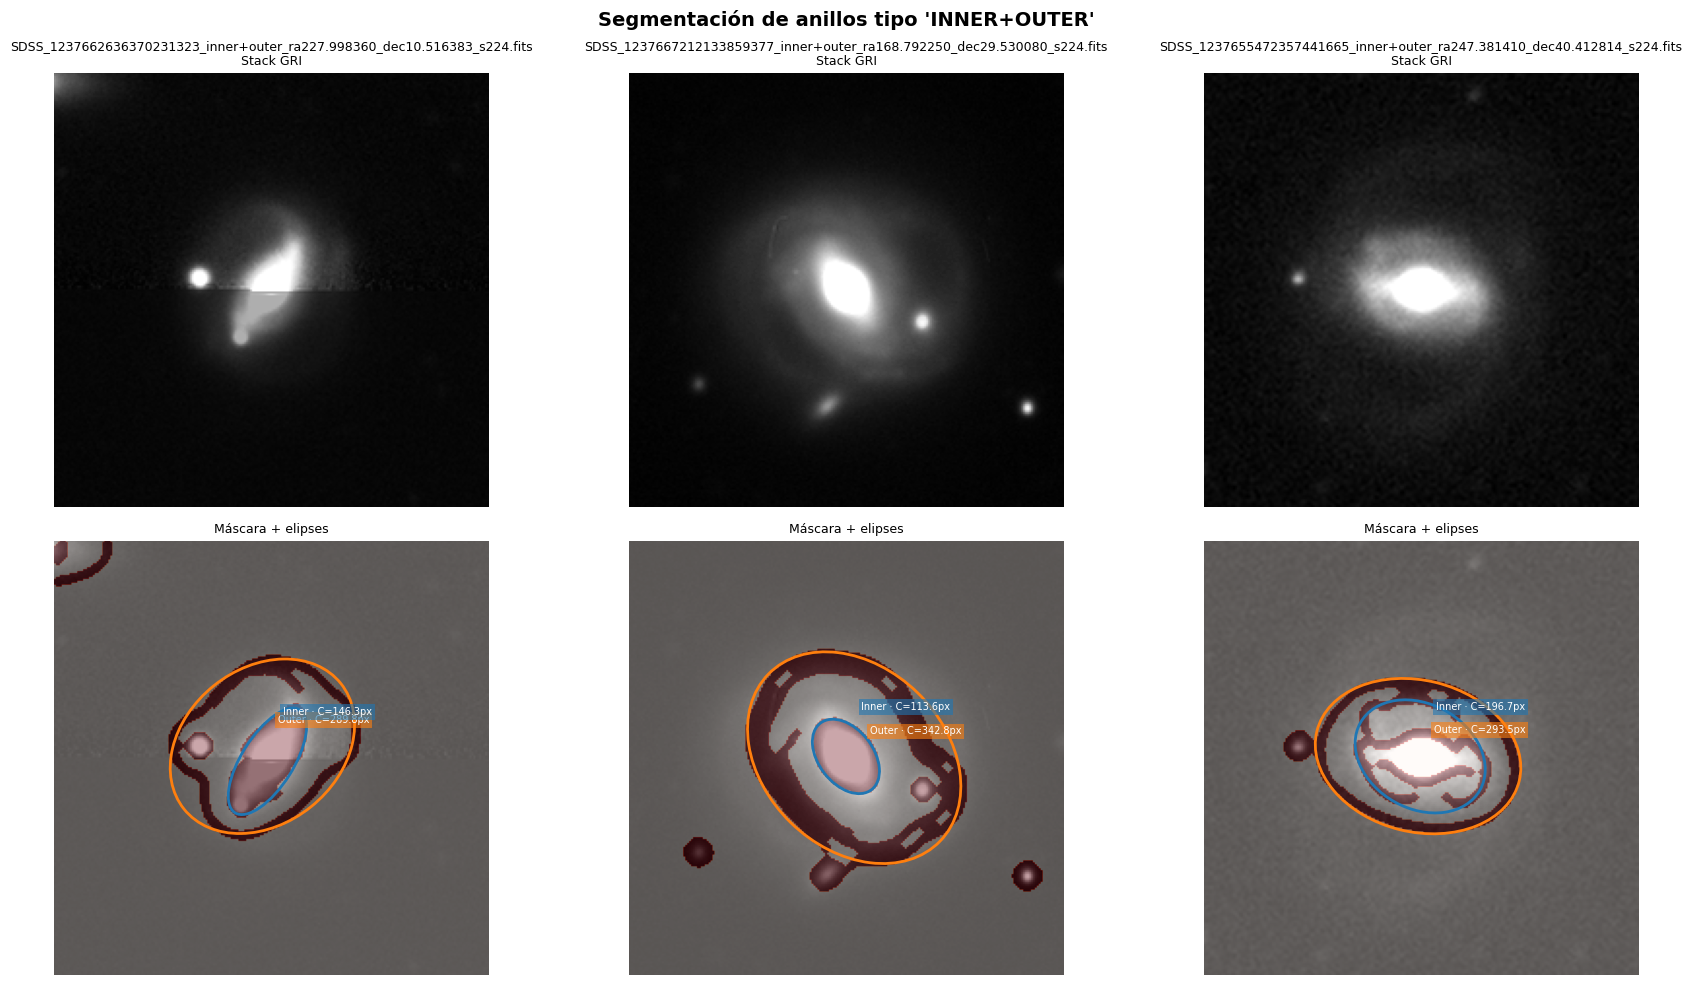


Clase: OUTER

Muestra 1: SDSS_1237655465926787251_outer_ra230.236610_dec54.674962_s224.fits
  • Outer → a=51.8px (13.57"), b=29.2px (7.66"), C=259.5px (68.00"), PA=82.8°

Muestra 1: SDSS_1237655465926787251_outer_ra230.236610_dec54.674962_s224.fits
  • Outer → a=51.8px (13.57"), b=29.2px (7.66"), C=259.5px (68.00"), PA=82.8°

Muestra 2: SDSS_1237662237478551702_outer_ra213.053020_dec8.661841_s224.fits
  • Outer → a=71.8px (18.82"), b=54.2px (14.20"), C=397.9px (104.25"), PA=123.1°

Muestra 2: SDSS_1237662237478551702_outer_ra213.053020_dec8.661841_s224.fits
  • Outer → a=71.8px (18.82"), b=54.2px (14.20"), C=397.9px (104.25"), PA=123.1°

Muestra 3: SDSS_1237678617437601937_outer_ra45.214786_dec0.807383_s224.fits
  • Outer → a=71.5px (18.74"), b=63.6px (16.67"), C=424.9px (111.32"), PA=73.5°

Muestra 3: SDSS_1237678617437601937_outer_ra45.214786_dec0.807383_s224.fits
  • Outer → a=71.5px (18.74"), b=63.6px (16.67"), C=424.9px (111.32"), PA=73.5°


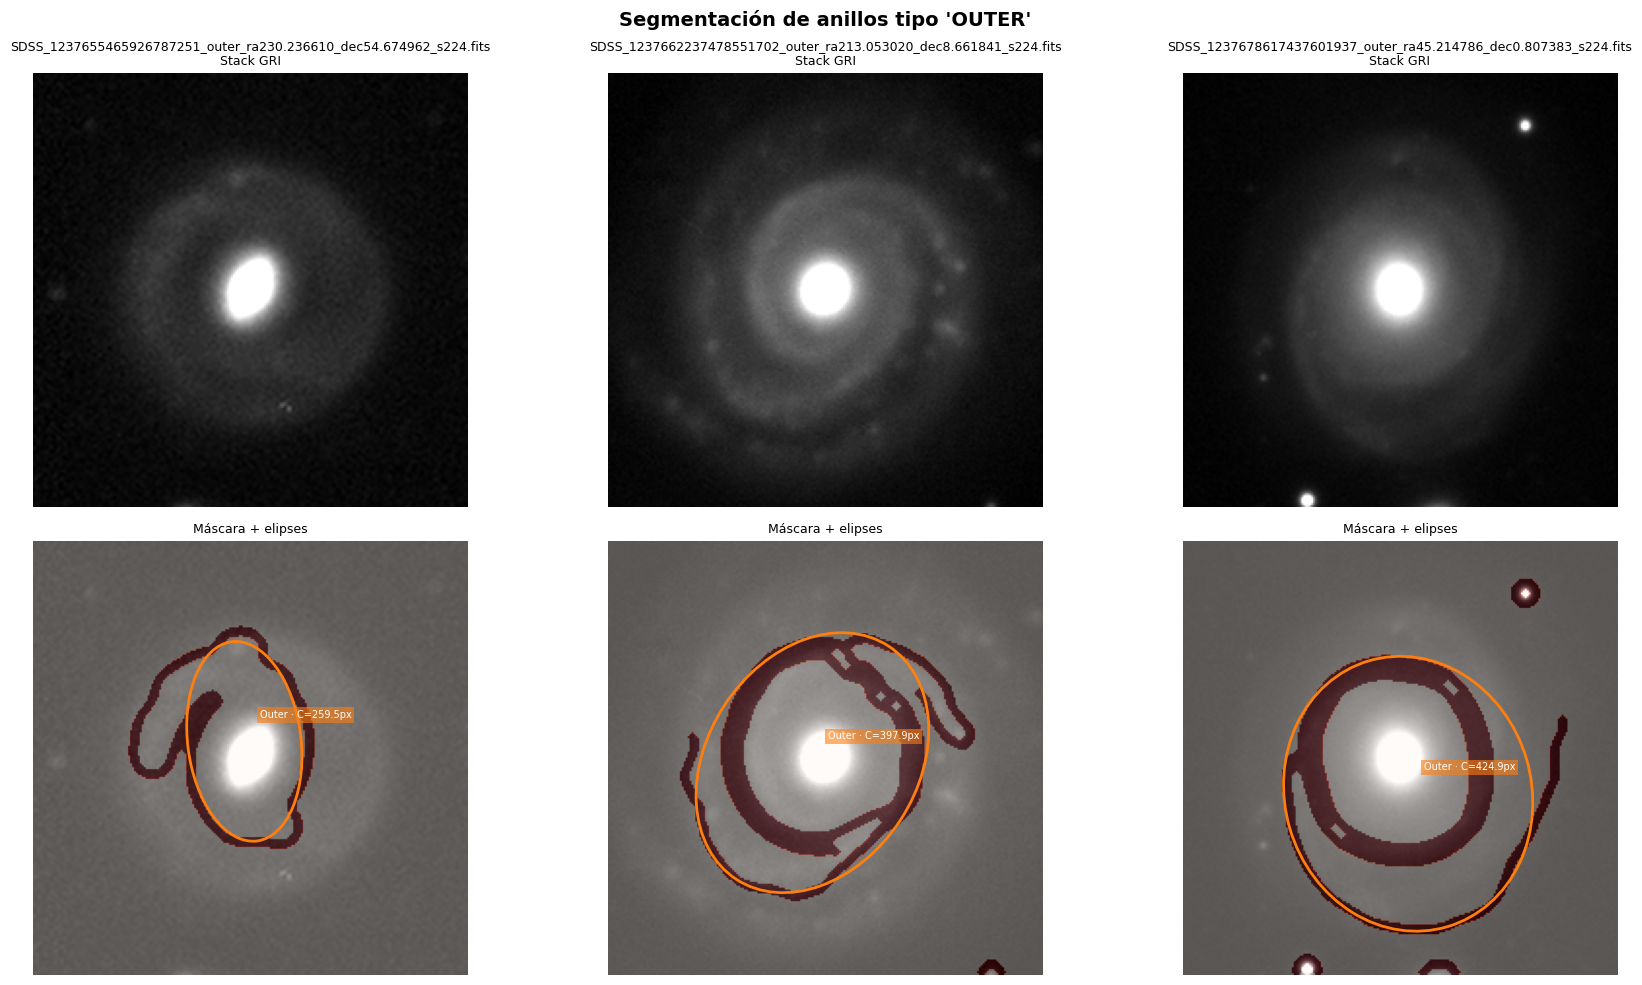

In [ ]:
# Visualización para cada clase de anillo
for cls_name, cls_files in zip(RING_TYPE, same_samples):
    if cls_name == "none":
        continue
    
    print(f"\n{'='*80}")
    print(f"Clase: {cls_name.upper()}")
    print('='*80)
    
    # Crear figura con 3 columnas (una por muestra) y 2 filas (original + segmentación)
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    for idx, cls_file in enumerate(cls_files):
        sample = Path(cls_file)
        
        # Procesar la imagen
        img, mask, measurements = segment_and_measure_ring(sample, ring_type=cls_name)
        
        # Fila superior: Imagen apilada GRI
        axs[0, idx].imshow(img, cmap="gray")
        axs[0, idx].set_title(f"{sample.name}\nStack GRI", fontsize=9)
        axs[0, idx].axis("off")
        
        # Fila inferior: Máscara + elipses
        axs[1, idx].imshow(img, cmap="gray")
        axs[1, idx].imshow(mask, cmap="Reds", alpha=0.35)
        axs[1, idx].set_title("Máscara + elipses", fontsize=9)
        axs[1, idx].axis("off")
        
        # Dibujar elipses detectadas
        for meas_idx, meas in enumerate(measurements):
            color = _RING_COLORS.get(meas.ring_label, _RING_COLORS.get(cls_name, "#2ca02c"))
            ellipse_patch = MplEllipse(
                xy=meas.center_xy,
                width=2 * meas.a_pix,
                height=2 * meas.b_pix,
                angle=meas.pa_deg,
                fill=False,
                edgecolor=color,
                linewidth=2,
            )
            axs[1, idx].add_patch(ellipse_patch)
            axs[1, idx].text(
                meas.center_xy[0] + 8,
                meas.center_xy[1] - 12 * (meas_idx + 1),
                f"{meas.ring_label.capitalize()} · C={meas.circumference_pix:.1f}px",
                color="white",
                fontsize=7,
                bbox=dict(facecolor=color, alpha=0.6, edgecolor="none", pad=2),
            )
        
        # Imprimir mediciones
        print(f"\nMuestra {idx + 1}: {sample.name}")
        if not measurements:
            print("  ⚠ No se encontró anillo.")
        else:
            for meas in measurements:
                circ_as = "N/A" if not math.isfinite(meas.circumference_as) else f"{meas.circumference_as:.2f}\""
                print(
                    f"  • {meas.ring_label.capitalize()} → "
                    f"a={meas.a_pix:.1f}px ({meas.a_as:.2f}\"), "
                    f"b={meas.b_pix:.1f}px ({meas.b_as:.2f}\"), "
                    f"C={meas.circumference_pix:.1f}px ({circ_as}), "
                    f"PA={meas.pa_deg:.1f}°"
                )
    
    plt.suptitle(f"Segmentación de anillos tipo '{cls_name.upper()}'", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


## Conclusiones

Este trabajo desarrolló un pipeline completo para la identificación y caracterización automatizada de estructuras anulares en galaxias del Legacy Survey DR10, integrando clasificación mediante aprendizaje profundo y cuantificación geométrica de anillos.

En la etapa de clasificación, la comparación entre cuatro arquitecturas (YOLO11-cls Small, EfficientNetB6, ViT Base y DINOv2 ViT Base) reveló que los modelos basados en atención superan consistentemente a las arquitecturas convolucionales. DINOv2 ViT Base alcanzó el mejor desempeño con F1-scores superiores a 0.95 en la clase 'ring' para rgi_stack, aunque con mayor latencia. La estrategia de gradual unfreeze demostró ser efectiva para estabilizar el aprendizaje con datasets limitados.

El análisis de estrategias de preprocesamiento mostró que las transformaciones simples (rgi_stack) y aquellas que realzan bordes (rgi_unsharp_mask, rgi_canny_stack) facilitan la detección sin introducir artefactos. El dataset rgi_unsharp_mask proporcionó un balance óptimo entre recall y precision, siendo especialmente útil cuando se prioriza maximizar la detección de anillos. Las visualizaciones de mapas de atención confirmaron que los modelos aprenden a enfocarse en regiones morfológicamente relevantes.

Para segmentación y medición geométrica, el pipeline combina preprocesamiento diferenciado por tipo de anillo con ajuste robusto mediante RANSAC, cuantificando semiejes, circunferencia, ángulo de posición y ancho radial. La detección jerárquica para galaxias con anillos duales (inner+outer) permite separar componentes que previamente requerían inspección manual. El uso exclusivo de RANSAC simplificó la segmentacion, manteniendo robustez ante outliers.

Desde una perspectiva de aplicabilidad práctica, el sistema ofrece flexibilidad: EfficientNetB6 proporciona balance entre desempeño (F1 ≈ 0.93) y eficiencia para análisis exploratorios, mientras DINOv2 ViT Base justifica su costo computacional para estudios que demandan máxima precisión. La implementación completa tiene el potencial de habilitar estudios a gran escala que antes dependían de catalogación manual.

Las limitaciones incluyen el desbalance en validación (1000 vs 288 imágenes) que podría afectar la generalización, y la optimización del sistema de medición para anillos bien definidos, resultando en mediciones nulas para estructuras extremadamente difusas. Trabajos futuros podrían explorar técnicas avanzadas de aumento de datos y la integración explícita de información multi-banda.